# **Library Import**
---
---

In [1]:
# Data processing libraries
import pandas as pd
import numpy as np
import random
from sklearn.preprocessing import MinMaxScaler

# Statistical tests
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# For directory & environment variable handling
import os
from dotenv import load_dotenv

from functions.database_actions_functions import serve_whole_data

# For installing model/scalers
import joblib

# LSTM modelling
import tensorflow as tf
import torch
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error
from torchmetrics import SymmetricMeanAbsolutePercentageError

# TFT modelling
import lightning as lt
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

from pytorch_forecasting.metrics.quantile import QuantileLoss
from pytorch_forecasting.metrics.point import MAE, RMSE, SMAPE

In [2]:
def set_global_determinism(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # 2. Force deterministic algorithms
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True) # Force PyTorch
    
    try:
        tf.config.experimental.enable_op_determinism()
    except AttributeError:
        pass

SEED = 42

set_global_determinism(seed=SEED)

# **Loading Dataset**
---
---

In [3]:
load_dotenv()

list_tables = ['station_details', 'station_sensors', 'weather_readings']
username_postgres = os.getenv('USER_POSTGRES')
pw_postgres = os.getenv('PW_POSTGRES')
db_name = 'data_warehouse_weather'

df = serve_whole_data(username_postgres, pw_postgres, db_name, limit=10000)
df

Existence of DB data_warehouse_weather: True



c:\Users\user\works\DE_studies\pm25_forecast\functions\database_actions_functions.py:164: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  table_result = pd.io.sql.read_sql_query(f'''


Saved cleaned, read-ML data to c:\Users\user\works\DE_studies\pm25_forecast\datasets_aggr\weather_readings_mlready.csv


,weather_id,sensor_id,station_id,station_name,time_reading,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,rain,pm25,longitude,latitude
0,W1561901_2023010100,1561901,270693,Waterloo Place,2023-01-01 00:00:00,12.1,89.0,34.1,999.1,0.3,5.1,-0.133068,51.507582
1,W1561901_2023010101,1561901,270693,Waterloo Place,2023-01-01 01:00:00,11.3,94.0,22.9,999.1,0.1,6.2,-0.133068,51.507582
2,W1561901_2023010102,1561901,270693,Waterloo Place,2023-01-01 02:00:00,11.9,85.0,31.1,999.9,0.4,6.6,-0.133068,51.507582
3,W1561901_2023010103,1561901,270693,Waterloo Place,2023-01-01 03:00:00,11.0,80.0,31.4,1000.9,0.0,7.9,-0.133068,51.507582
4,W1561901_2023010104,1561901,270693,Waterloo Place,2023-01-01 04:00:00,10.4,78.0,30.7,1001.9,0.0,8.3,-0.133068,51.507582
...,...,...,...,...,...,...,...,...,...,...,...,...,...
224276,W1561901_2026082911,1561901,270693,Waterloo Place,2026-08-29 11:00:00,17.3,93.0,10.7,1002.0,1.5,1.2,-0.133068,51.507582
224277,W2009625_2026082911,2009625,290183,Tower Hamlets,2026-08-29 11:00:00,17.3,93.0,10.7,1002.0,1.5,NaN,-0.018022,51.502988
224278,W1304734_2026082910,1304734,225803,London Honor Oak Park,2026-08-29 10:00:00,17.3,88.0,12.1,1002.5,1.3,1.3,-0.037415,51.449673
224279,W1304734_2026082920,1304734,225803,London Honor Oak Park,2026-08-29 20:00:00,18.8,85.0,16.8,997.7,0.6,NaN,-0.037415,51.449673


In [4]:
import datetime
#14
df = df[df['time_reading'] <= datetime.datetime.strptime('2026-07-26 21:00:00', '%Y-%m-%d %H:00:00')] # Getting batched data that is used for the machine learning model
df

,weather_id,sensor_id,station_id,station_name,time_reading,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,rain,pm25,longitude,latitude
0,W1561901_2023010100,1561901,270693,Waterloo Place,2023-01-01 00:00:00,12.1,89.0,34.1,999.1,0.3,5.1,-0.133068,51.507582
1,W1561901_2023010101,1561901,270693,Waterloo Place,2023-01-01 01:00:00,11.3,94.0,22.9,999.1,0.1,6.2,-0.133068,51.507582
2,W1561901_2023010102,1561901,270693,Waterloo Place,2023-01-01 02:00:00,11.9,85.0,31.1,999.9,0.4,6.6,-0.133068,51.507582
3,W1561901_2023010103,1561901,270693,Waterloo Place,2023-01-01 03:00:00,11.0,80.0,31.4,1000.9,0.0,7.9,-0.133068,51.507582
4,W1561901_2023010104,1561901,270693,Waterloo Place,2023-01-01 04:00:00,10.4,78.0,30.7,1001.9,0.0,8.3,-0.133068,51.507582
...,...,...,...,...,...,...,...,...,...,...,...,...,...
219309,W6955371_2026072617,6955371,225719,Brent,2026-07-26 17:00:00,24.9,36.0,20.8,1000.8,0.0,7.0,-0.247793,51.537799
219310,W6955371_2026072618,6955371,225719,Brent,2026-07-26 18:00:00,23.6,40.0,22.3,1001.7,0.0,6.0,-0.247793,51.537799
219311,W6955371_2026072619,6955371,225719,Brent,2026-07-26 19:00:00,22.8,42.0,20.6,1002.3,0.0,8.0,-0.247793,51.537799
219312,W6955371_2026072620,6955371,225719,Brent,2026-07-26 20:00:00,21.8,45.0,18.2,1003.0,0.0,6.0,-0.247793,51.537799


# **Exploratory Data Analysis**
---
---

## **1. Data Characteristics**
---

In [5]:
# Data type information
df.info()

<class 'pandas.DataFrame'>
Index: 218889 entries, 0 to 219313
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   weather_id            218889 non-null  str           
 1   sensor_id             218889 non-null  int64         
 2   station_id            218889 non-null  int64         
 3   station_name          218889 non-null  str           
 4   time_reading          218889 non-null  datetime64[us]
 5   temperature_2m        218889 non-null  float64       
 6   relative_humidity_2m  218889 non-null  float64       
 7   wind_speed_10m        218889 non-null  float64       
 8   surface_pressure      218889 non-null  float64       
 9   rain                  218889 non-null  float64       
 10  pm25                  160224 non-null  float64       
 11  longitude             218889 non-null  float64       
 12  latitude              218889 non-null  float64       
dtypes: datetime64[u

In [6]:
# Statistical Characteristics
df.describe(include='all')

,weather_id,sensor_id,station_id,station_name,time_reading,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,rain,pm25,longitude,latitude
count,218889,2.188890e+05,218889.000000,218889,218889,218889.000000,218889.000000,218889.000000,218889.000000,218889.000000,160224.000000,218889.000000,218889.000000
unique,218889,NaN,NaN,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,W1561901_2023010100,NaN,NaN,Waterloo Place,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,31270,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,1.880743e+06,176922.634216,NaN,2024-10-13 10:34:17.135808,11.999726,77.039627,13.397108,1010.707509,0.084698,8.885246,-0.092626,51.503411
min,NaN,2.350000e+02,152.000000,NaN,2023-01-01 00:00:00,-5.300000,9.000000,0.000000,946.900000,0.000000,-13.600000,-0.247793,51.449673
25%,NaN,2.889000e+04,159.000000,NaN,2023-11-22 17:00:00,7.500000,68.000000,8.300000,1004.000000,0.000000,4.900000,-0.175269,51.486957
50%,NaN,1.304734e+06,225751.000000,NaN,2024-10-13 11:00:00,11.500000,81.000000,12.300000,1011.900000,0.000000,7.000000,-0.131931,51.502988
75%,NaN,2.009625e+06,270693.000000,NaN,2025-09-04 04:00:00,16.200000,90.000000,17.400000,1018.600000,0.000000,10.800000,-0.018022,51.537799
max,NaN,6.955371e+06,290183.000000,NaN,2026-07-26 21:00:00,36.300000,100.000000,52.500000,1045.100000,15.500000,744.000000,0.095111,51.544210


In [7]:
# Missing values & Duplicates
print('Missing Values:')
display(df.isnull().sum())

print(f'\nDuplicated Values: {df.duplicated().sum()}')

Missing Values:


weather_id                  0
sensor_id                   0
station_id                  0
station_name                0
time_reading                0
temperature_2m              0
relative_humidity_2m        0
wind_speed_10m              0
surface_pressure            0
rain                        0
pm25                    58665
longitude                   0
latitude                    0
dtype: int64


Duplicated Values: 0


## **2. Data Distribution**
---

### 2.1. Categorical Data distribution
---

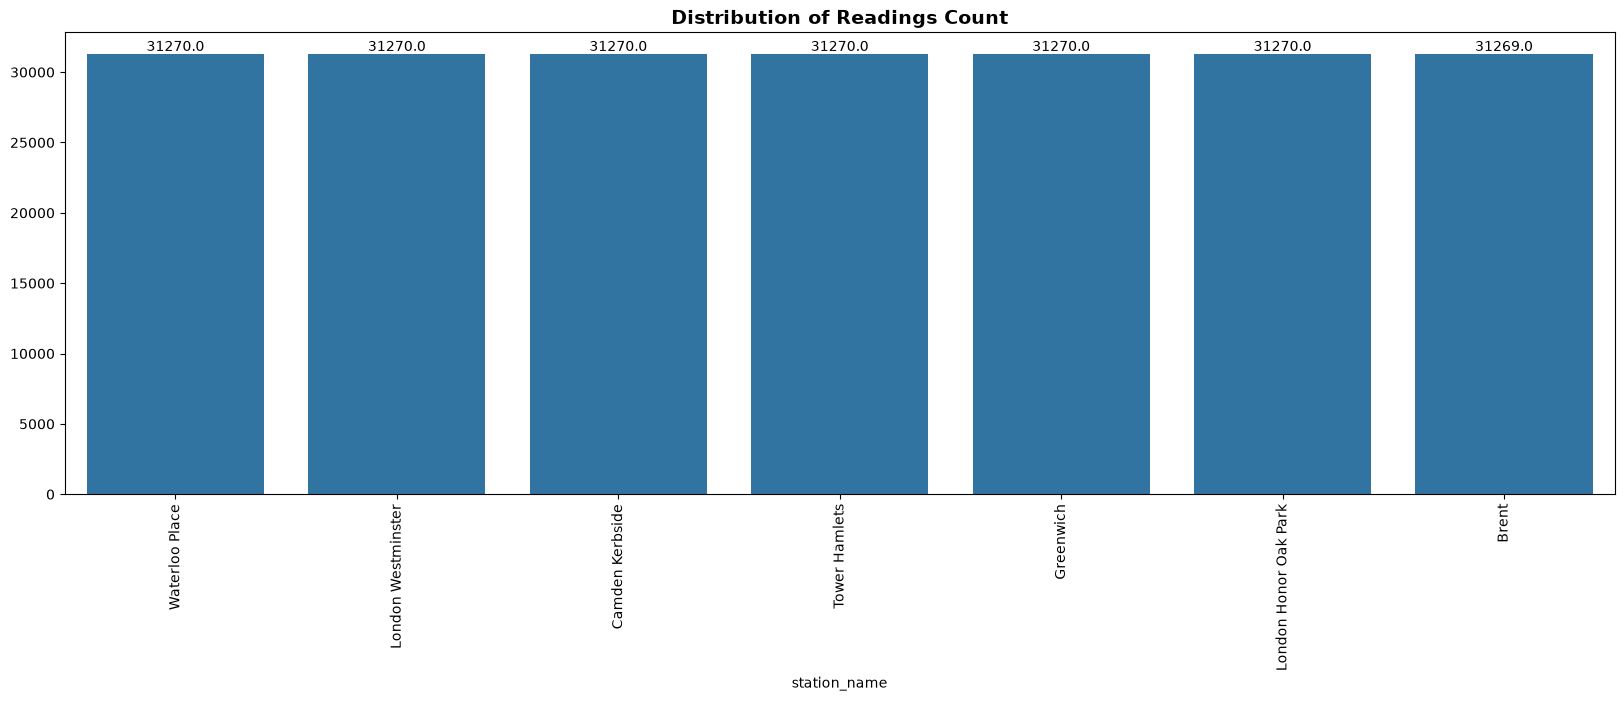

In [8]:
plt.figure(figsize=(20, 6))
count = df['station_name'].value_counts()
ax = sns.barplot(x=count.index, y=count.values)
for val in ax.containers:
    label = [v.get_height() for v in val]
    ax.bar_label(val, labels=label, label_type='edge')
plt.xticks(rotation=90)
plt.title('Distribution of Readings Count', fontsize=14, fontweight='bold')
plt.show()

### 2.2. Numerical Data distribution
---

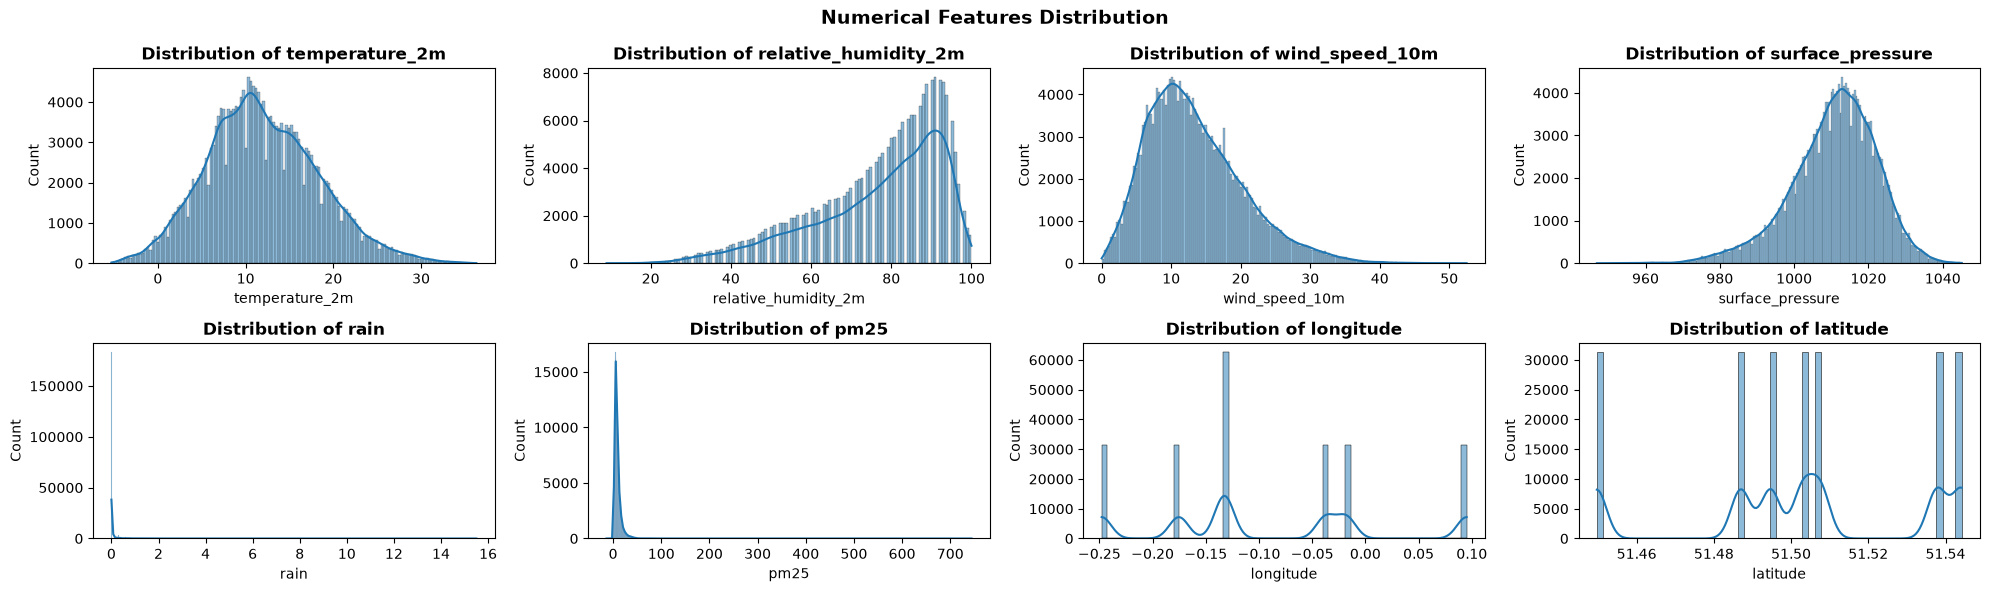

In [9]:
forbid = ['sensor_id', 'station_id']
cols = [col for col in df.select_dtypes(include='number').columns if col not in forbid]

plt.figure(figsize=(20, 6))
for i, col in enumerate(cols):
    plt.subplot(2, 4, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}', fontsize=12, fontweight='bold')
plt.suptitle('Numerical Features Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **3. Outlier Distribution**
---

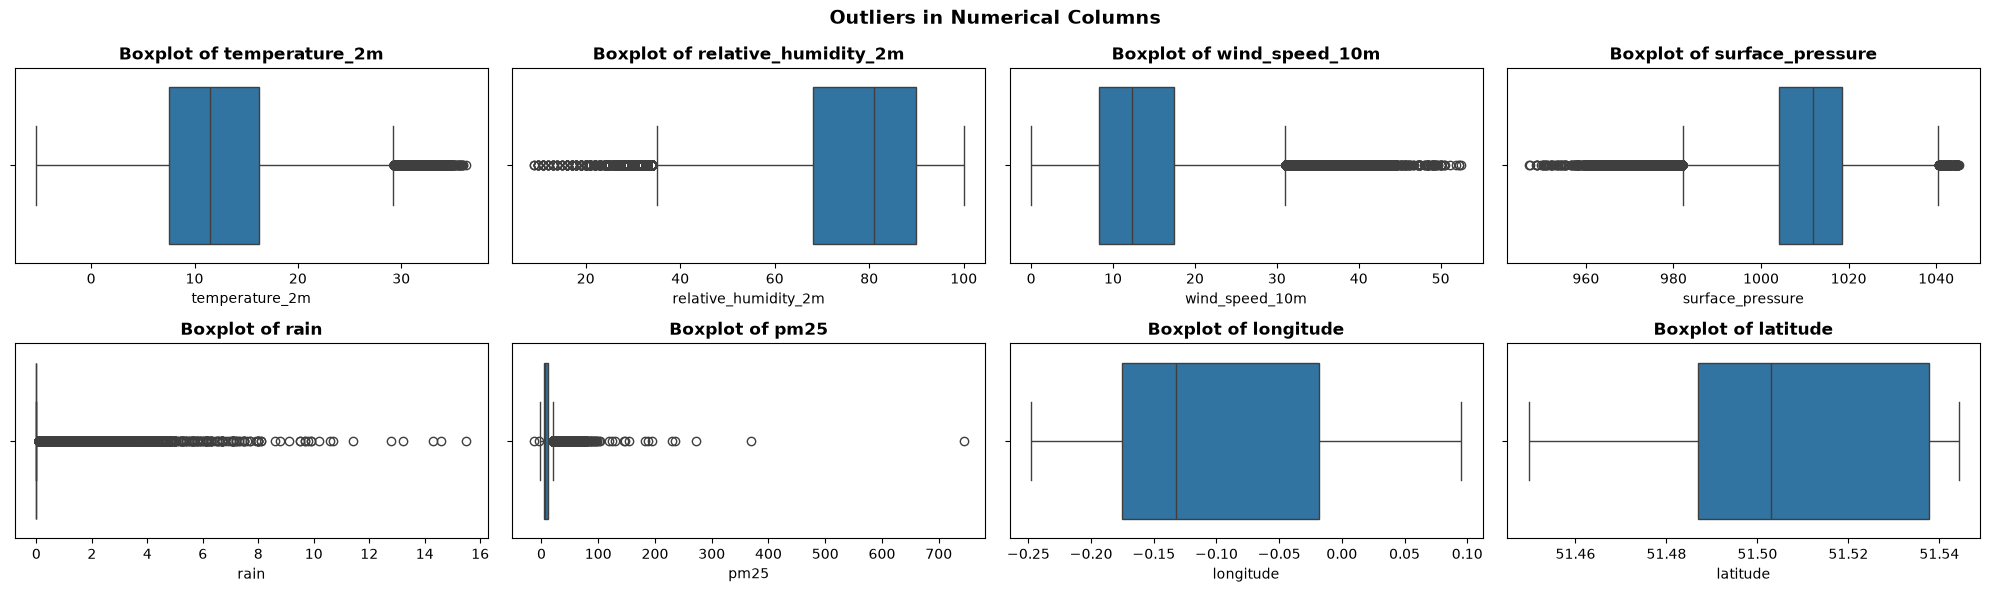

In [10]:
forbid = ['sensor_id', 'station_id']
cols = [col for col in df.select_dtypes(include='number').columns if col not in forbid]

plt.figure(figsize=(20, 6))
for i, col in enumerate(cols):
    plt.subplot(2, 4, i+1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
plt.suptitle('Outliers in Numerical Columns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **4. Correlation Analysis**
---

### 4.1. Regular Correlation
---

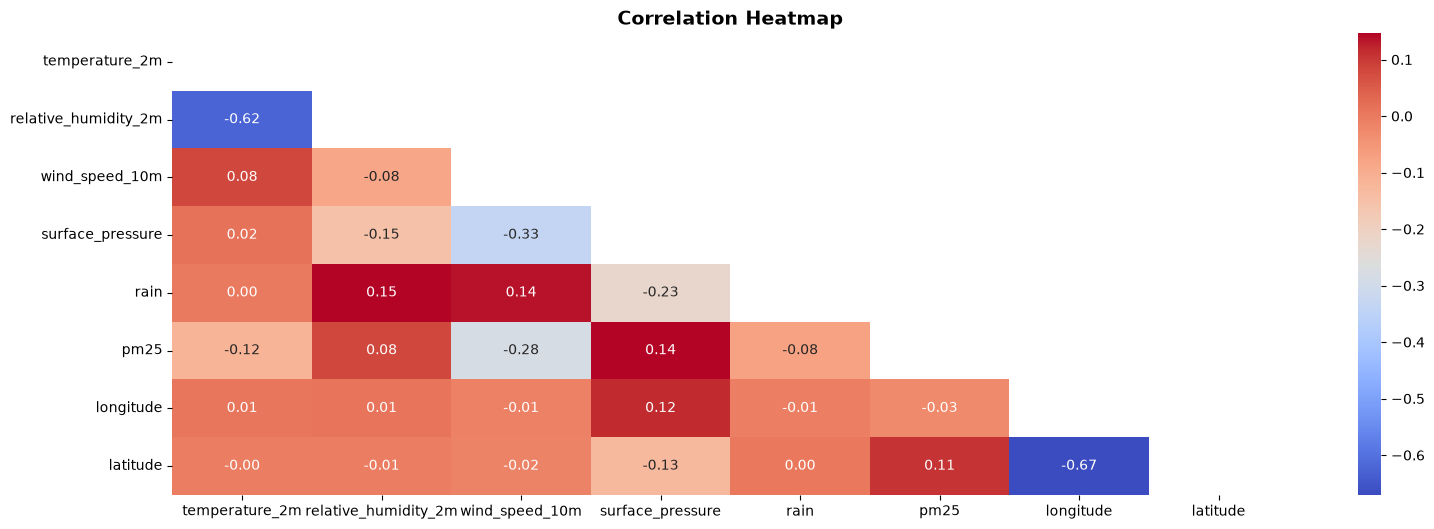

In [11]:
# Regular Correlation
forbid = ['sensor_id', 'station_id']
cols = [col for col in df.select_dtypes(include='number').columns if col not in forbid]
corr = df[cols].corr()

plt.figure(figsize=(18, 6))
mask = np.triu(np.ones_like(corr, dtype=float))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm')
plt.title(f'Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

### 4.2. Cross Correlation
---

In [12]:
# Cross Correlation
# Note: shift by 1 --> gets a record's previous value, shift by 2 --> gets a record's next value
df_try = df.copy()
range_lags = range(0, 20)
forbid = ['sensor_id', 'station_id', 'longitude', 'latitude']
cols = [col for col in df_try.select_dtypes(include='number').columns if col not in forbid]

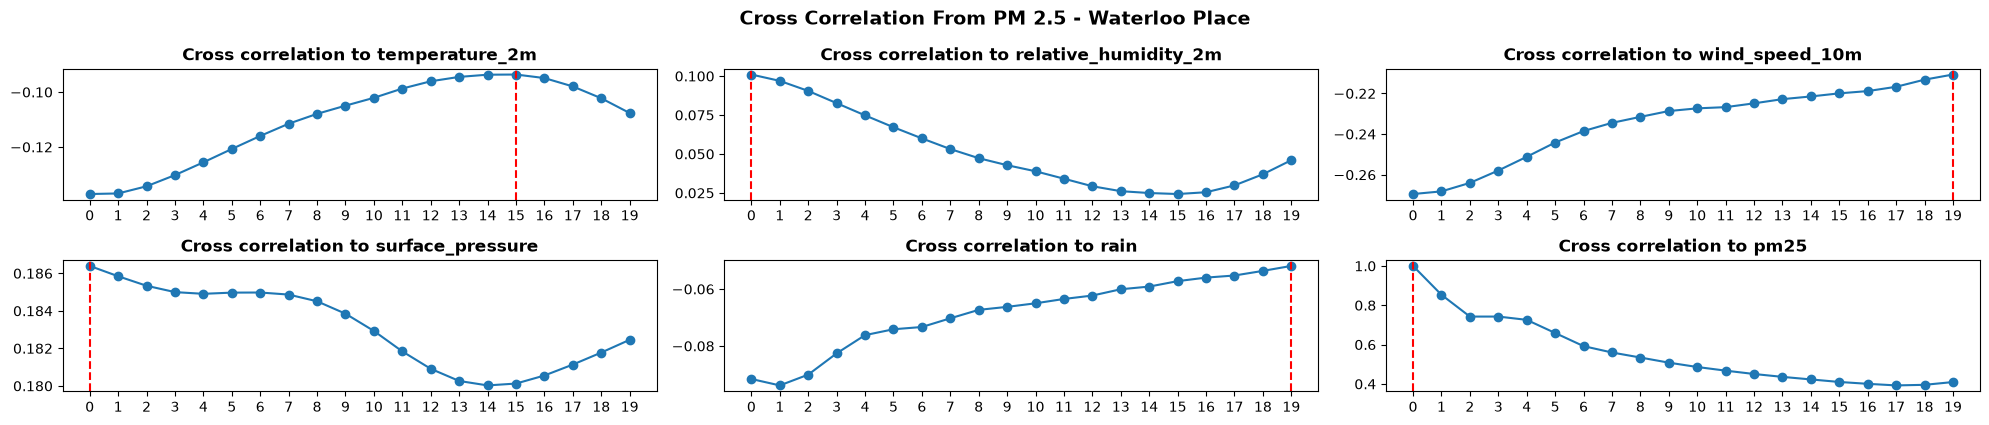

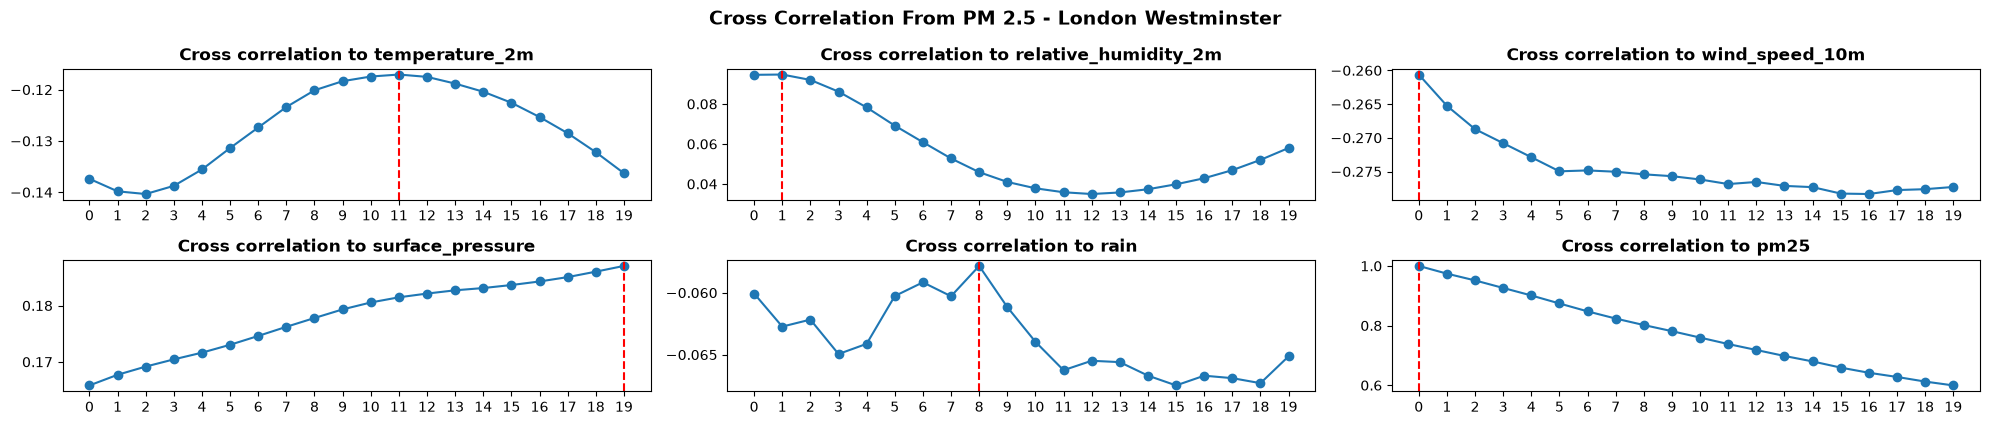

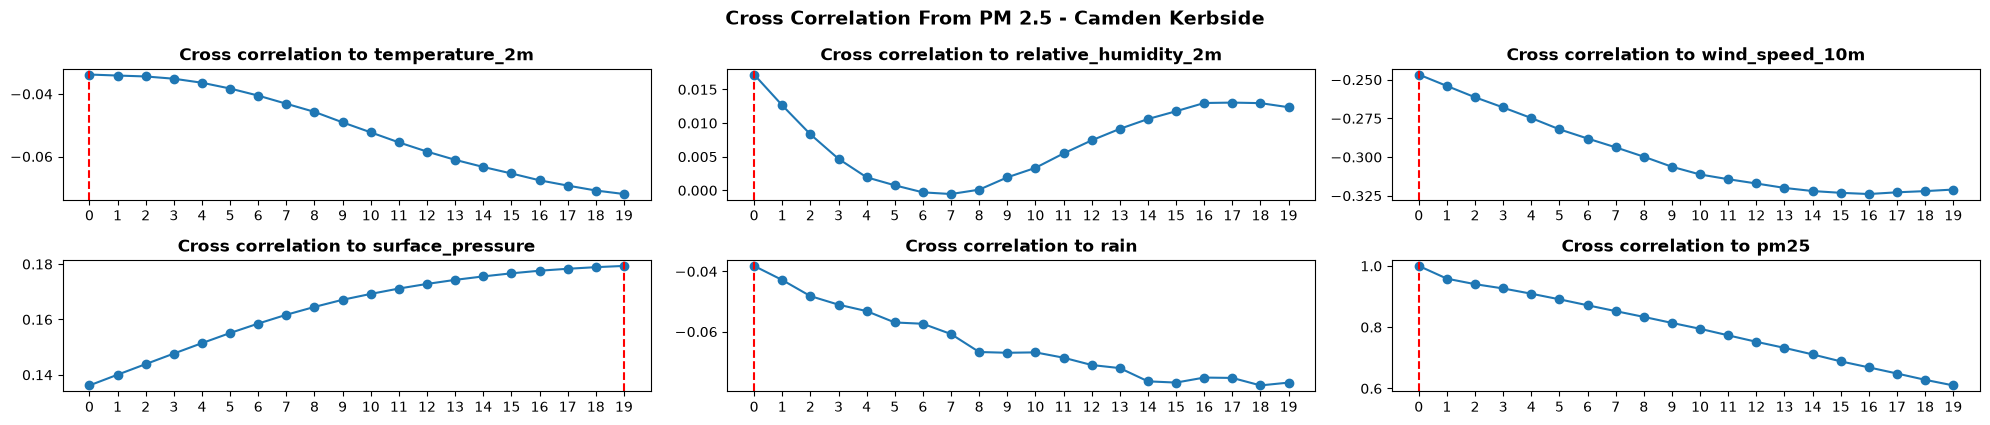

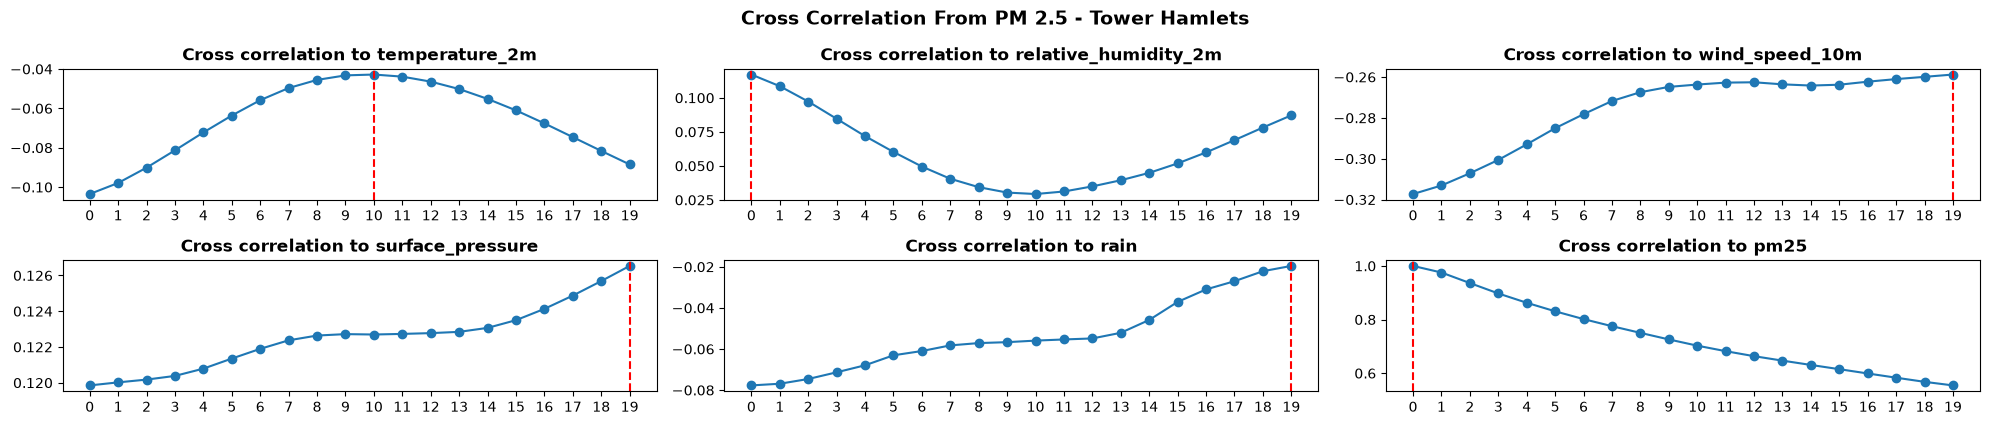

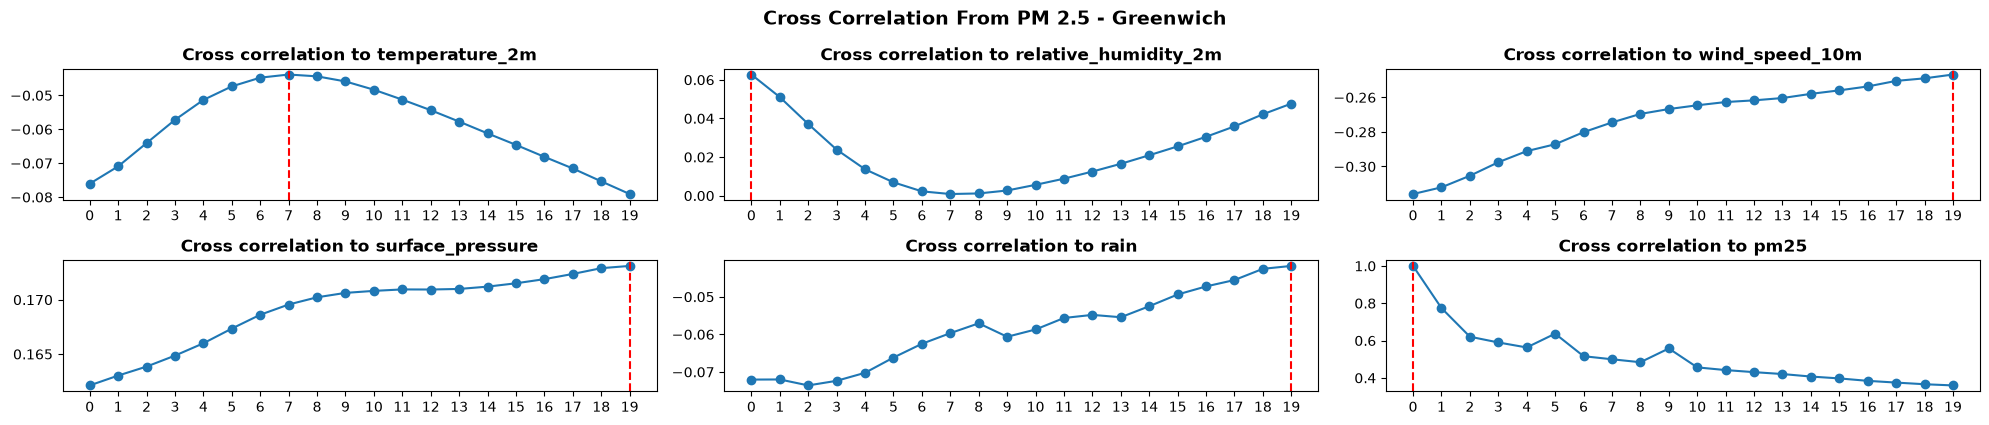

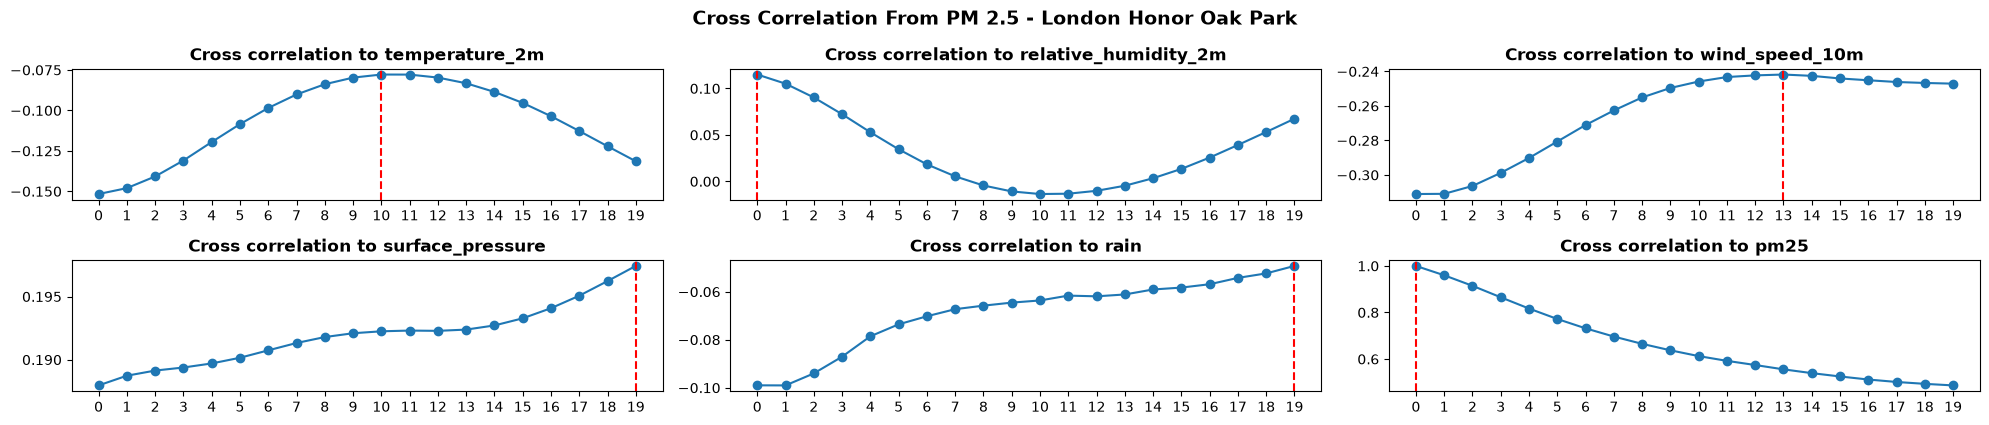

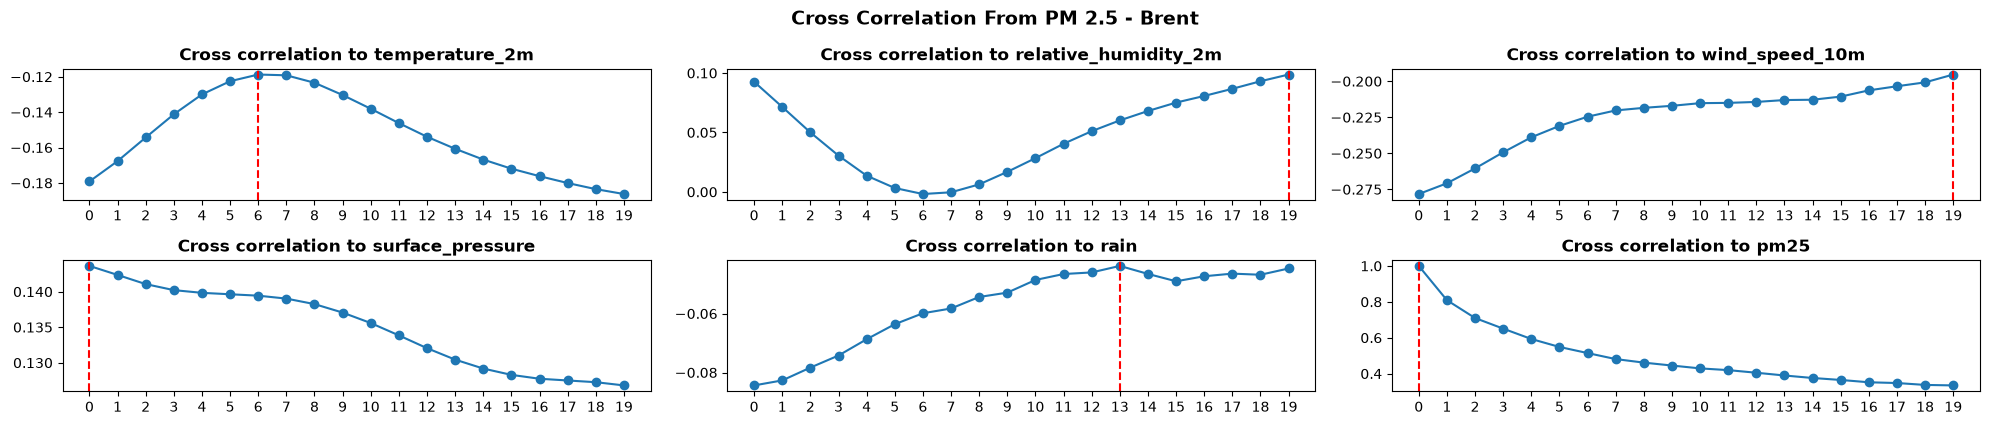

In [13]:
for station in df_try['station_name'].unique():
    current = df_try[df_try['station_name']==station].copy()

    correlations = {}
    max_corrs = {}
    for col in cols:
        correlations[col] = []
        for lag in range_lags: # loops through all lags
            corr_curr = current['pm25'].corr(current[col].shift(lag)) # gets the correlation between PM2.5 readings to the previous x hours
            correlations[col].append(corr_curr) # appends the correlation
        idx_max = correlations[col].index(max(correlations[col])) # extracts index/lag wwith highest correlation
        max_corrs[col] = range_lags[idx_max]

    plt.figure(figsize=(20, 6))
    for i, col in enumerate(cols):
        plt.subplot(3, 3, i+1)
        plt.plot(range_lags, correlations[col], marker='o', linestyle='-')
        plt.axvline(x=max_corrs[col], color='red', linestyle='--', label=f'Peak lag: {max_corrs[col]} hours')
        plt.title(f'Cross correlation to {col}', fontsize=12, fontweight='bold')
        plt.xticks(list(range_lags))
    plt.suptitle(f'Cross Correlation From PM 2.5 - {station}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(' ')

## **5. Weather and PM 2.5 Levels Overtime**
---

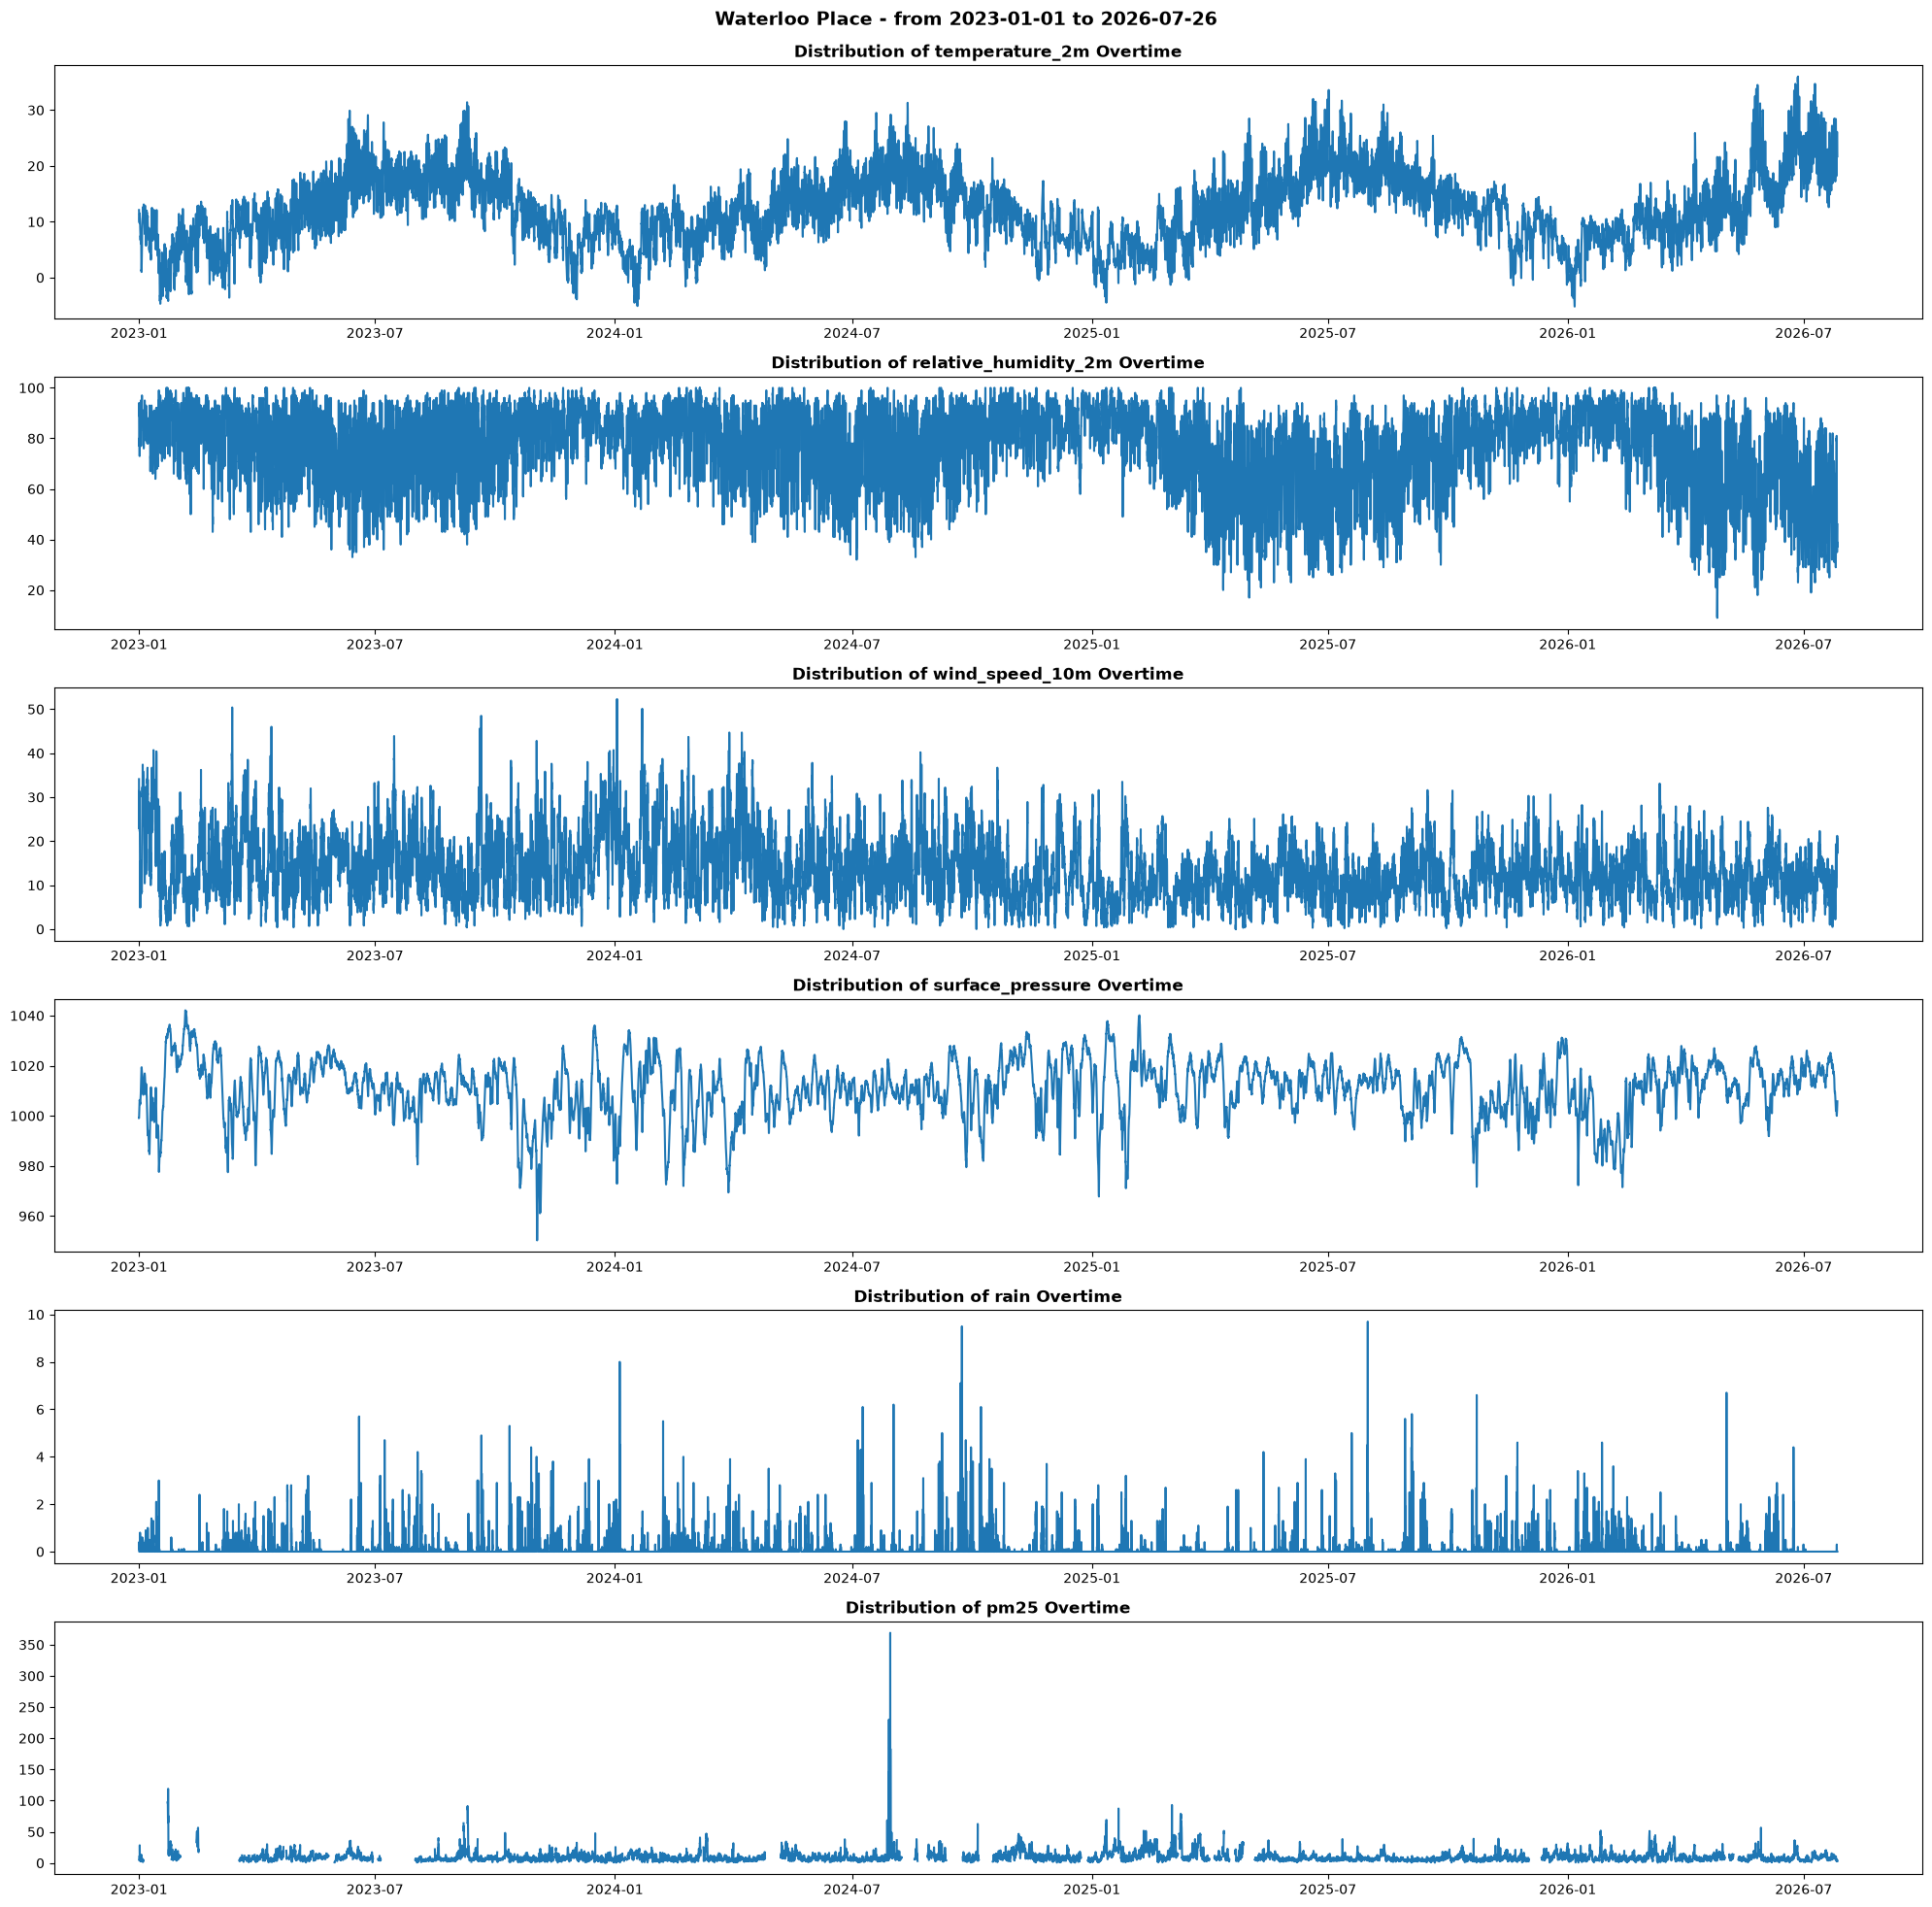

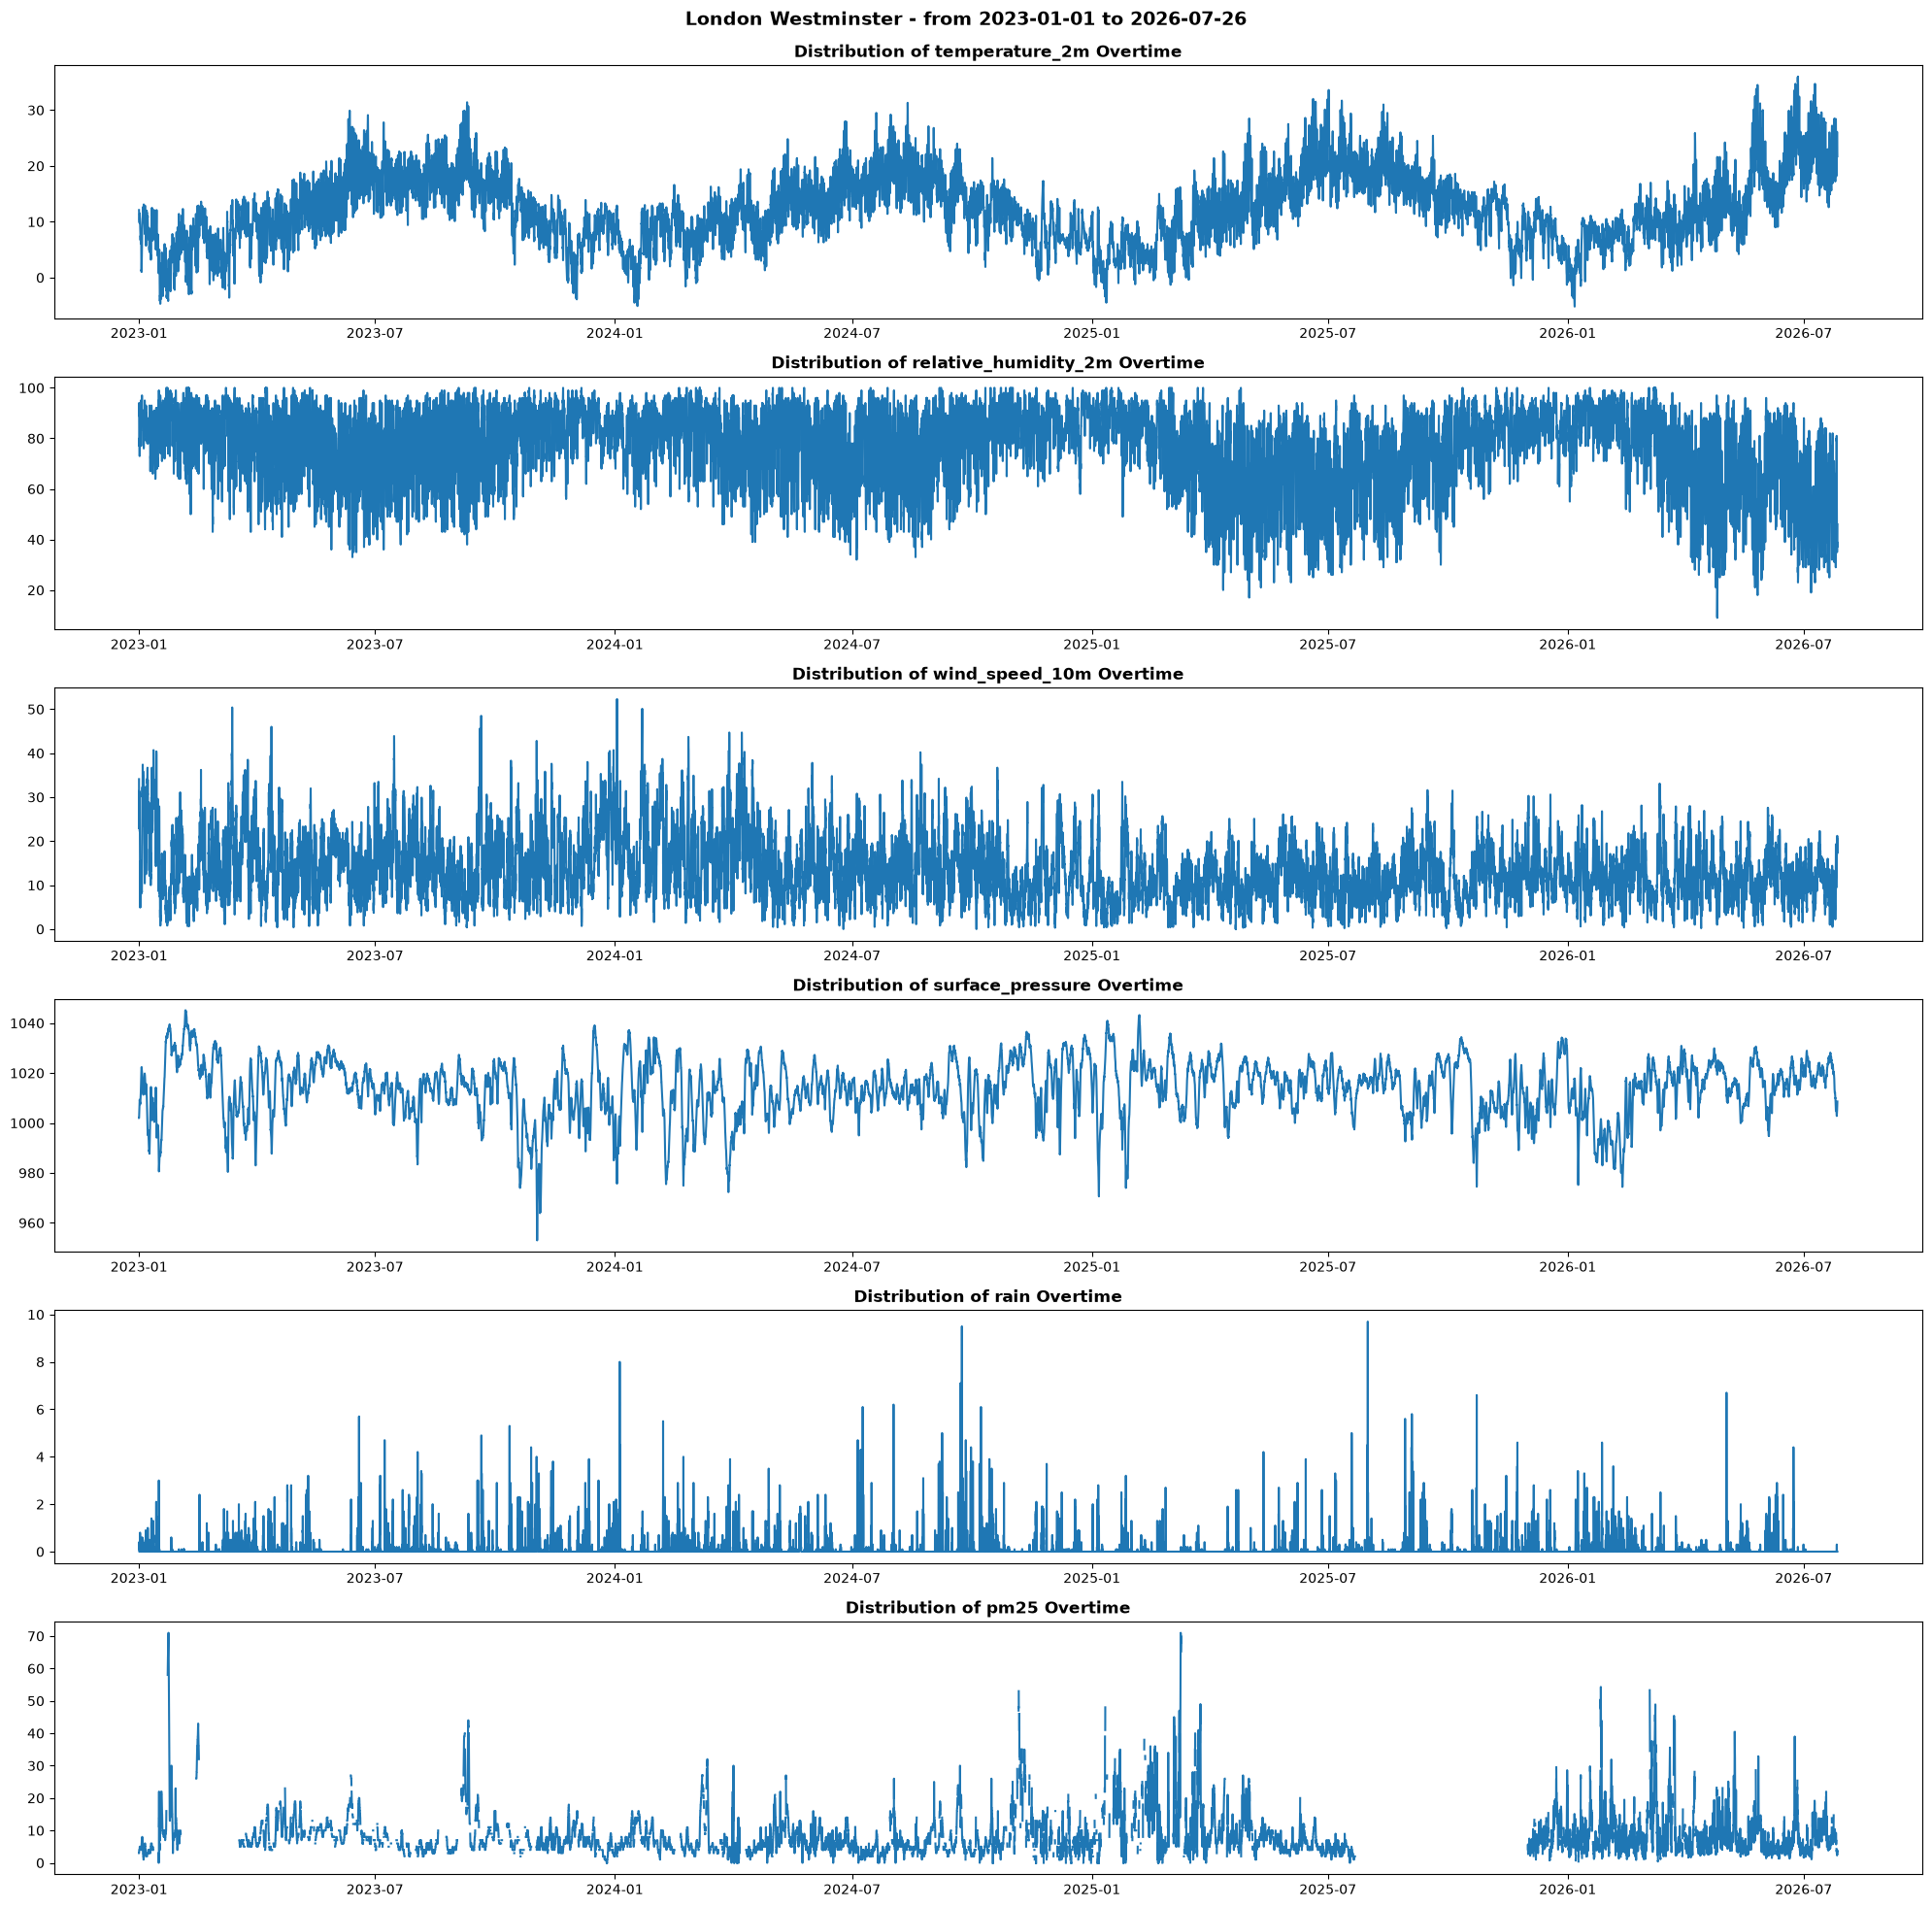

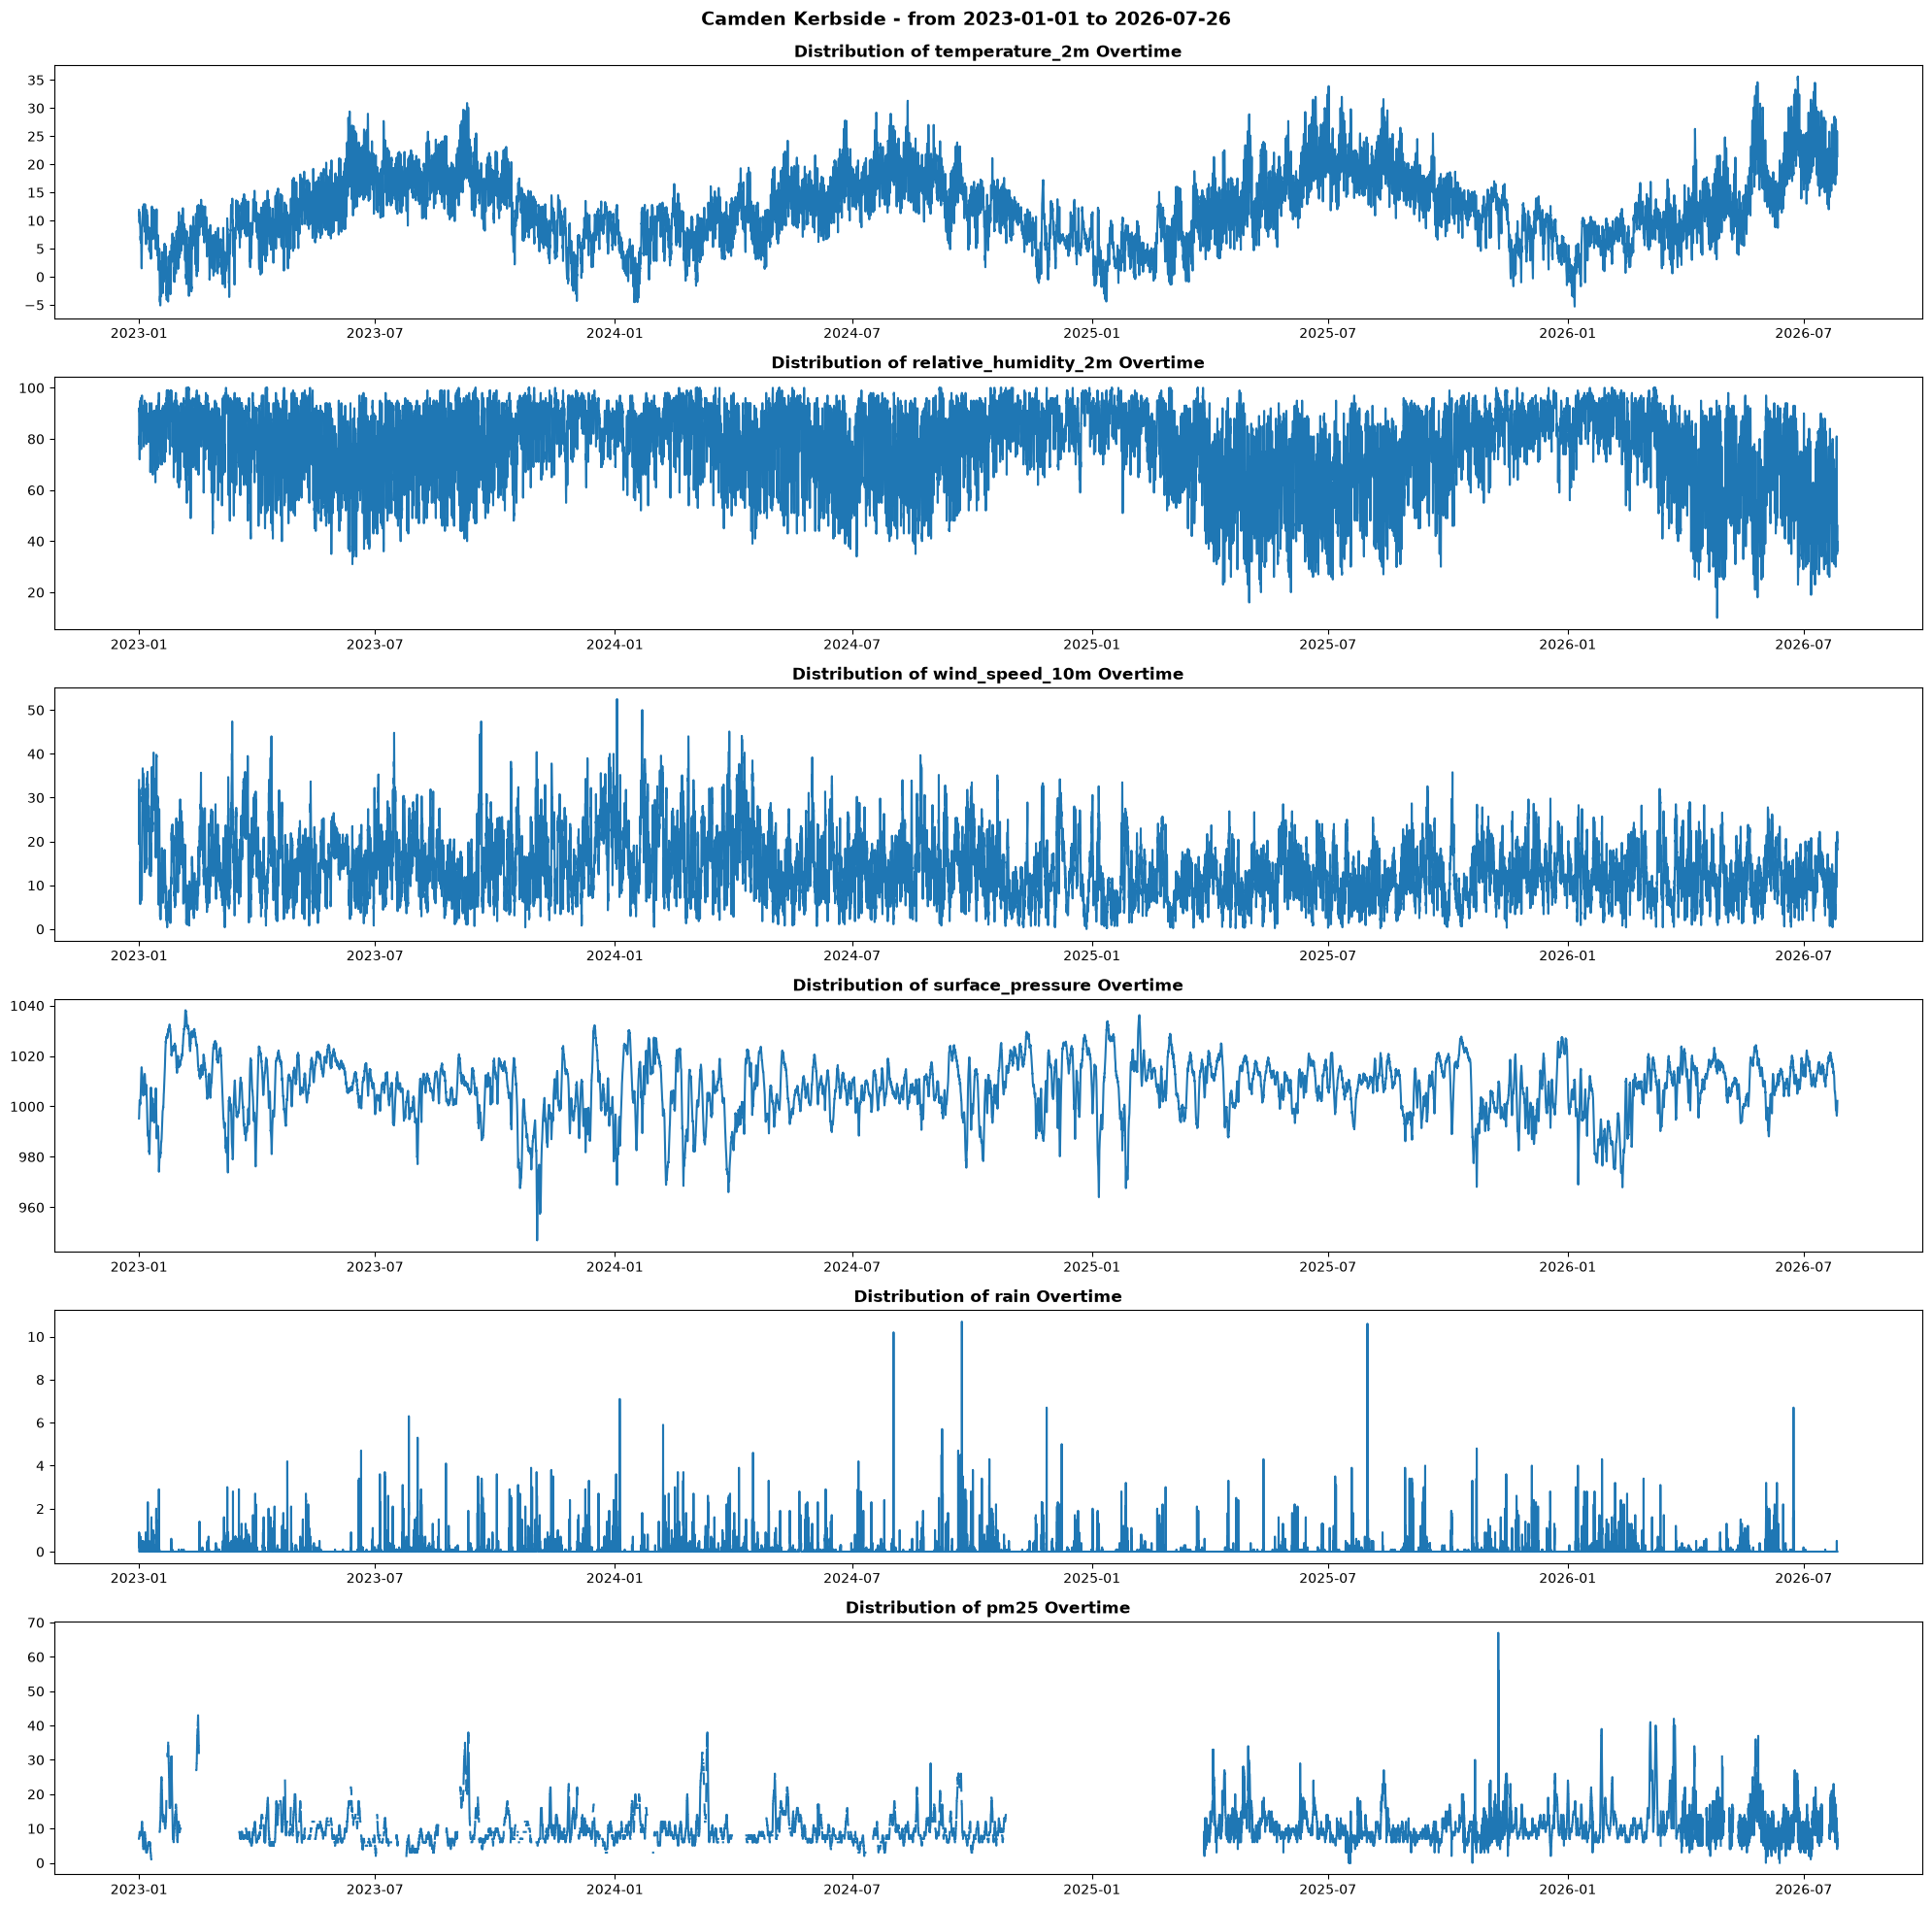

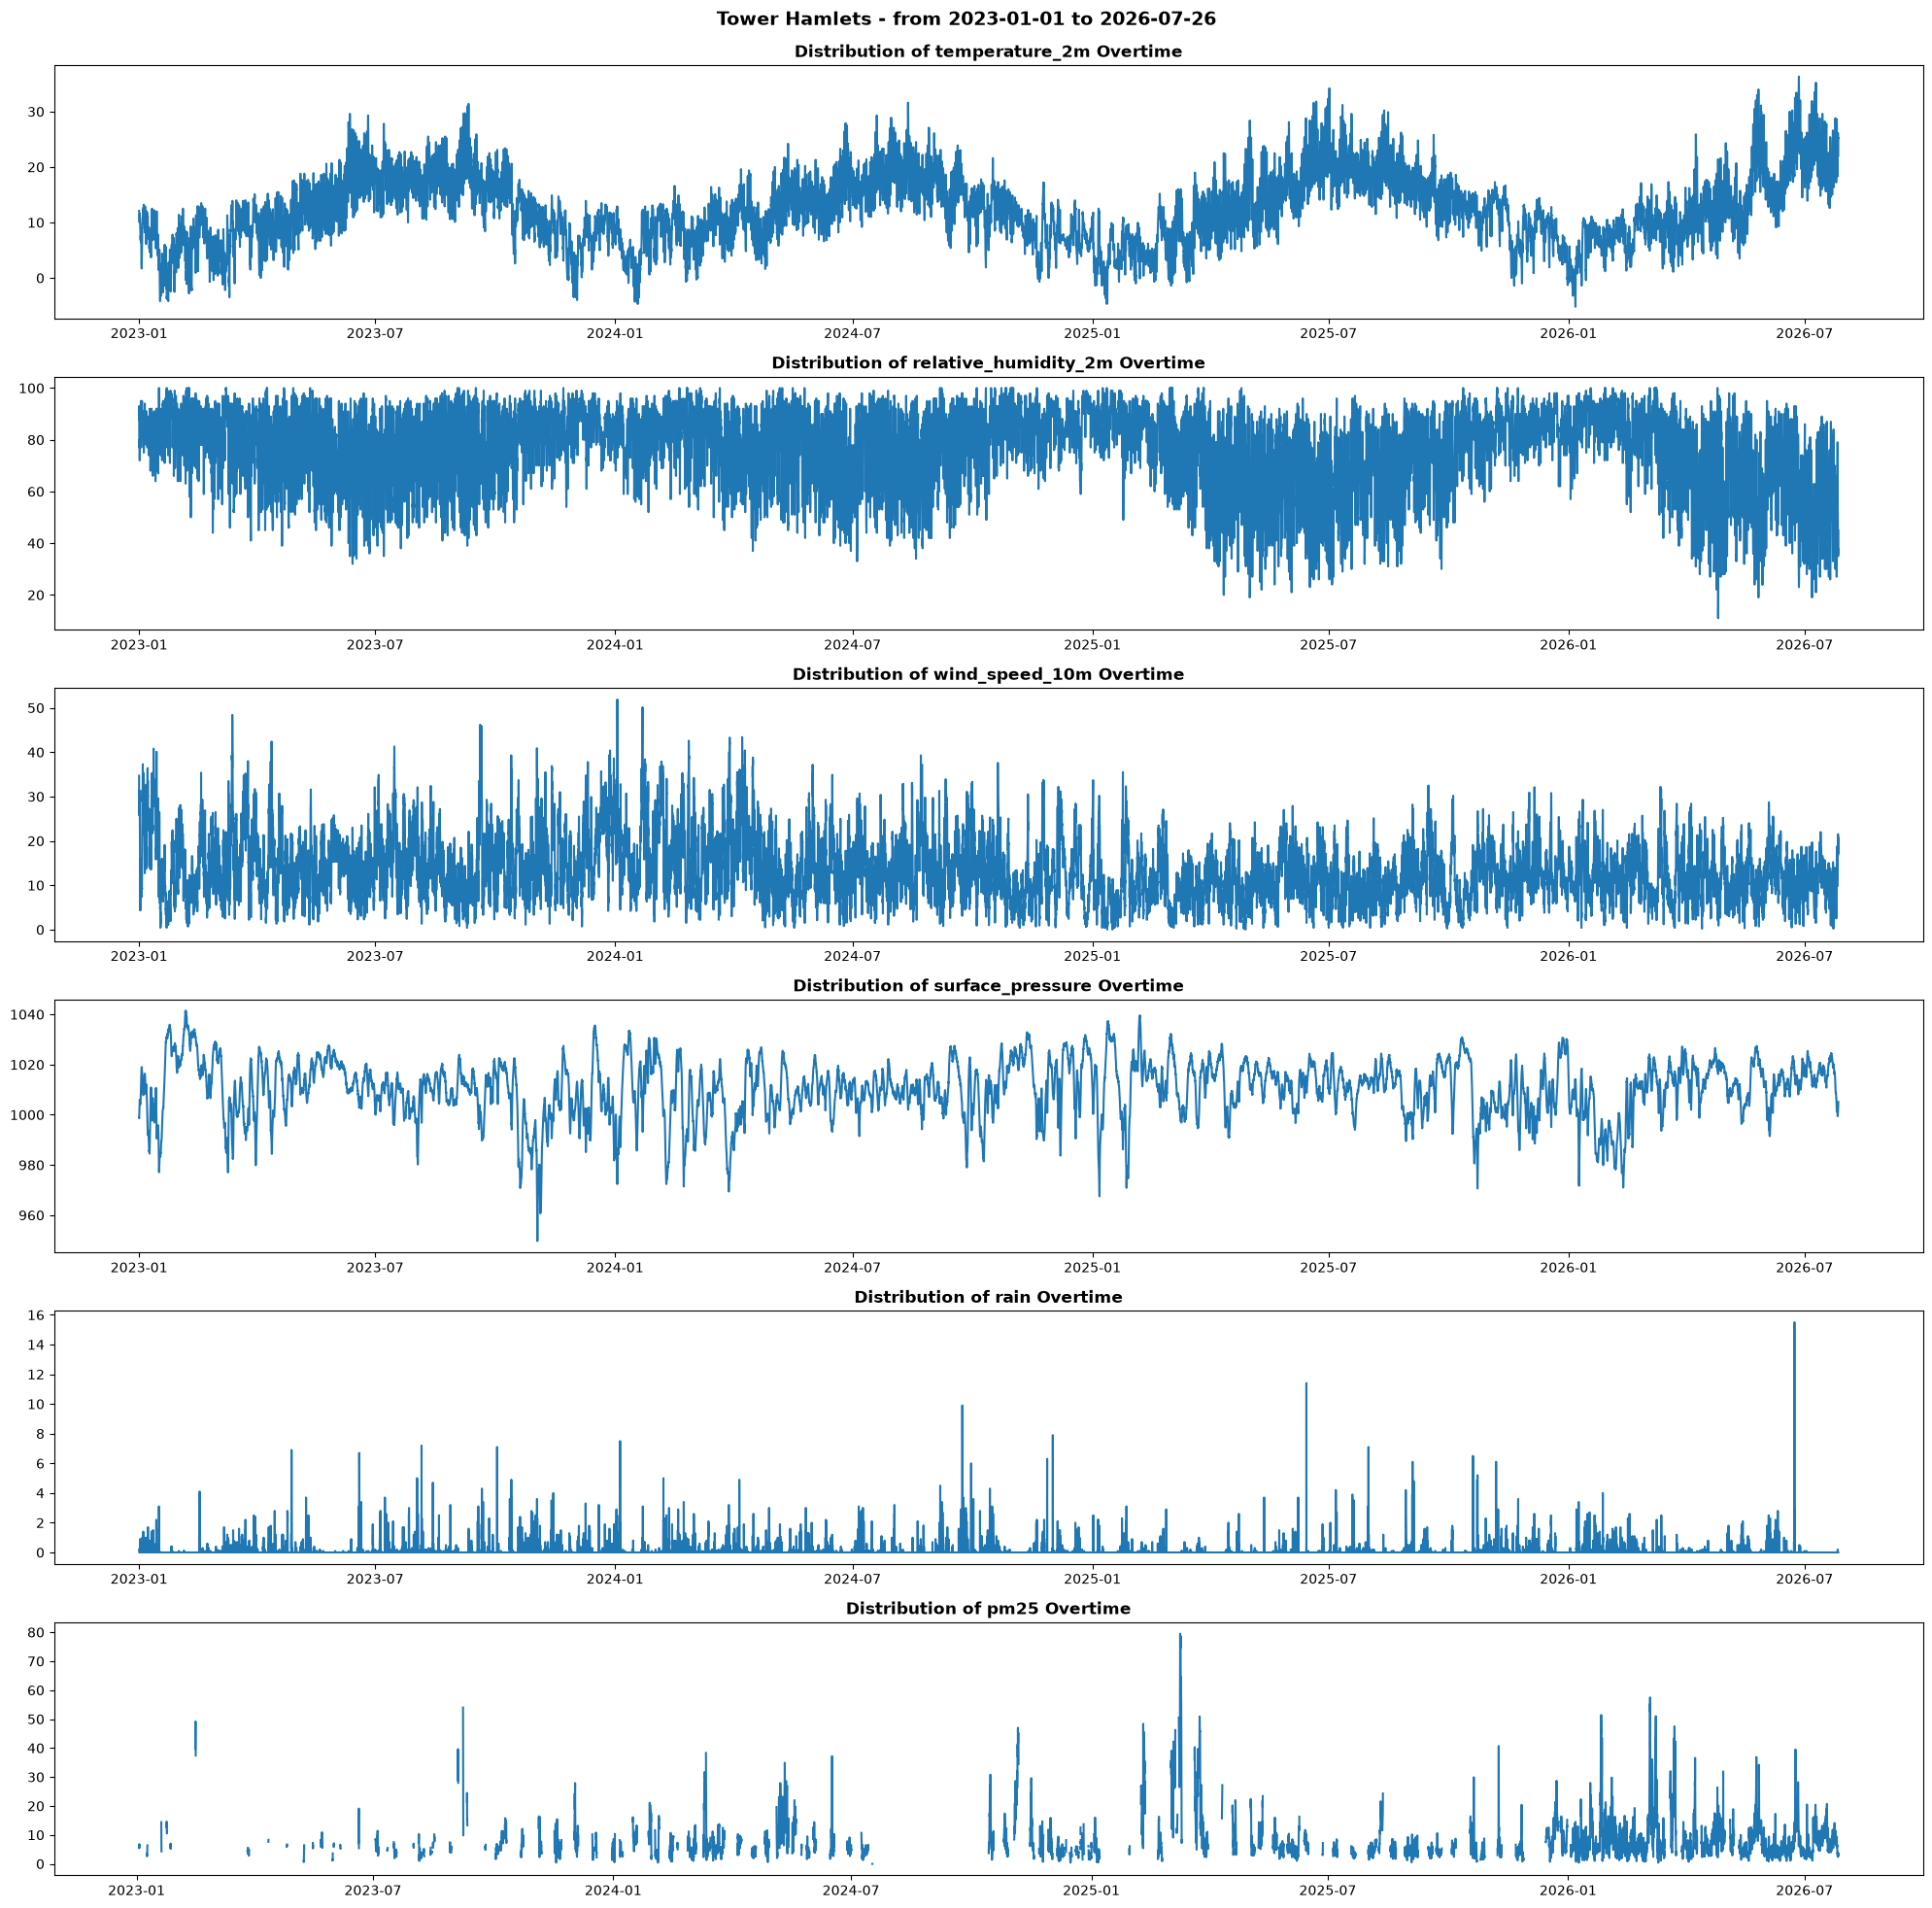

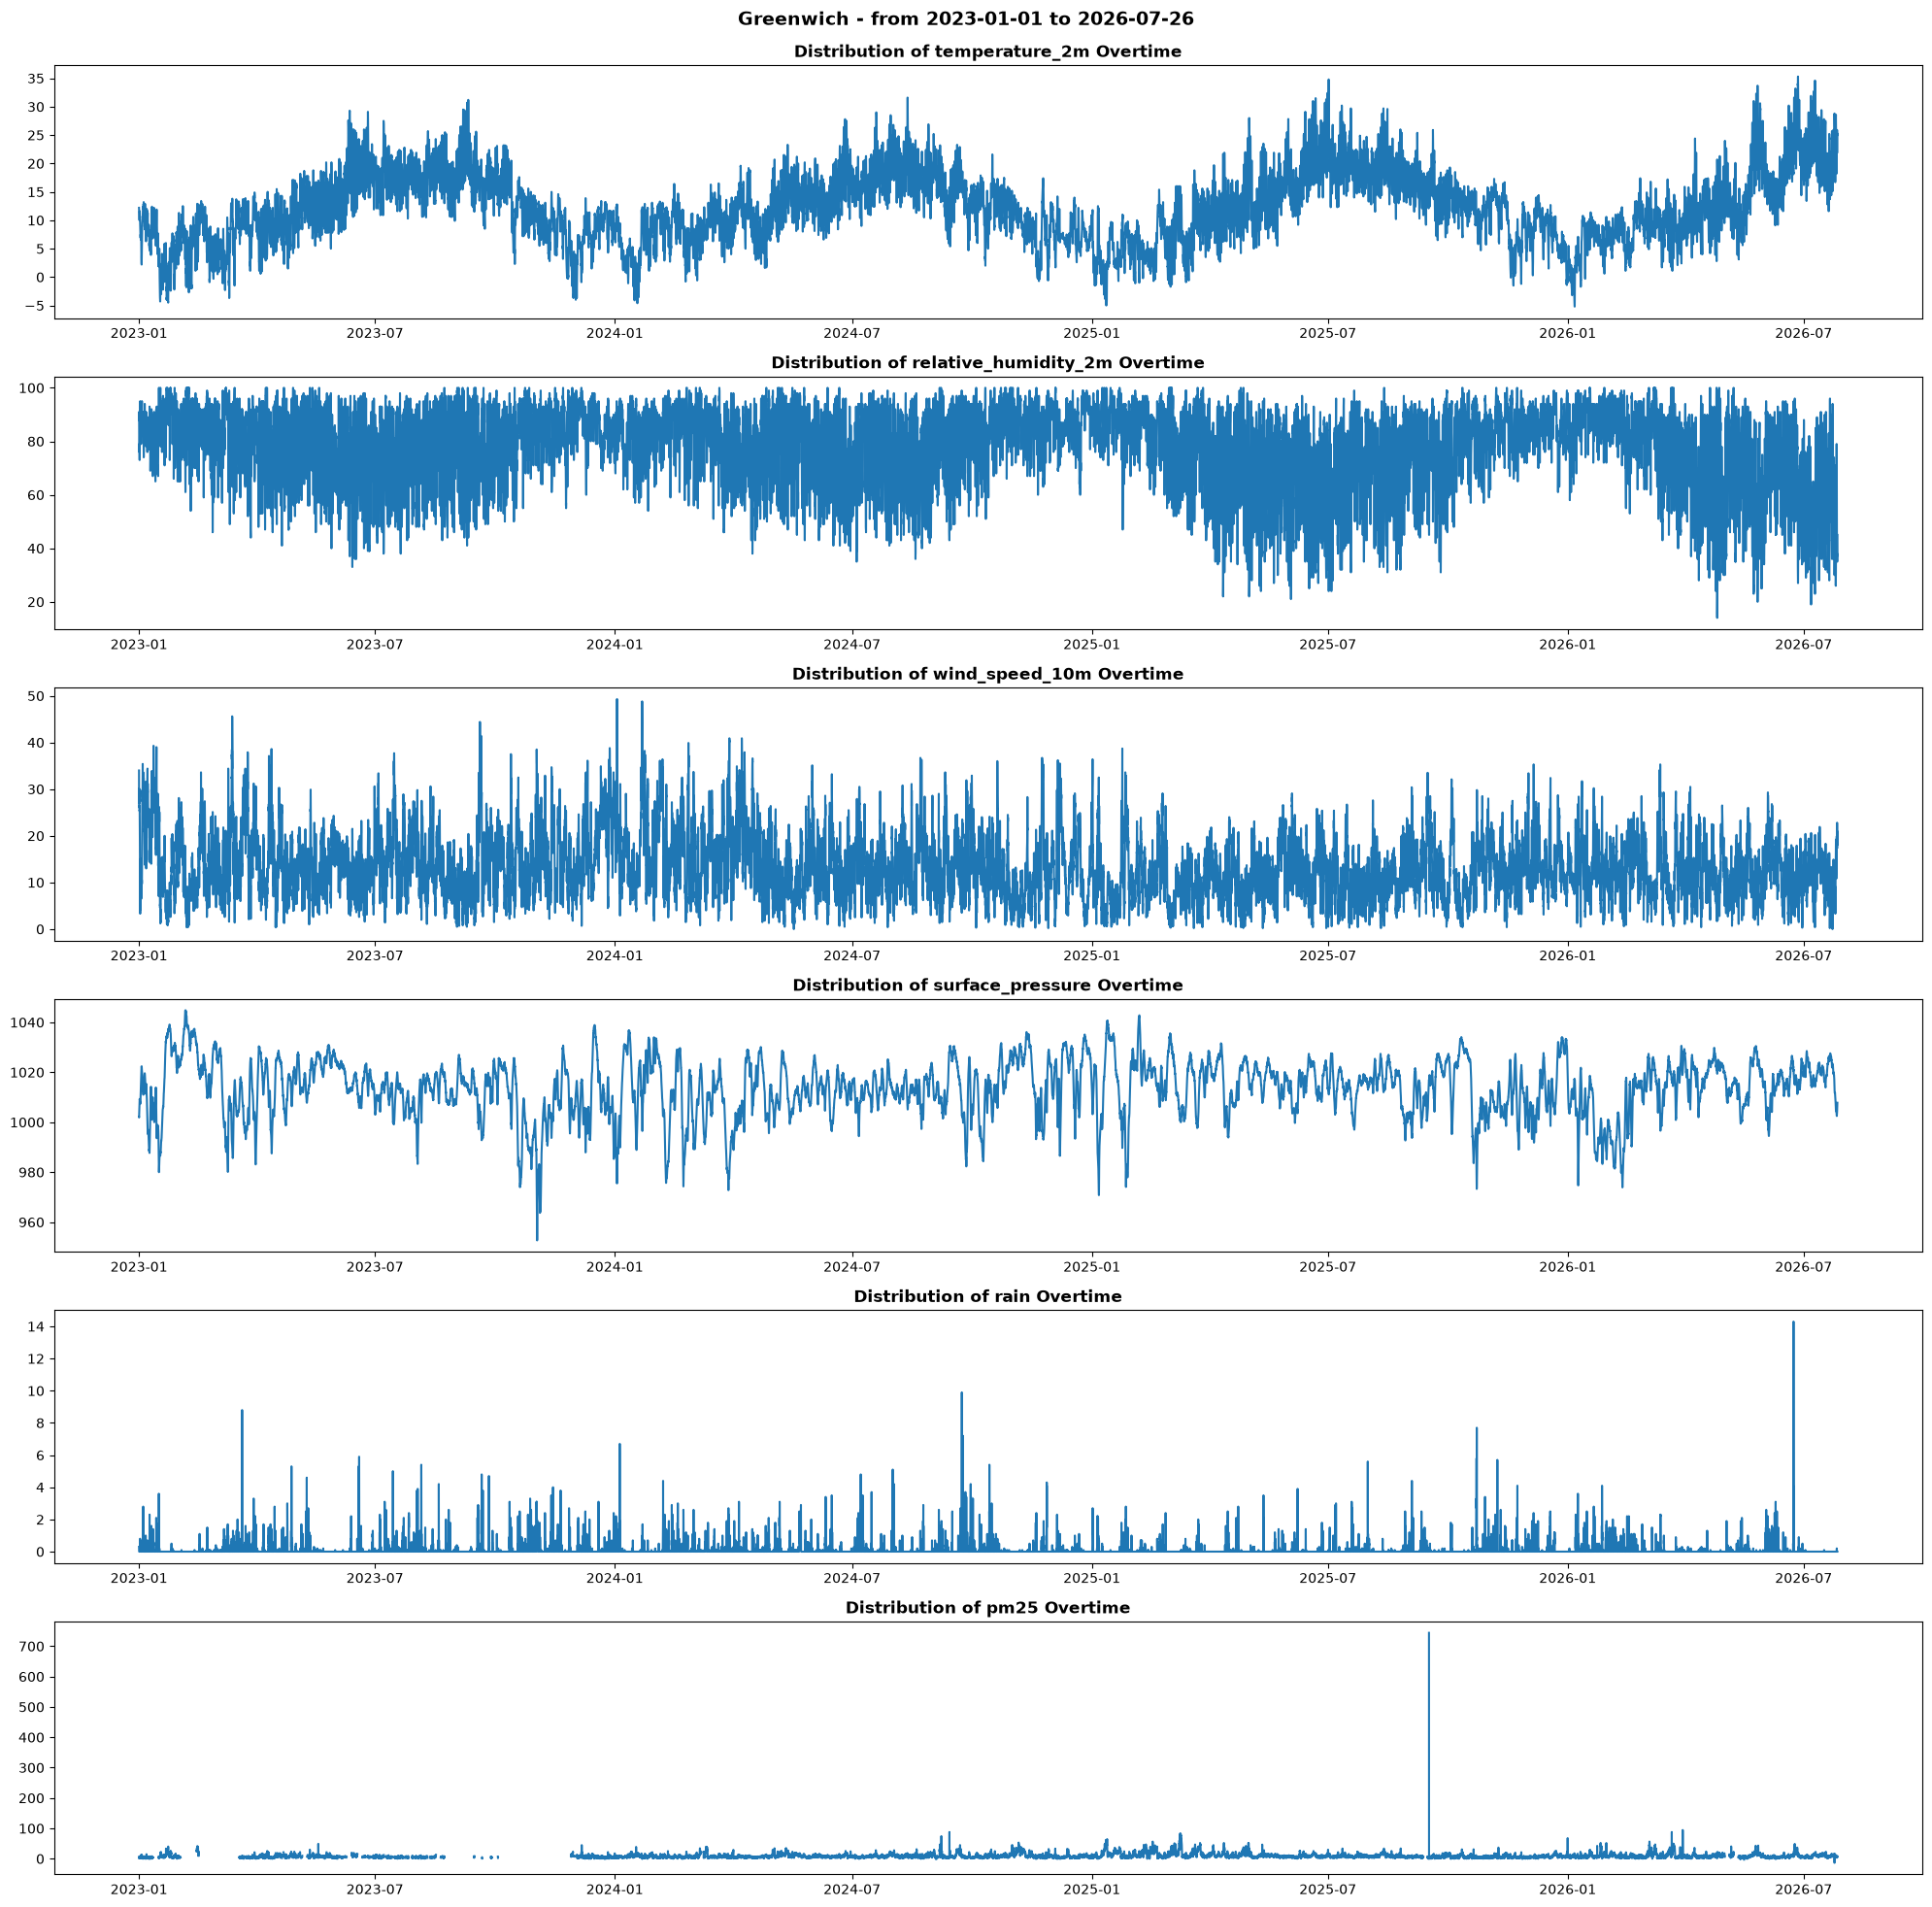

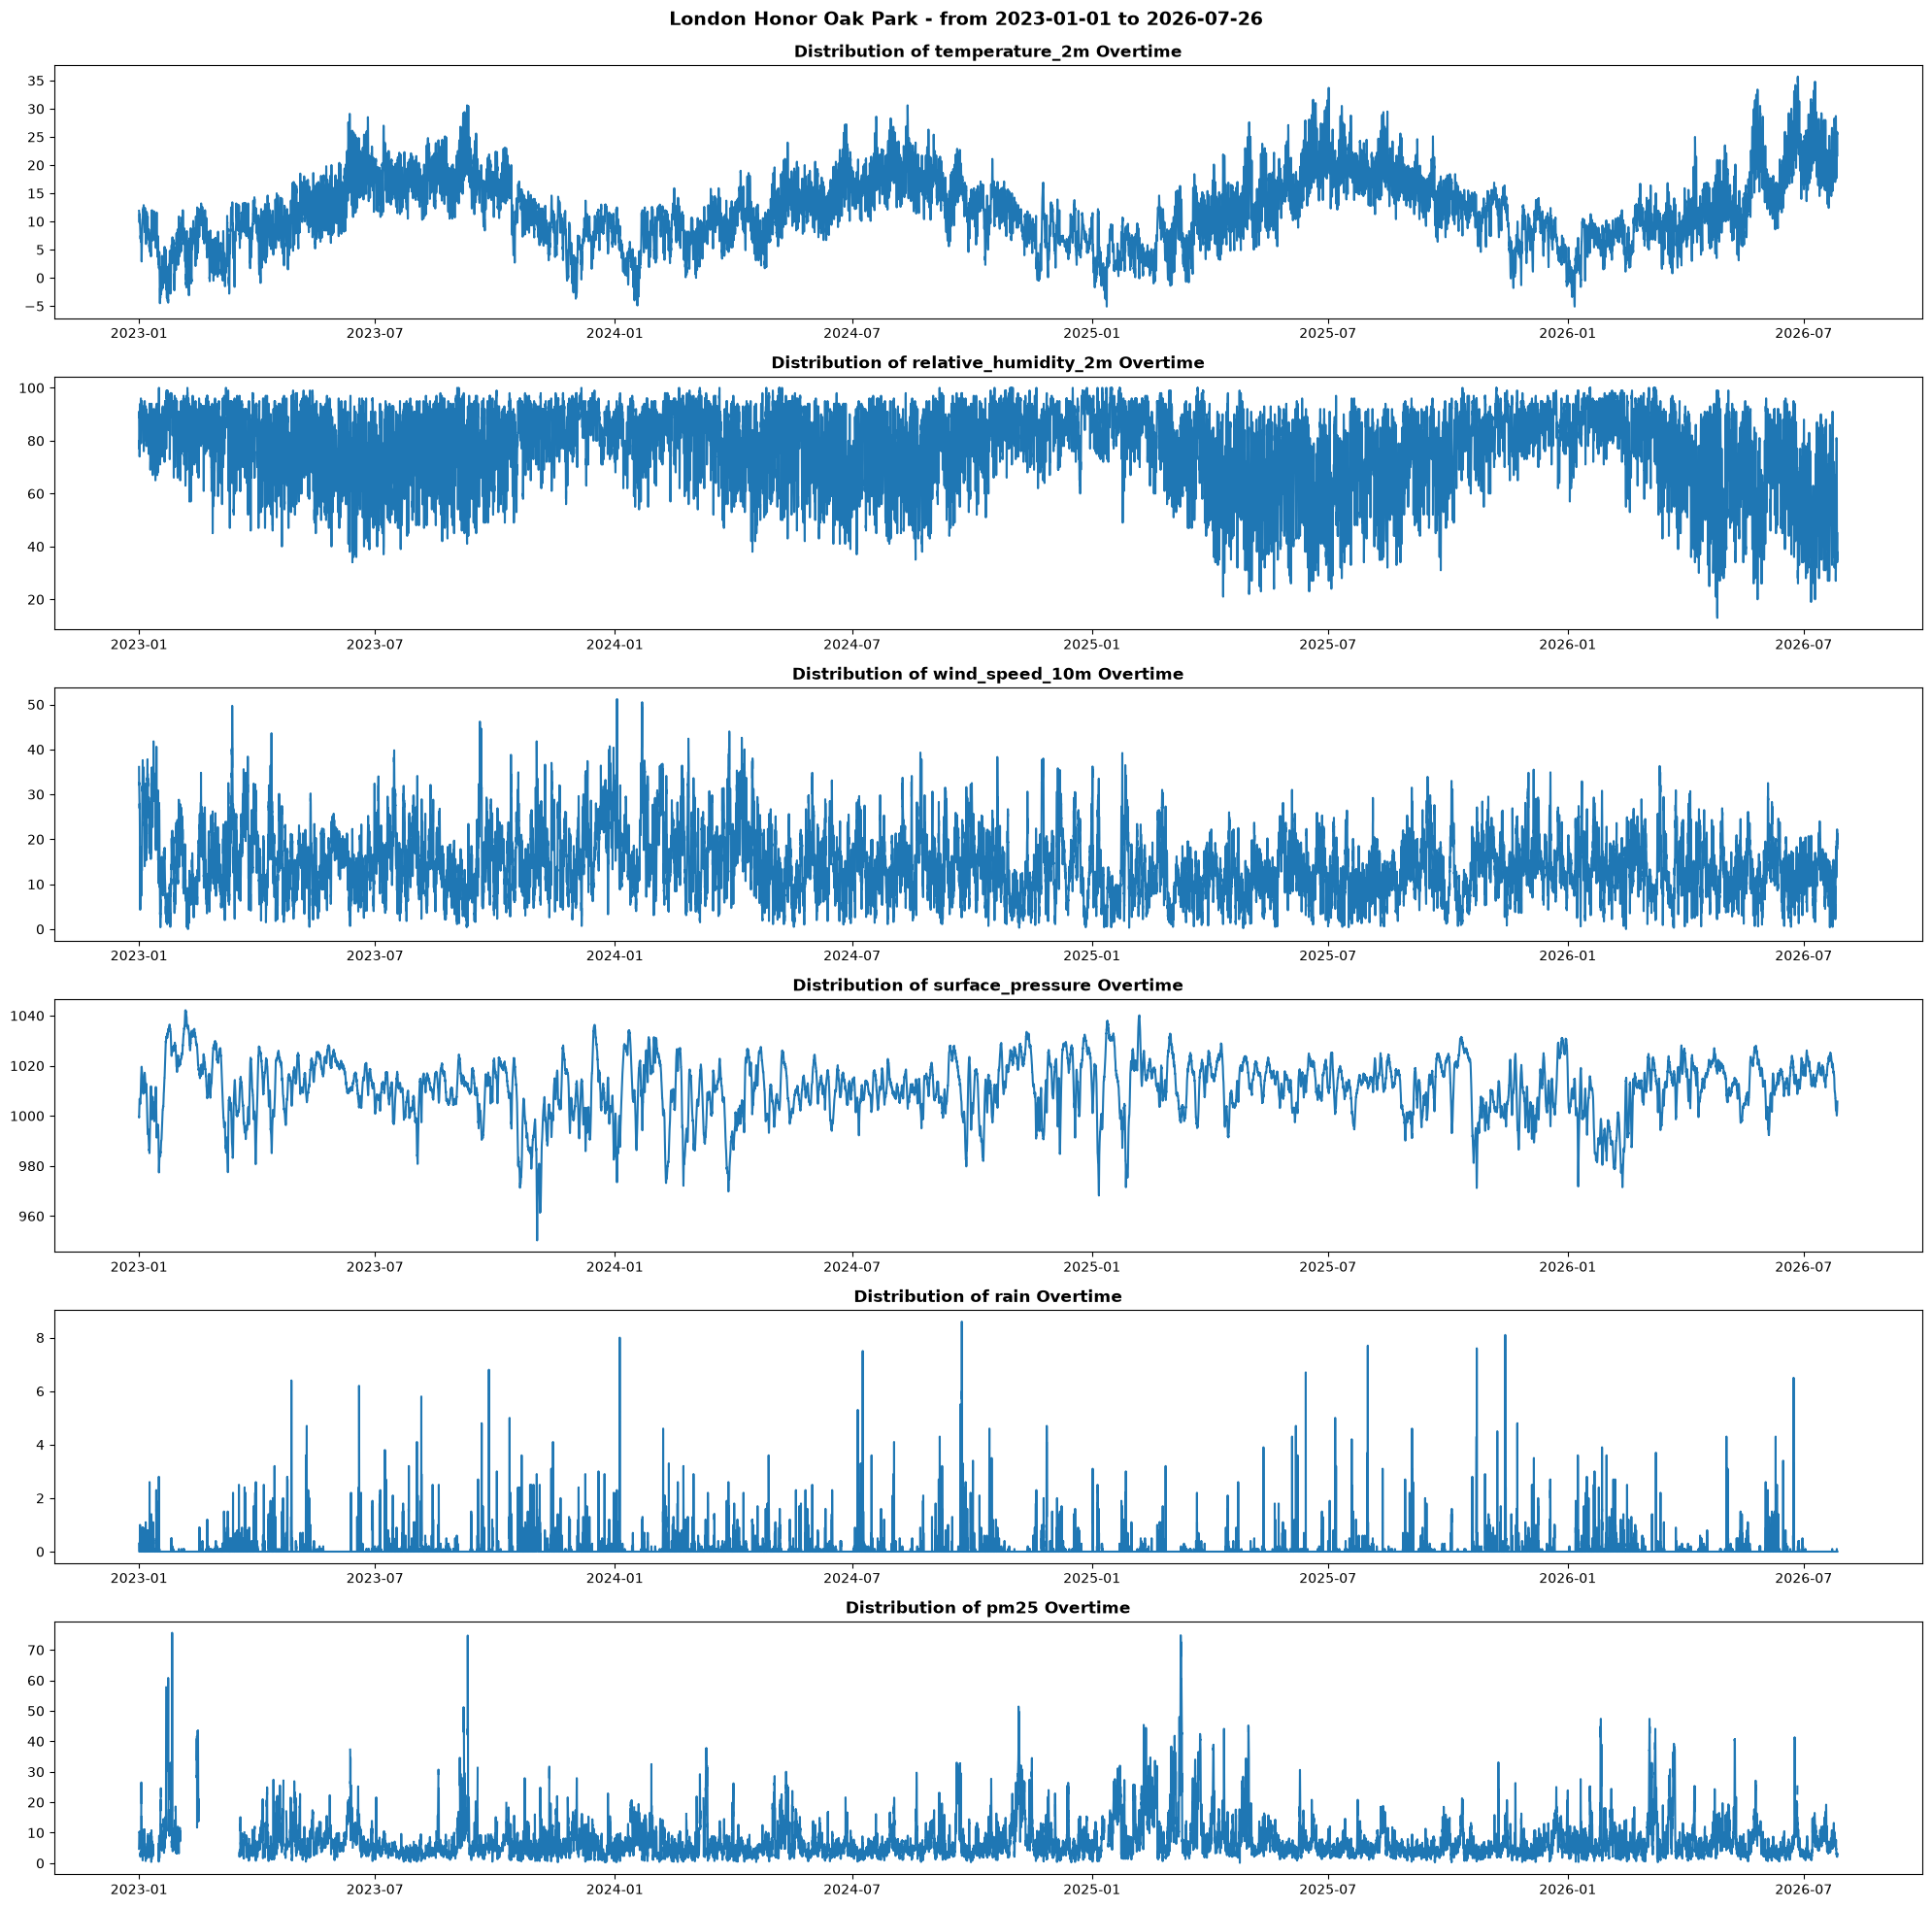

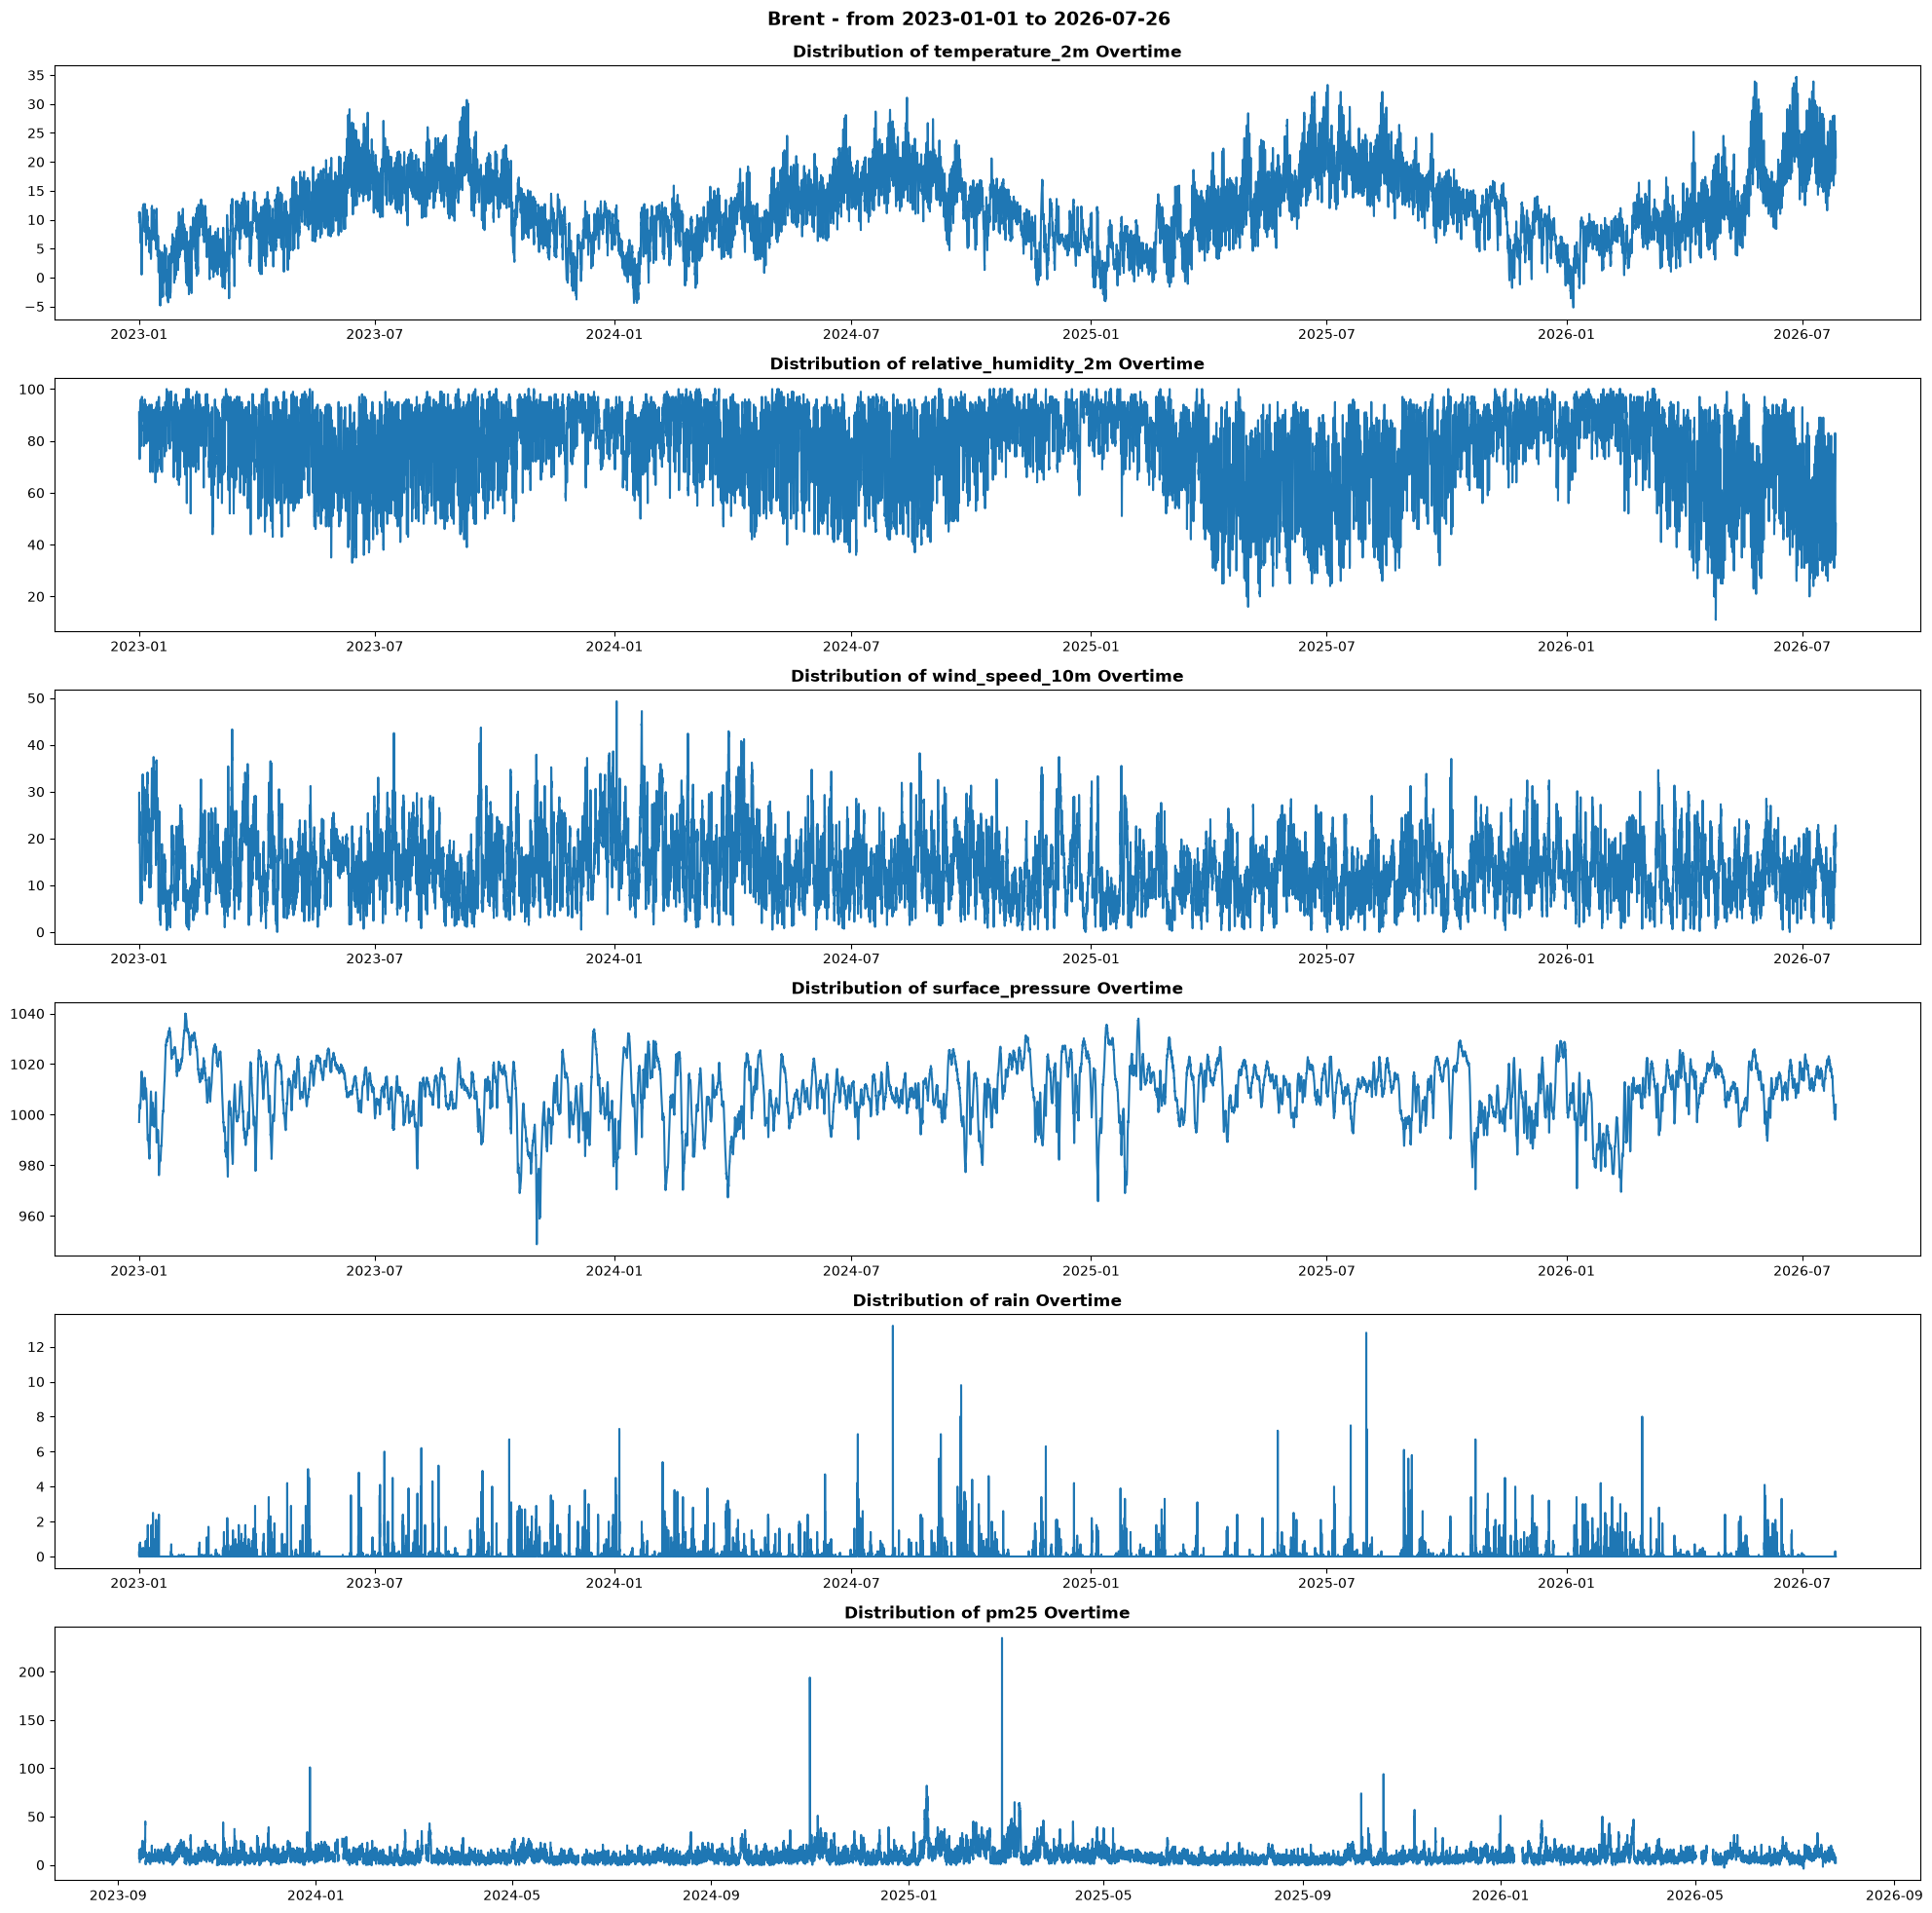

In [14]:
forbid = ['sensor_id', 'station_id', 'longitude', 'latitude']
cols = [col for col in df.select_dtypes(include='number').columns if col not in forbid]
time_min = df['time_reading'].min().strftime('%Y-%m-%d')
time_max = df['time_reading'].max().strftime('%Y-%m-%d')

stations = df['station_name'].unique()
for station in stations:
    df_temp = df[df['station_name']==station]
    plt.figure(figsize=(20, 20))
    for i, col in enumerate(cols):
        plt.subplot(len(cols), 1, i+1)
        plt.plot(df_temp['time_reading'], df_temp[col])
        plt.title(f'Distribution of {col} Overtime', fontsize=12, fontweight='bold')
    plt.suptitle(f'{station} - from {time_min} to {time_max}\n', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# **Pre-Processing**
---
---

In [15]:
df_prepped = df.copy()

## **1. Handling Missing Values**
---
Source: https://www.epa.gov/outdoor-air-quality-data/about-airdata-reports

In [16]:
stations = df_prepped['station_name'].unique()
for station in stations:
    # Loops through the stations, flags and removes any stations with >= 30% of its values missing
    df_temp = df_prepped[df_prepped['station_name']==station]
    missing_pm25 = df_temp['pm25'].isnull().sum()
    pct_missing = (missing_pm25/len(df_temp))*100
    print(f'Missing value at {station}: {missing_pm25} - {round(pct_missing, 3)} of {station} records')

    if pct_missing>=30:
        print(f'Removing {station} records because its records are >=30% missing')
        df_prepped = df_prepped[df_prepped['station_name'] != station]
        df_prepped.reset_index(inplace=True, drop=True)        

    print(' ')

print(f'Length before removal: {len(df_prepped)}')

# Removing certain days, where 25% or more of its hours does not have a pm25 reading
daily_nan_pct = df_prepped.groupby(by=['station_id', pd.Grouper(key='time_reading', freq='D')])['pm25'].apply(lambda x: x.isna().sum()/24) # getting number of missing hours for each day for each station
valid_days = daily_nan_pct[daily_nan_pct<=0.25].index

df_prepped = df_prepped.set_index(['station_id', df_prepped['time_reading'].dt.floor('D')], drop=False).loc[valid_days].reset_index(drop=True)

print(f'Length after removal: {len(df_prepped)}')

Missing value at Waterloo Place: 5621 - 17.976 of Waterloo Place records
 
Missing value at London Westminster: 9694 - 31.001 of London Westminster records
Removing London Westminster records because its records are >=30% missing
 
Missing value at Camden Kerbside: 8312 - 26.581 of Camden Kerbside records
 
Missing value at Tower Hamlets: 20182 - 64.541 of Tower Hamlets records
Removing Tower Hamlets records because its records are >=30% missing
 
Missing value at Greenwich: 5650 - 18.068 of Greenwich records
 
Missing value at London Honor Oak Park: 2079 - 6.649 of London Honor Oak Park records
 
Missing value at Brent: 7127 - 22.793 of Brent records
 
Length before removal: 156349
Length after removal: 127886


In [17]:
# interpolation - done for each specific station
stations = df_prepped['station_name'].unique()
list_prepped = []
for station in stations:
    df_temp = df_prepped[df_prepped['station_name']==station]
    #df_temp = df_temp.set_index('time_reading', drop=False)
    df_temp['pm25'] = df_temp['pm25'].interpolate(method='polynomial', order=2)
    df_temp = df_temp.reset_index(drop=True)

    list_prepped.append(df_temp)
    print(f'Processed {station}')

df_prepped = pd.concat(list_prepped, axis=0, ignore_index=True)
display(df_prepped.isnull().sum())

Processed Camden Kerbside
Processed Brent
Processed Greenwich
Processed London Honor Oak Park
Processed Waterloo Place


weather_id              0
sensor_id               0
station_id              0
station_name            0
time_reading            0
temperature_2m          0
relative_humidity_2m    0
wind_speed_10m          0
surface_pressure        0
rain                    0
pm25                    0
longitude               0
latitude                0
dtype: int64

In [18]:
df_prepped

,weather_id,sensor_id,station_id,station_name,time_reading,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,rain,pm25,longitude,latitude
0,W235_2023010100,235,152,Camden Kerbside,2023-01-01 00:00:00,11.9,91.0,34.0,995.2,0.8,7.0,-0.175269,51.544210
1,W235_2023010101,235,152,Camden Kerbside,2023-01-01 01:00:00,10.9,92.0,19.4,995.4,0.2,7.0,-0.175269,51.544210
2,W235_2023010102,235,152,Camden Kerbside,2023-01-01 02:00:00,11.6,88.0,29.3,996.0,0.9,7.0,-0.175269,51.544210
3,W235_2023010103,235,152,Camden Kerbside,2023-01-01 03:00:00,10.9,82.0,31.9,996.9,0.0,7.0,-0.175269,51.544210
4,W235_2023010104,235,152,Camden Kerbside,2023-01-01 04:00:00,10.2,80.0,30.7,998.0,0.0,8.0,-0.175269,51.544210
...,...,...,...,...,...,...,...,...,...,...,...,...,...
127881,W1561901_2026072617,1561901,270693,Waterloo Place,2026-07-26 17:00:00,25.1,37.0,17.4,1002.7,0.0,4.4,-0.133068,51.507582
127882,W1561901_2026072618,1561901,270693,Waterloo Place,2026-07-26 18:00:00,24.7,37.0,21.2,1003.3,0.0,5.0,-0.133068,51.507582
127883,W1561901_2026072619,1561901,270693,Waterloo Place,2026-07-26 19:00:00,23.3,41.0,18.0,1004.2,0.0,4.3,-0.133068,51.507582
127884,W1561901_2026072620,1561901,270693,Waterloo Place,2026-07-26 20:00:00,22.5,43.0,17.7,1004.8,0.0,3.5,-0.133068,51.507582


## **2. Handling Outliers**
---

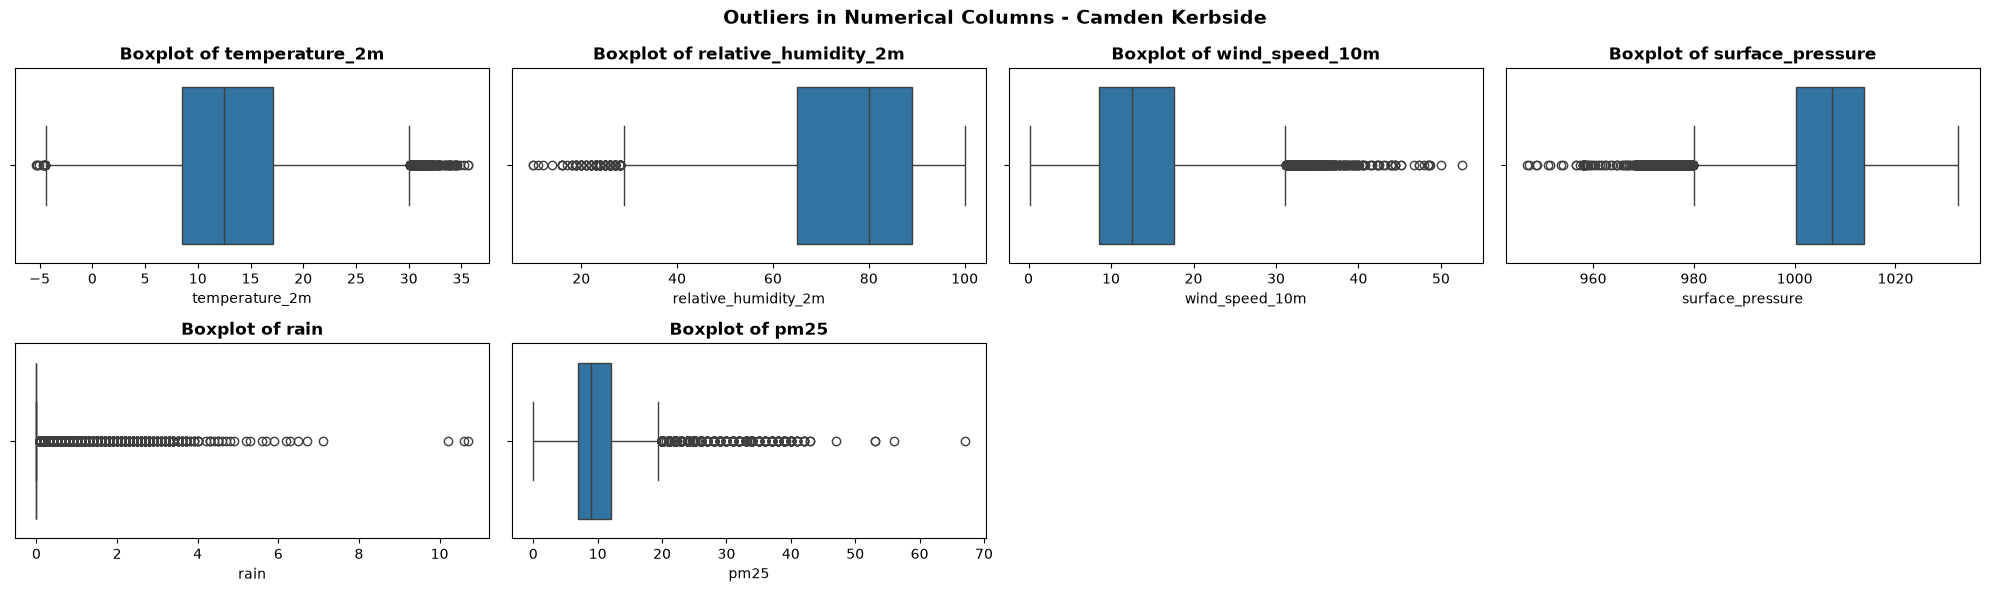

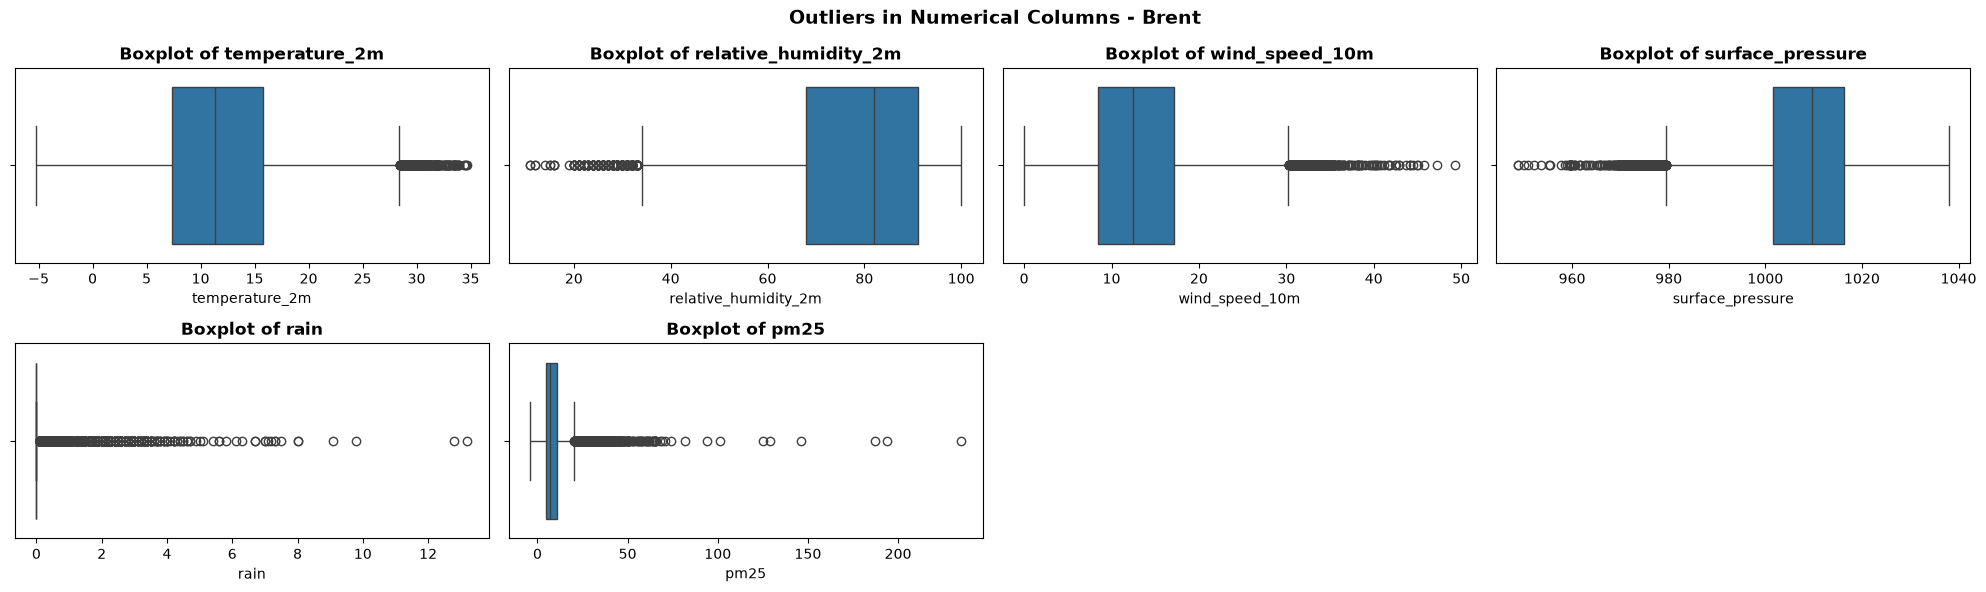

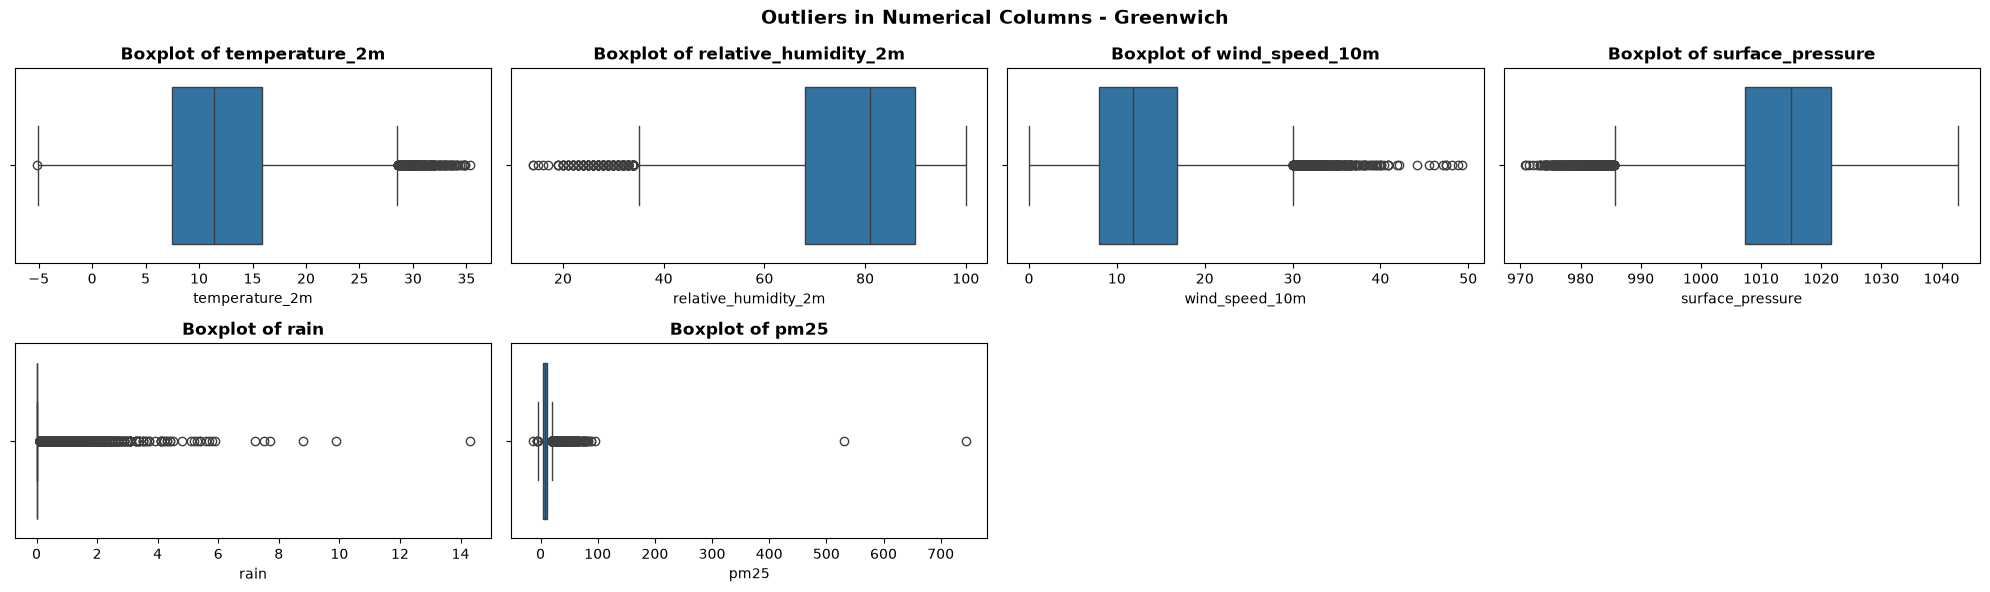

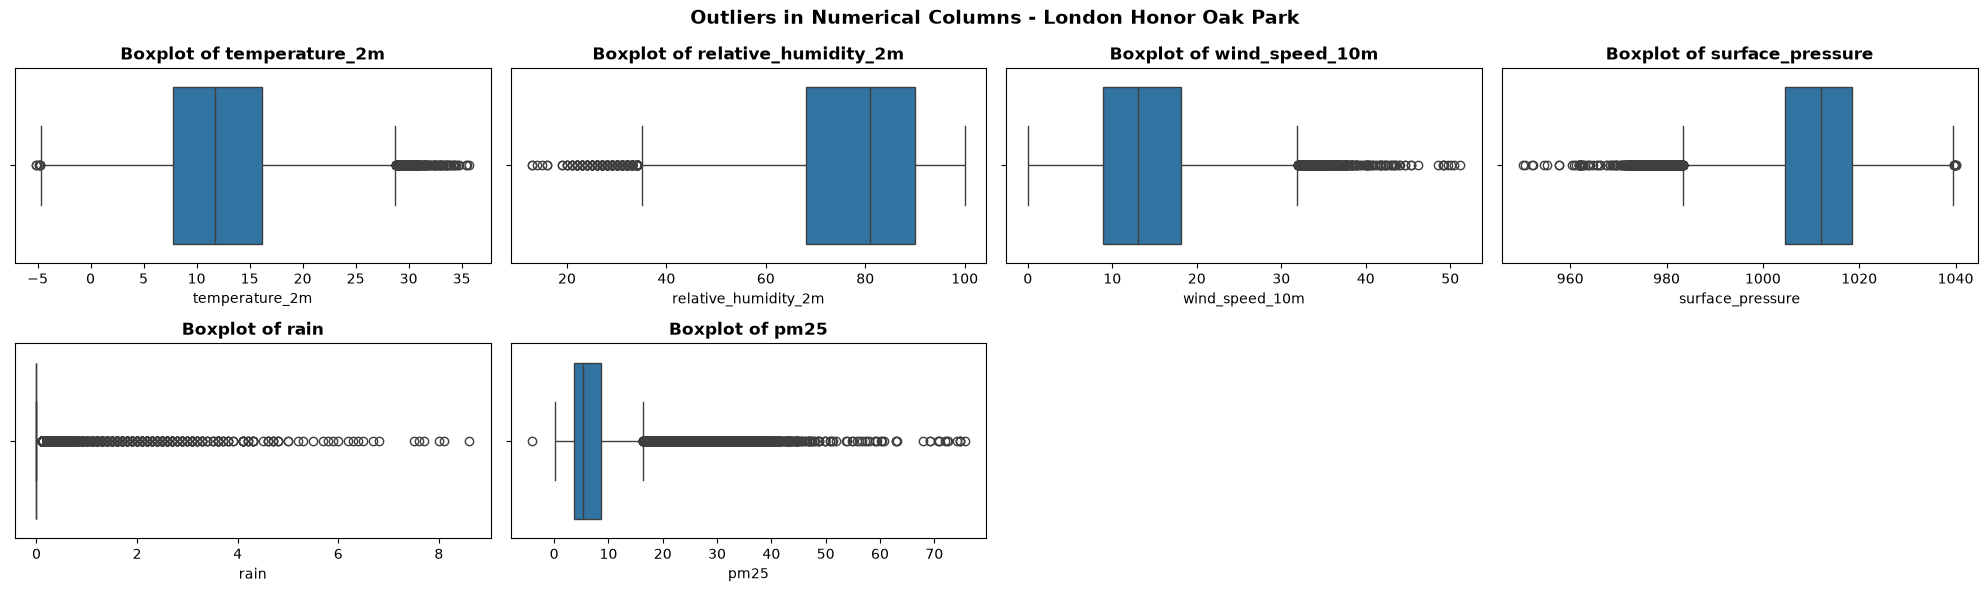

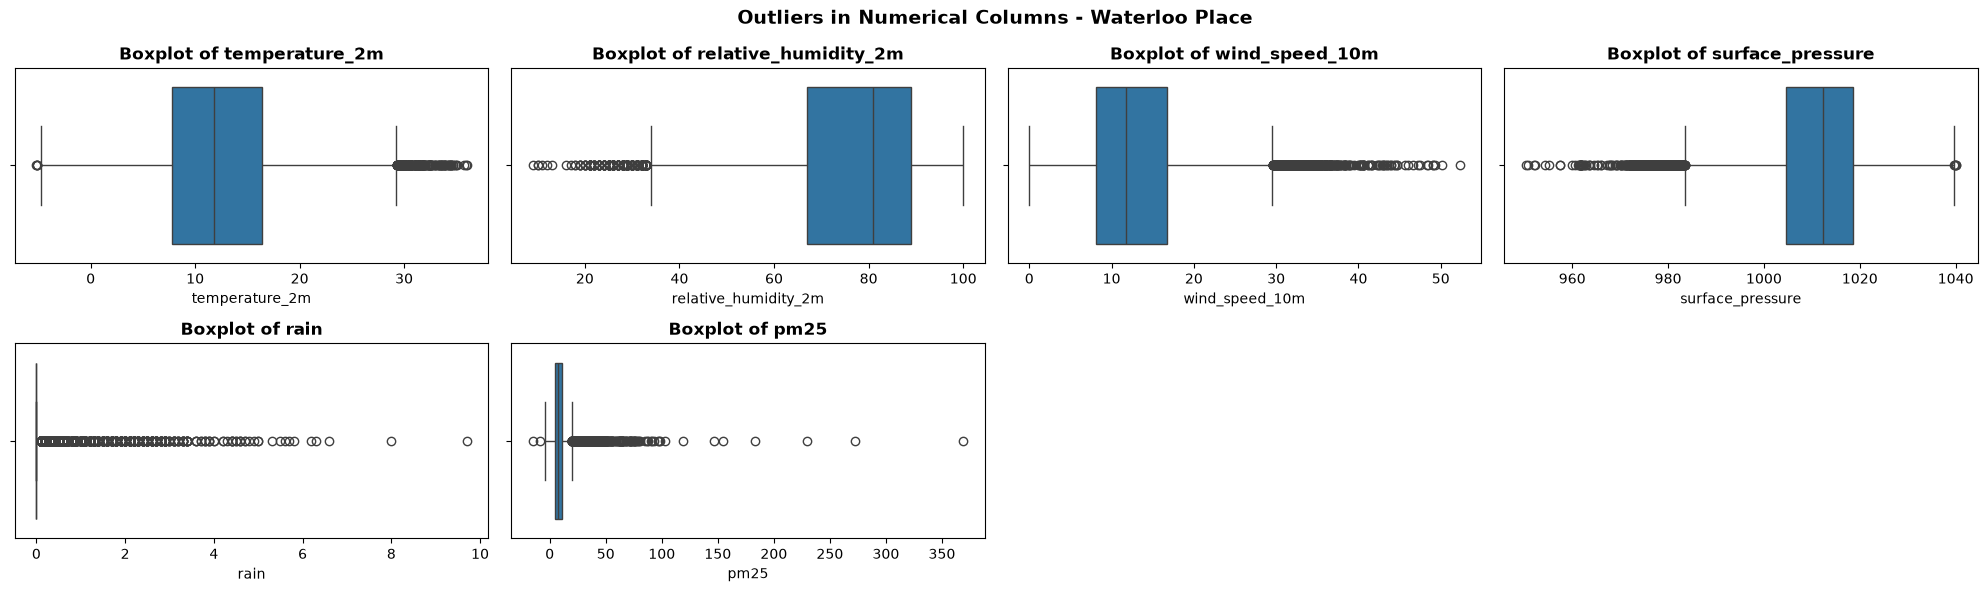

In [19]:
forbid = ['sensor_id', 'station_id', 'longitude', 'latitude']
cols = [col for col in df_prepped.select_dtypes(include='number').columns if col not in forbid]

for station in df_prepped['station_name'].unique():
    temp = df_prepped[df_prepped['station_name']==station]
    plt.figure(figsize=(20, 6))
    for i, col in enumerate(cols):
        plt.subplot(2, 4, i+1)
        sns.boxplot(x=temp[col])
        plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    plt.suptitle(f'Outliers in Numerical Columns - {station}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(' ')

In [20]:
q1 = df_prepped['pm25'].quantile(0.25)
q3 = df_prepped['pm25'].quantile(0.75)
iqr=q3-q1

df_outliers = df_prepped[(df_prepped['pm25'] < (q1-1.5*iqr)) | (df_prepped['pm25'] > (q3+1.5*iqr))]
display(df_outliers)

# As the numbers of outliers are very high, only extreme, impossible values are removed
df_prepped.loc[df_prepped['pm25']>=100] = None

stations = df_prepped['station_name'].unique()
list_prepped = []
for station in stations:
    df_temp = df_prepped[df_prepped['station_name']==station]
    #df_temp = df_temp.set_index('time_reading', drop=False)
    df_temp['pm25'] = df_temp['pm25'].interpolate(method='polynomial', order=3)
    df_temp = df_temp.reset_index(drop=True)

    list_prepped.append(df_temp)
    print(f'Processed {station}')

df_prepped = pd.concat(list_prepped, axis=0, ignore_index=True)
display(df_prepped.isnull().sum())

,weather_id,sensor_id,station_id,station_name,time_reading,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,rain,pm25,longitude,latitude
236,W235_2023011720,235,152,Camden Kerbside,2023-01-17 20:00:00,-2.4,88.0,11.3,984.4,0.0,21.0,-0.175269,51.544210
237,W235_2023011721,235,152,Camden Kerbside,2023-01-17 21:00:00,-2.7,89.0,9.6,984.9,0.0,22.0,-0.175269,51.544210
238,W235_2023011722,235,152,Camden Kerbside,2023-01-17 22:00:00,-3.1,90.0,9.0,985.0,0.0,23.0,-0.175269,51.544210
239,W235_2023011723,235,152,Camden Kerbside,2023-01-17 23:00:00,-3.5,91.0,10.0,985.4,0.0,23.0,-0.175269,51.544210
240,W235_2023011800,235,152,Camden Kerbside,2023-01-18 00:00:00,-3.5,90.0,10.9,986.0,0.0,24.0,-0.175269,51.544210
...,...,...,...,...,...,...,...,...,...,...,...,...,...
127149,W1561901_2026062605,1561901,270693,Waterloo Place,2026-06-26 05:00:00,25.4,69.0,6.0,1008.5,0.0,27.7,-0.133068,51.507582
127150,W1561901_2026062606,1561901,270693,Waterloo Place,2026-06-26 06:00:00,25.9,65.0,6.4,1009.3,0.0,20.5,-0.133068,51.507582
127675,W1561901_2026071803,1561901,270693,Waterloo Place,2026-07-18 03:00:00,16.9,84.0,9.2,1014.9,0.0,20.5,-0.133068,51.507582
127676,W1561901_2026071804,1561901,270693,Waterloo Place,2026-07-18 04:00:00,16.4,82.0,8.5,1014.9,0.0,20.3,-0.133068,51.507582


Processed Camden Kerbside
Processed Brent
Processed nan
Processed Greenwich
Processed London Honor Oak Park
Processed Waterloo Place


weather_id              0
sensor_id               0
station_id              0
station_name            0
time_reading            0
temperature_2m          0
relative_humidity_2m    0
wind_speed_10m          0
surface_pressure        0
rain                    0
pm25                    0
longitude               0
latitude                0
dtype: int64

In [21]:
df_prepped['pm25'] = df_prepped['pm25'].ffill()
df_prepped.isnull().sum()

weather_id              0
sensor_id               0
station_id              0
station_name            0
time_reading            0
temperature_2m          0
relative_humidity_2m    0
wind_speed_10m          0
surface_pressure        0
rain                    0
pm25                    0
longitude               0
latitude                0
dtype: int64

## **3. Station Name Encoding**
---

In [22]:
def apply_encoding(x):
    if x=='Camden Kerbside':
        return 1
    elif x=='Greenwich':
        return 2
    elif x=='London Honor Oak Park':
        return 3
    elif x=='Waterloo Place':
        return 4
    elif x=='Brent':
        return 5
    
df_prepped['station_id'] = df_prepped['station_name'].apply(apply_encoding)

## **4. Feature Engineering**
---

### 4.1. Stationarity Test- ADFuller Test
---

In [23]:
def check_stationarity(data):
    test = adfuller(data)

    results = {
        'f_stat': test[0],
        'p_val': test[1]
    }

    if results['p_val'] <= 0.05:
        return 'stationary', results
    else:
        return 'non-stationary', results

for station in df_prepped['station_name'].unique():
    curr = df_prepped[df_prepped['station_name']==station]
    print(f'Checking stationarity for {station}')

    for col in curr.select_dtypes(include='number').columns:
        if col in ['longitude', 'latitude', 'station_id', 'sensor_id']:
            continue
        verdict, result = check_stationarity(curr[col])
        print(f'Stationarity at {col}: {verdict}, p_value = {result['p_val']}')
    print(' ')

Checking stationarity for Camden Kerbside
Stationarity at temperature_2m: stationary, p_value = 1.4248601951216406e-05
Stationarity at relative_humidity_2m: stationary, p_value = 1.667798942561322e-09
Stationarity at wind_speed_10m: stationary, p_value = 4.3012050734337855e-26
Stationarity at surface_pressure: stationary, p_value = 1.509484175703475e-20
Stationarity at rain: stationary, p_value = 0.0
Stationarity at pm25: stationary, p_value = 1.7852433391802372e-24
 
Checking stationarity for Brent
Stationarity at temperature_2m: stationary, p_value = 7.314941098225541e-08
Stationarity at relative_humidity_2m: stationary, p_value = 1.1318675366645401e-10
Stationarity at wind_speed_10m: stationary, p_value = 1.9832286834726824e-27
Stationarity at surface_pressure: stationary, p_value = 2.441810055935571e-21
Stationarity at rain: stationary, p_value = 0.0
Stationarity at pm25: stationary, p_value = 6.29267345247699e-25
 
Checking stationarity for Greenwich
Stationarity at temperature_2m

### 4.2. ACF/PACF Plots
---

In [24]:
[col for col in df_prepped.select_dtypes(include='number').columns if col not in ['longitude', 'latitude', 'station_id', 'sensor_id']]

['temperature_2m',
 'relative_humidity_2m',
 'wind_speed_10m',
 'surface_pressure',
 'rain',
 'pm25']

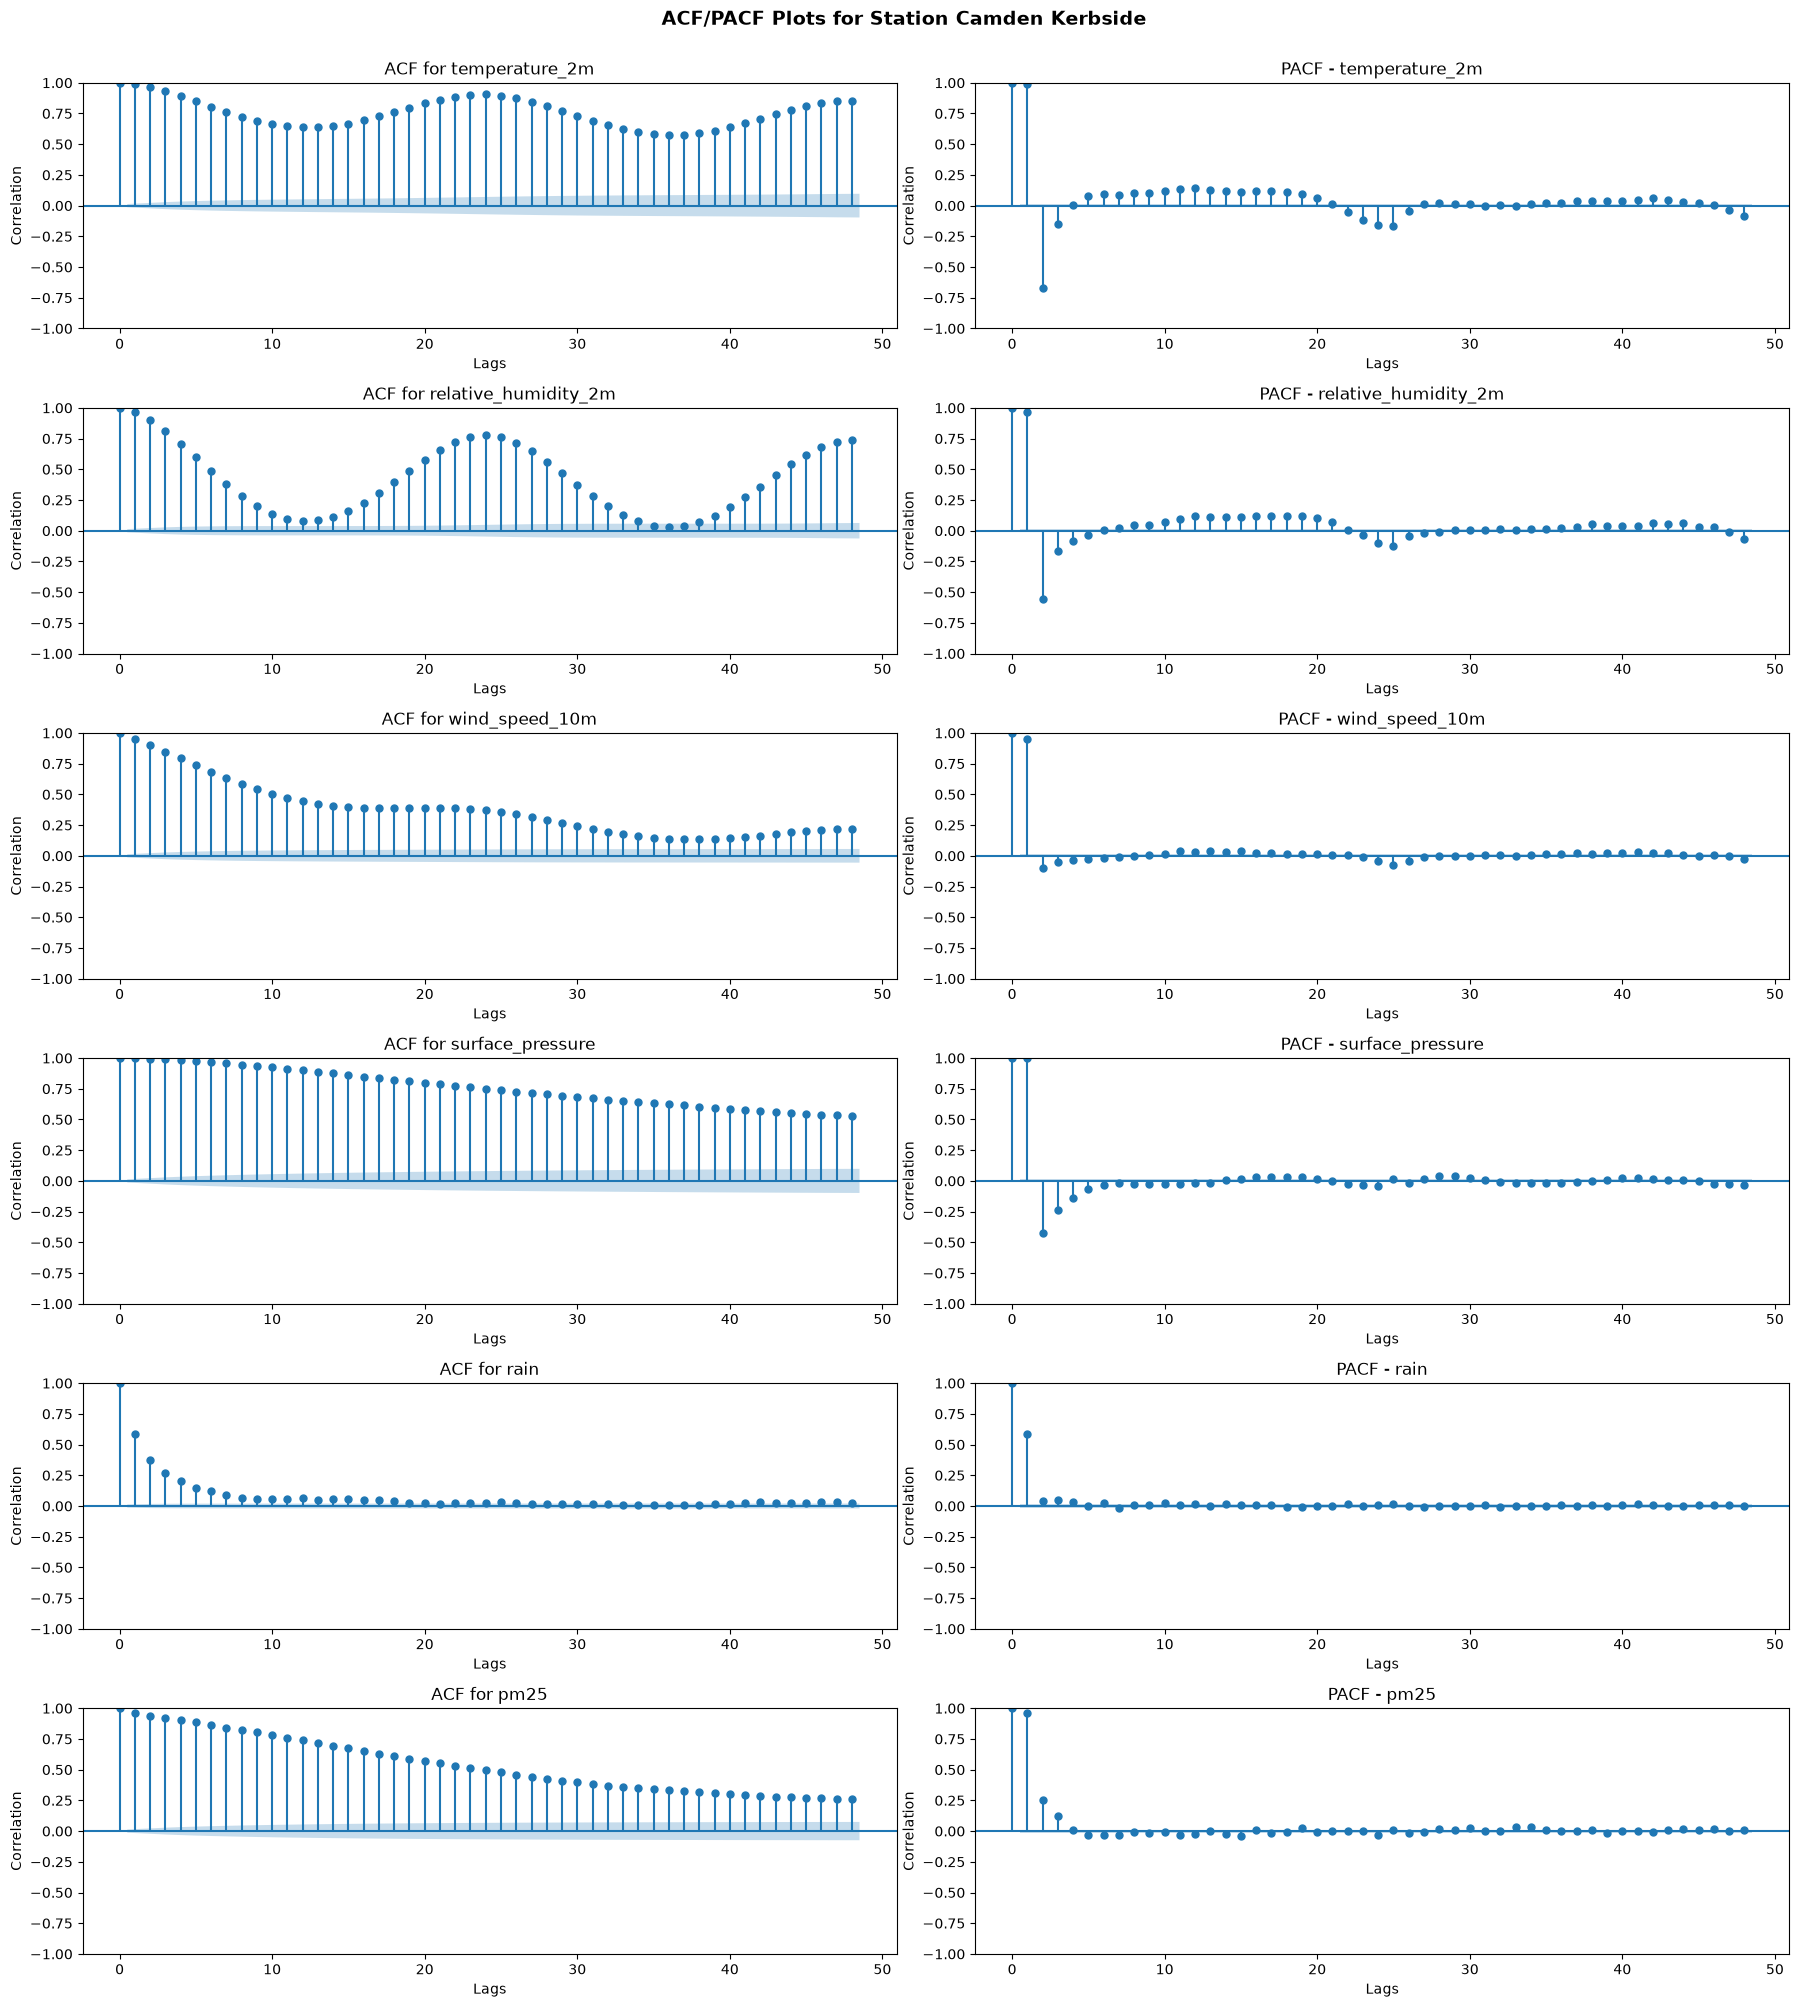

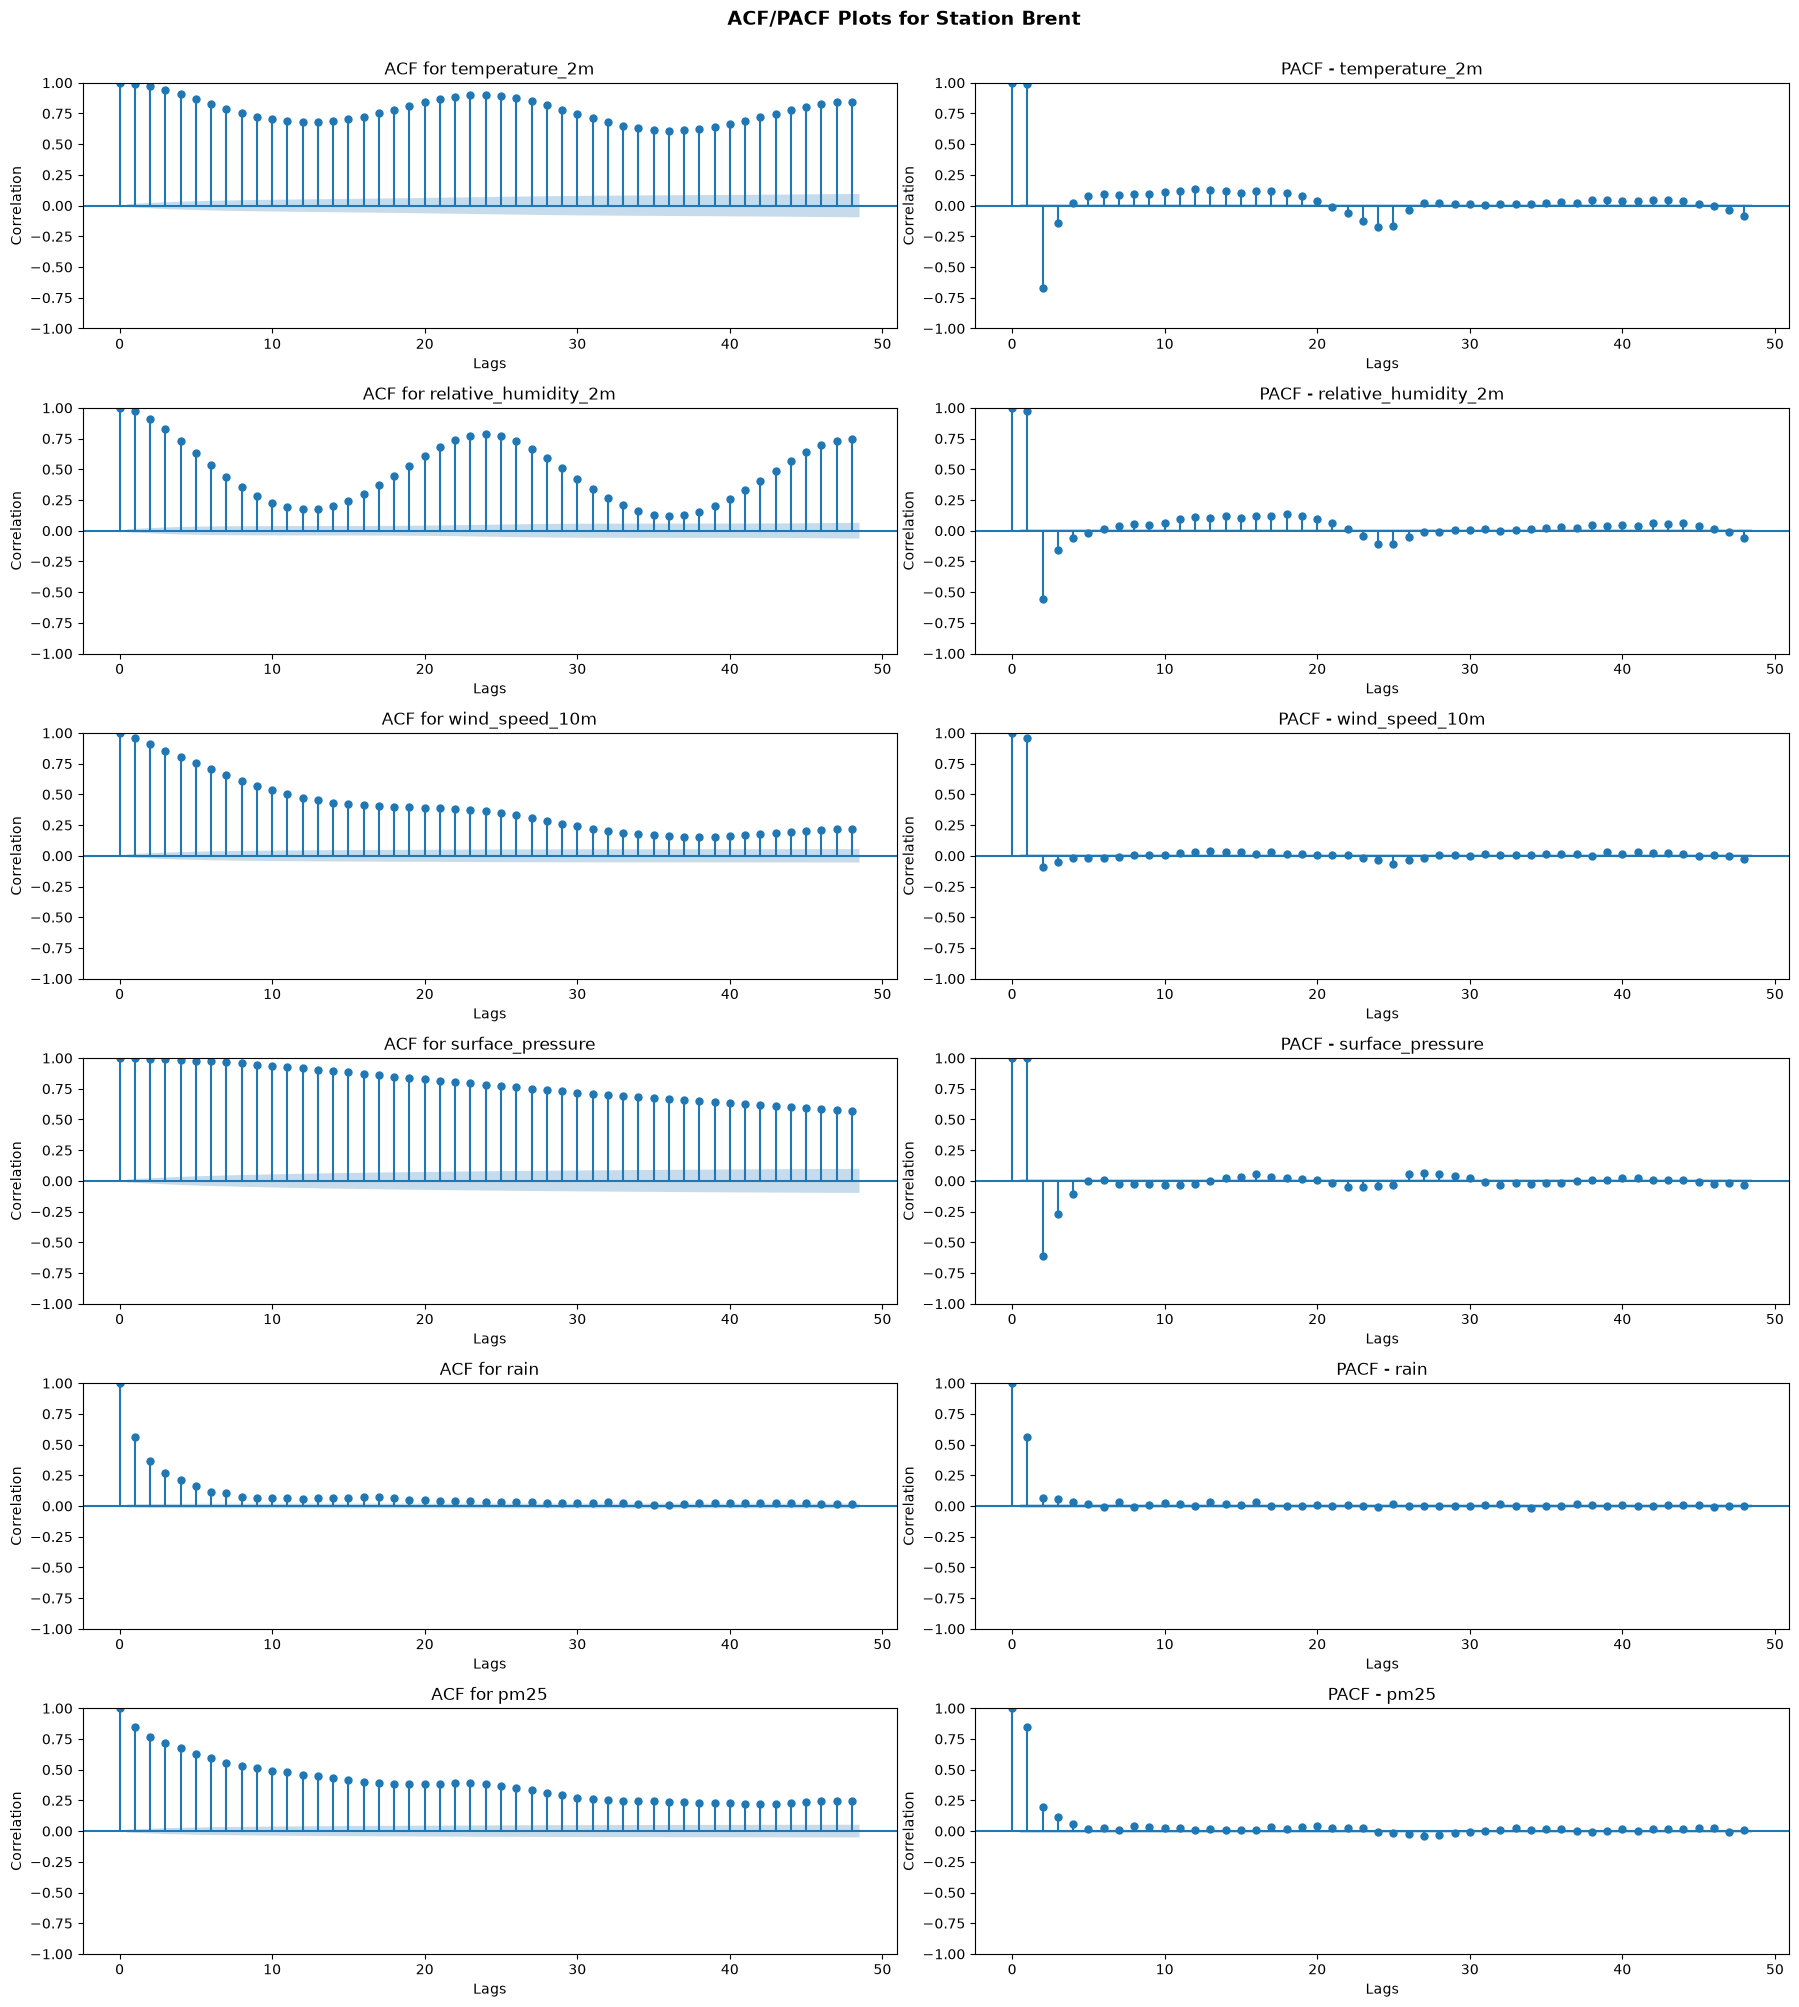

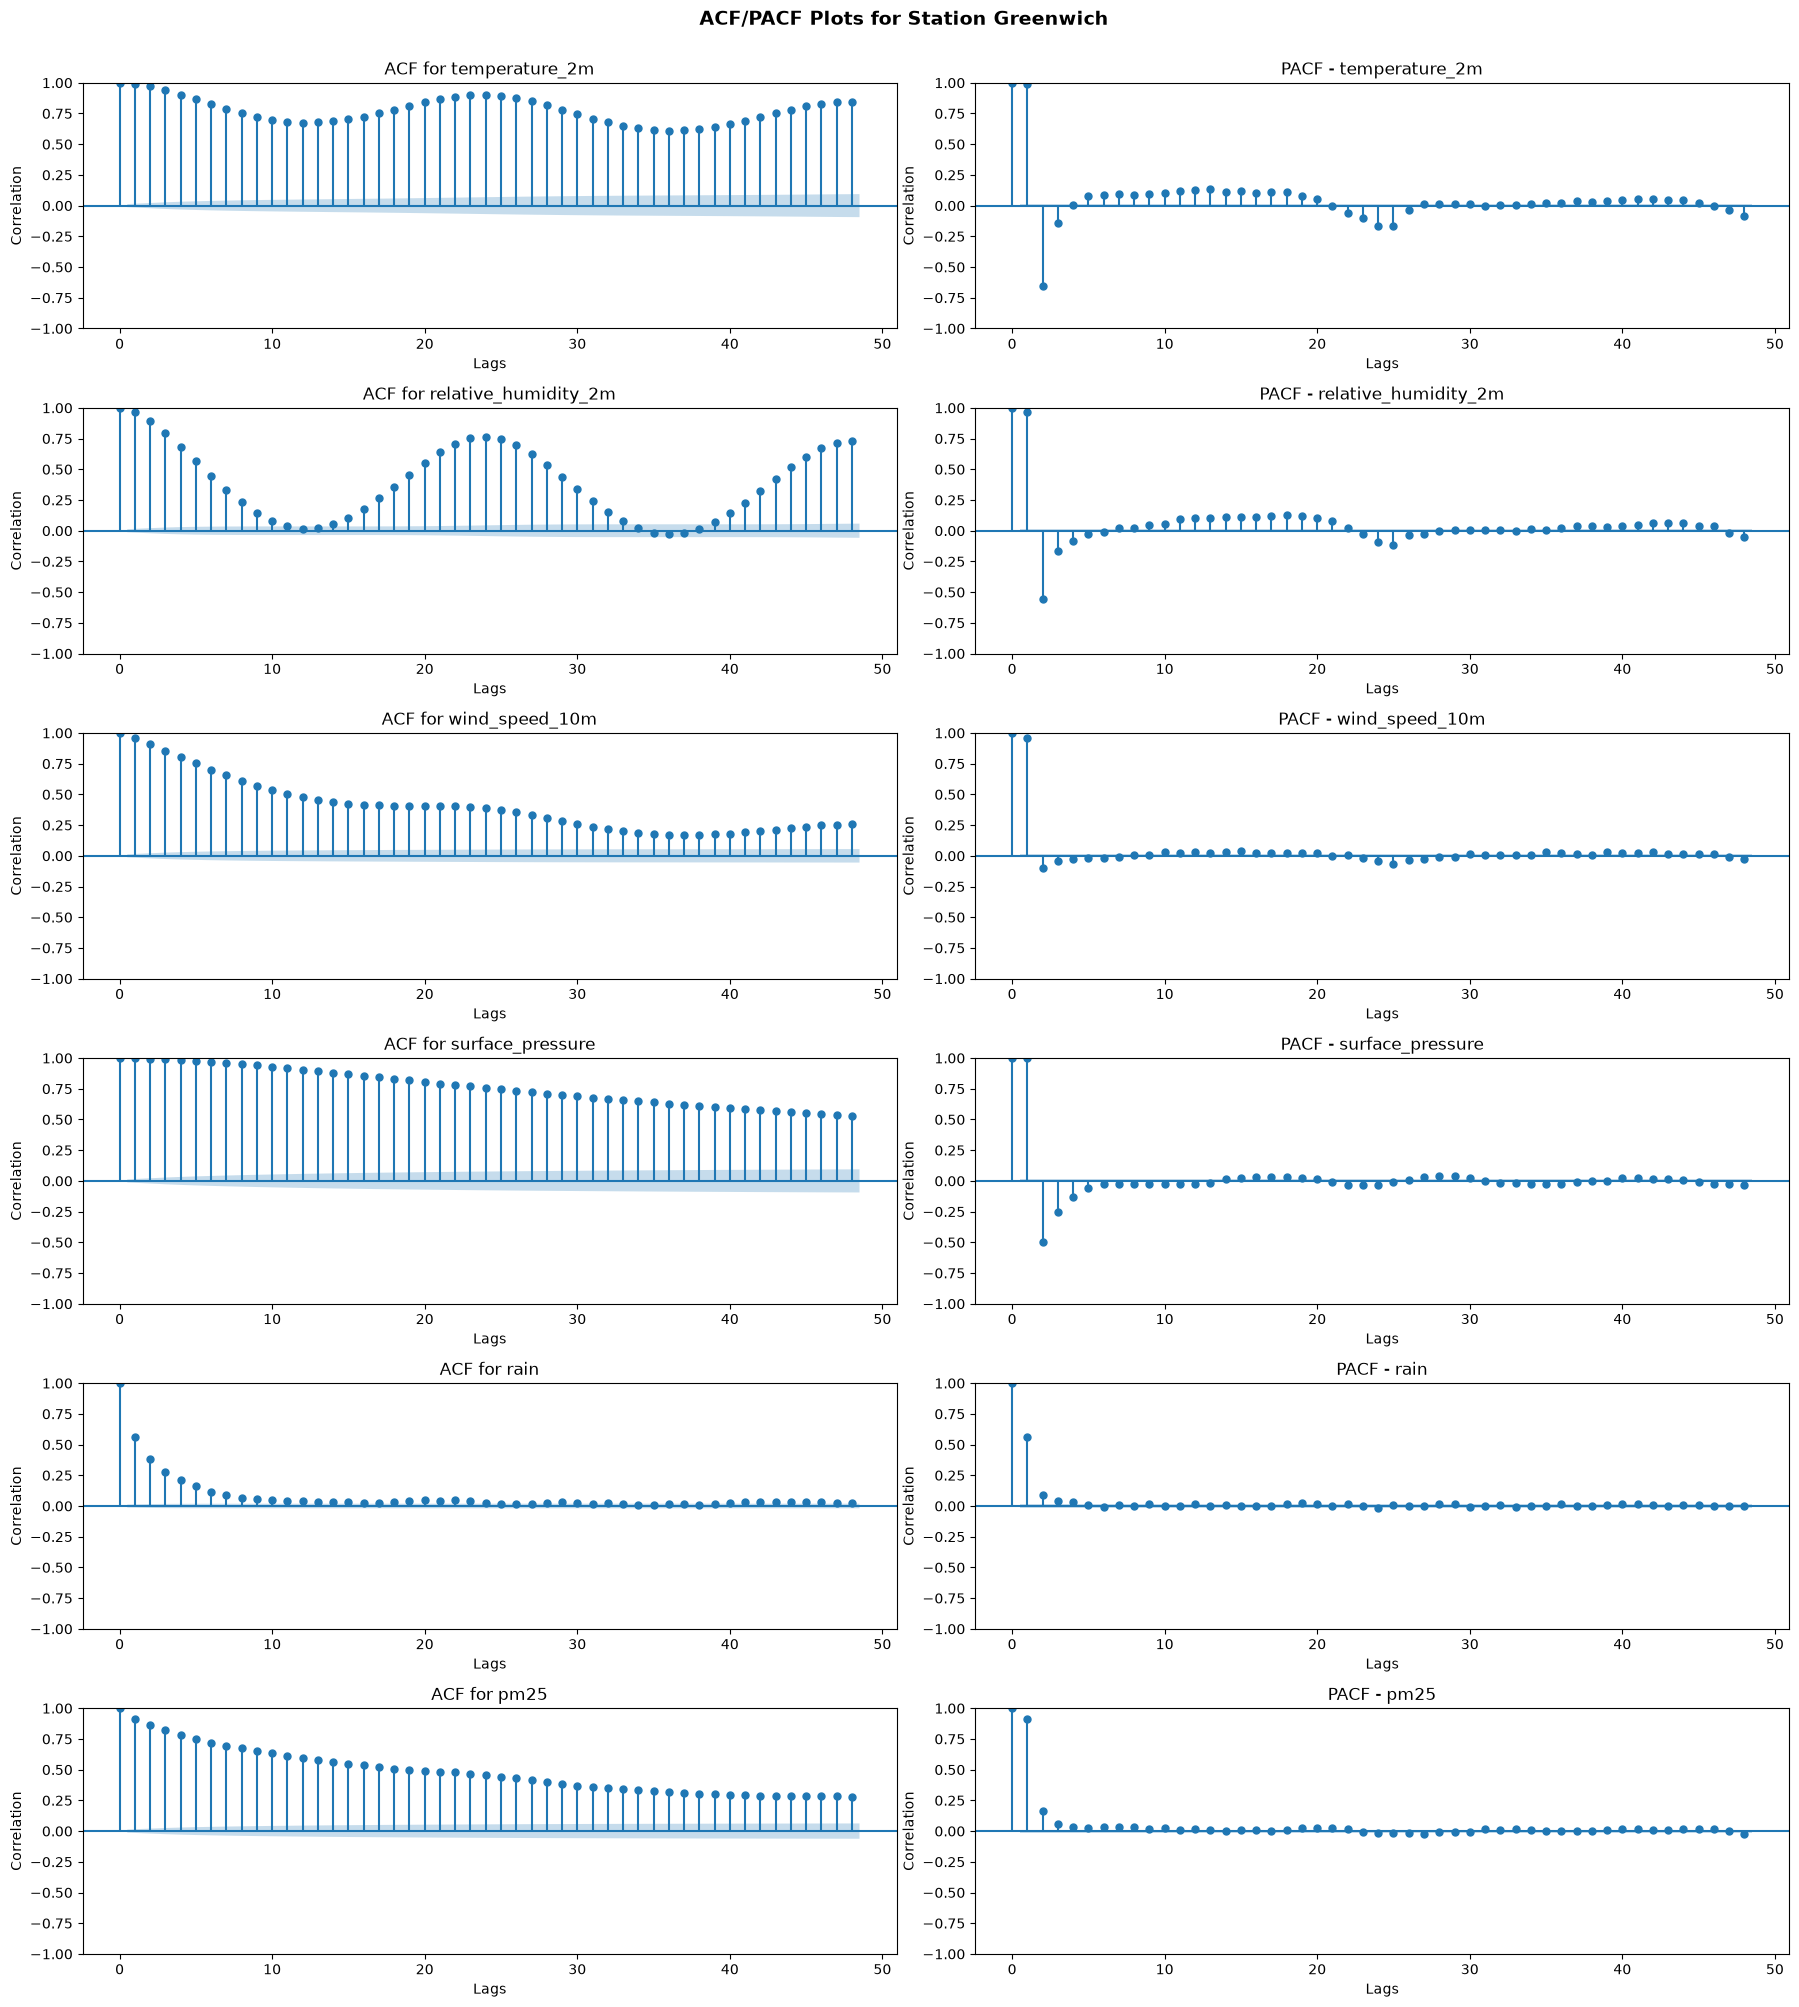

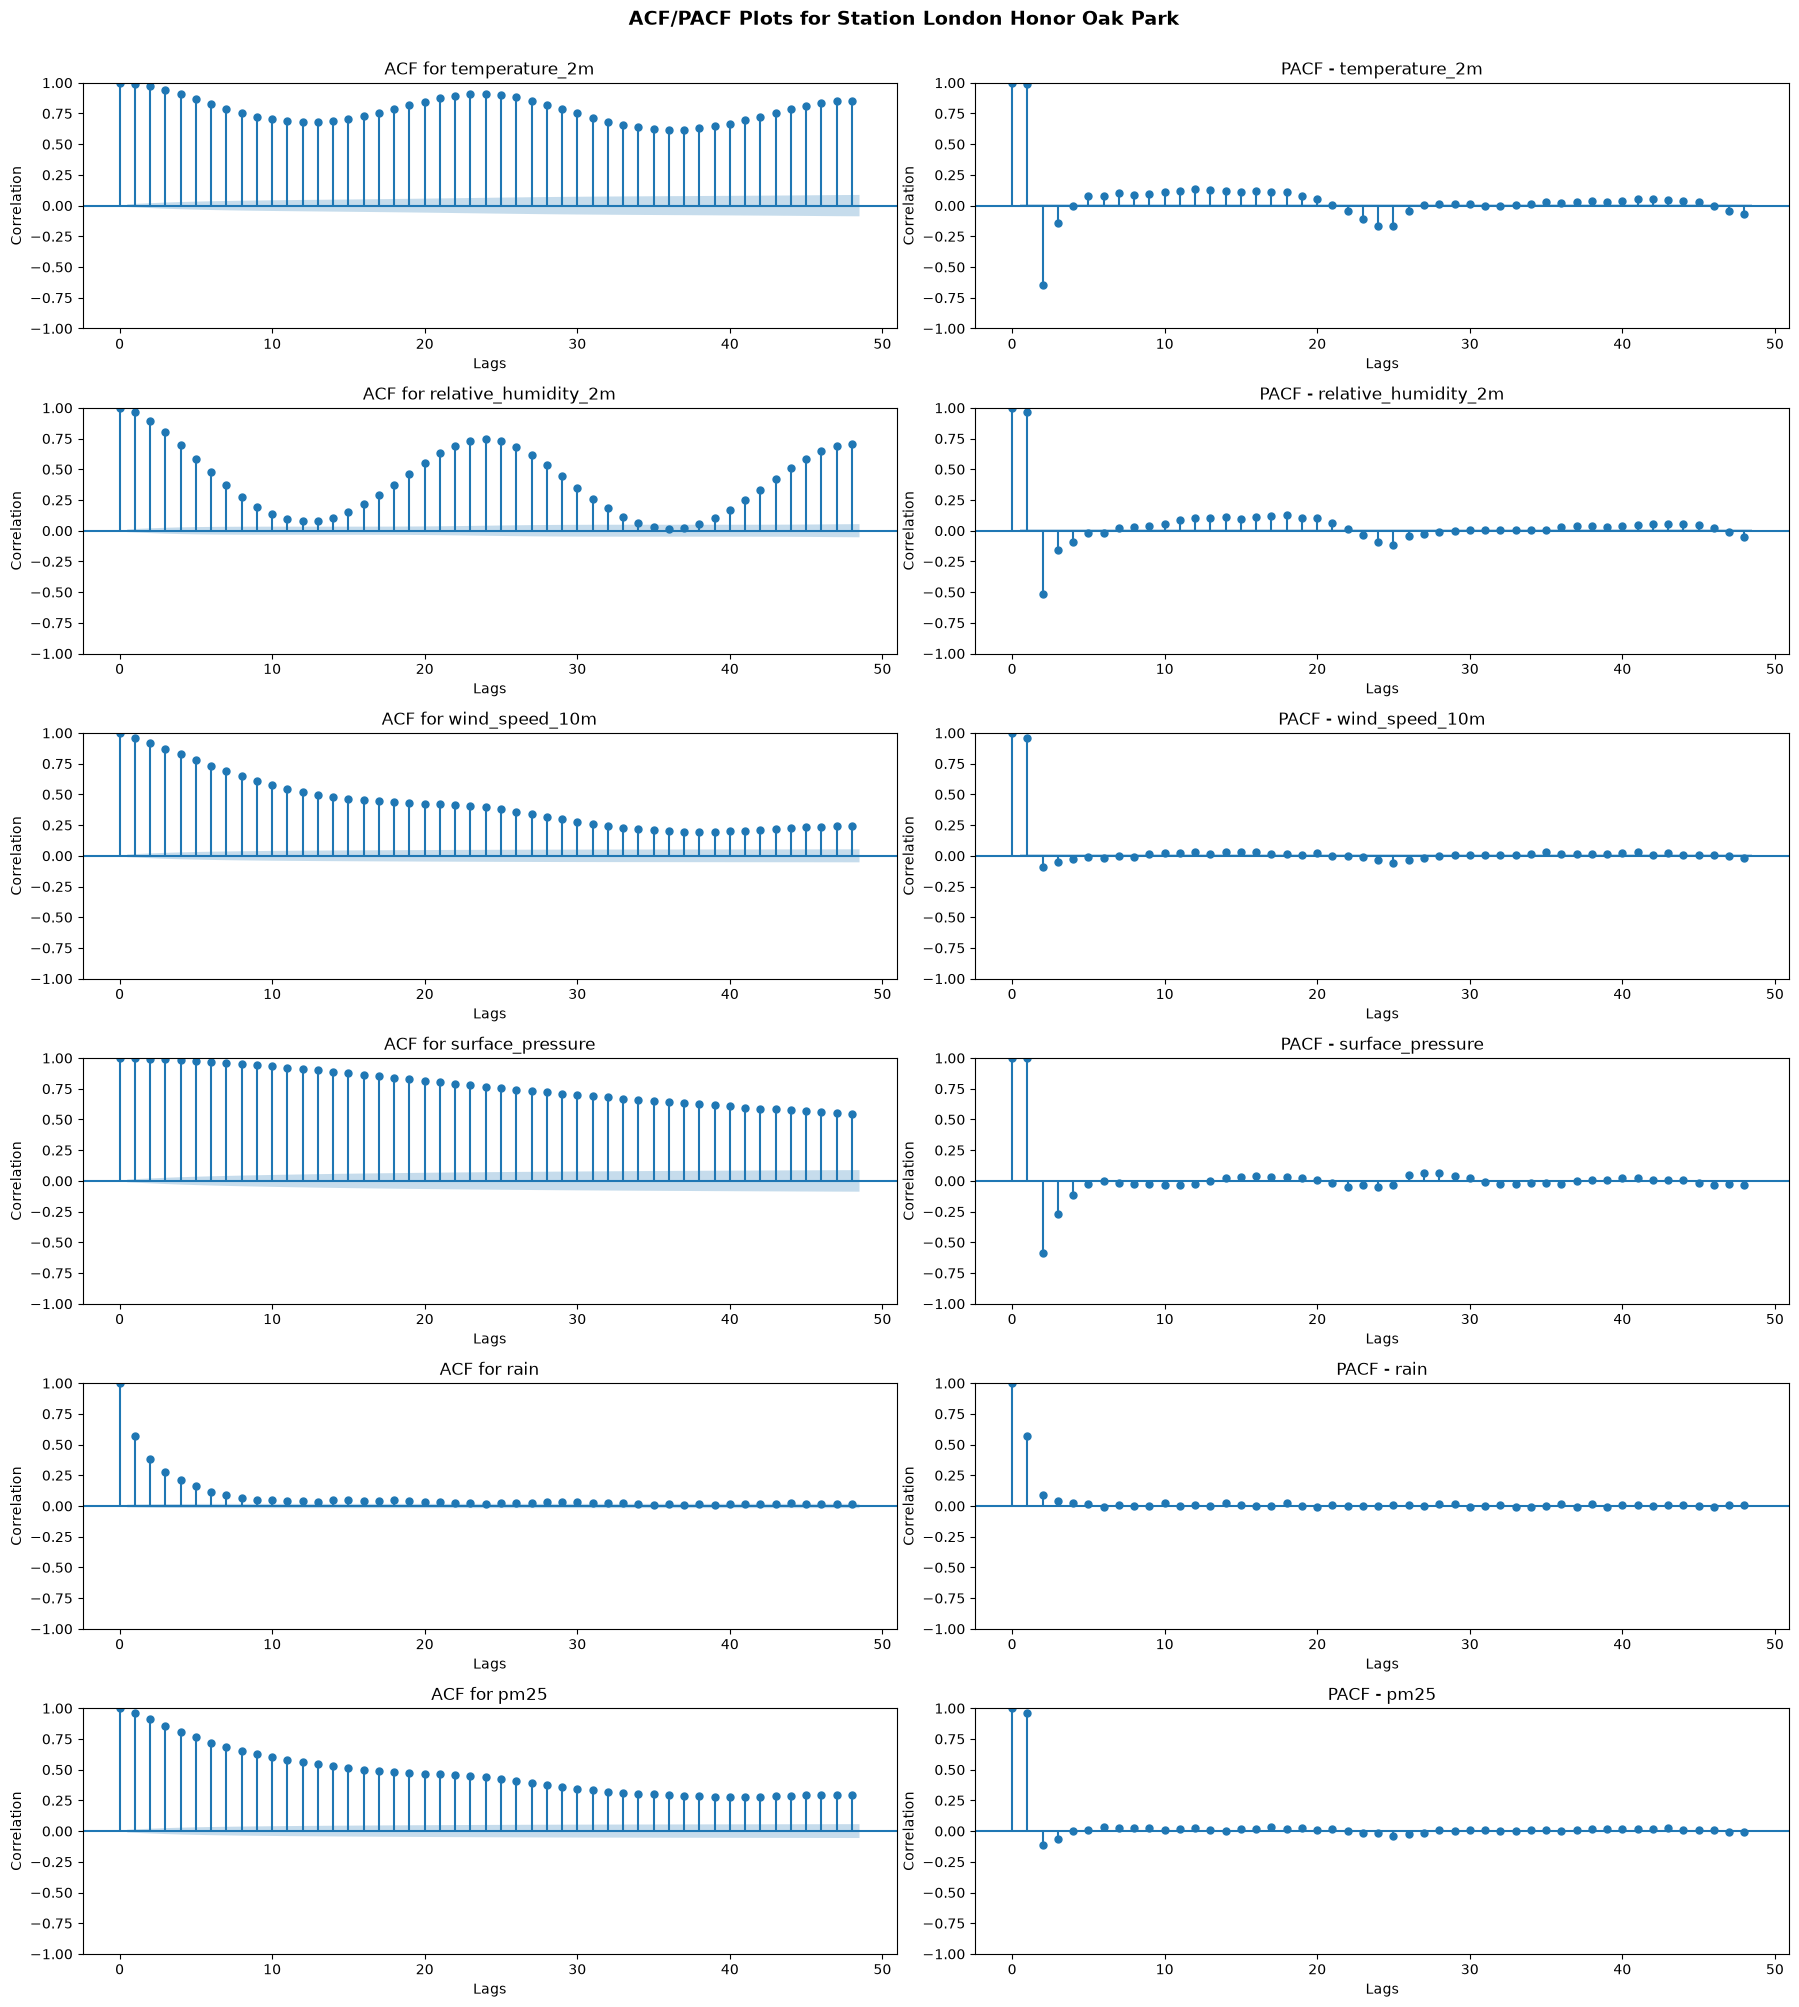

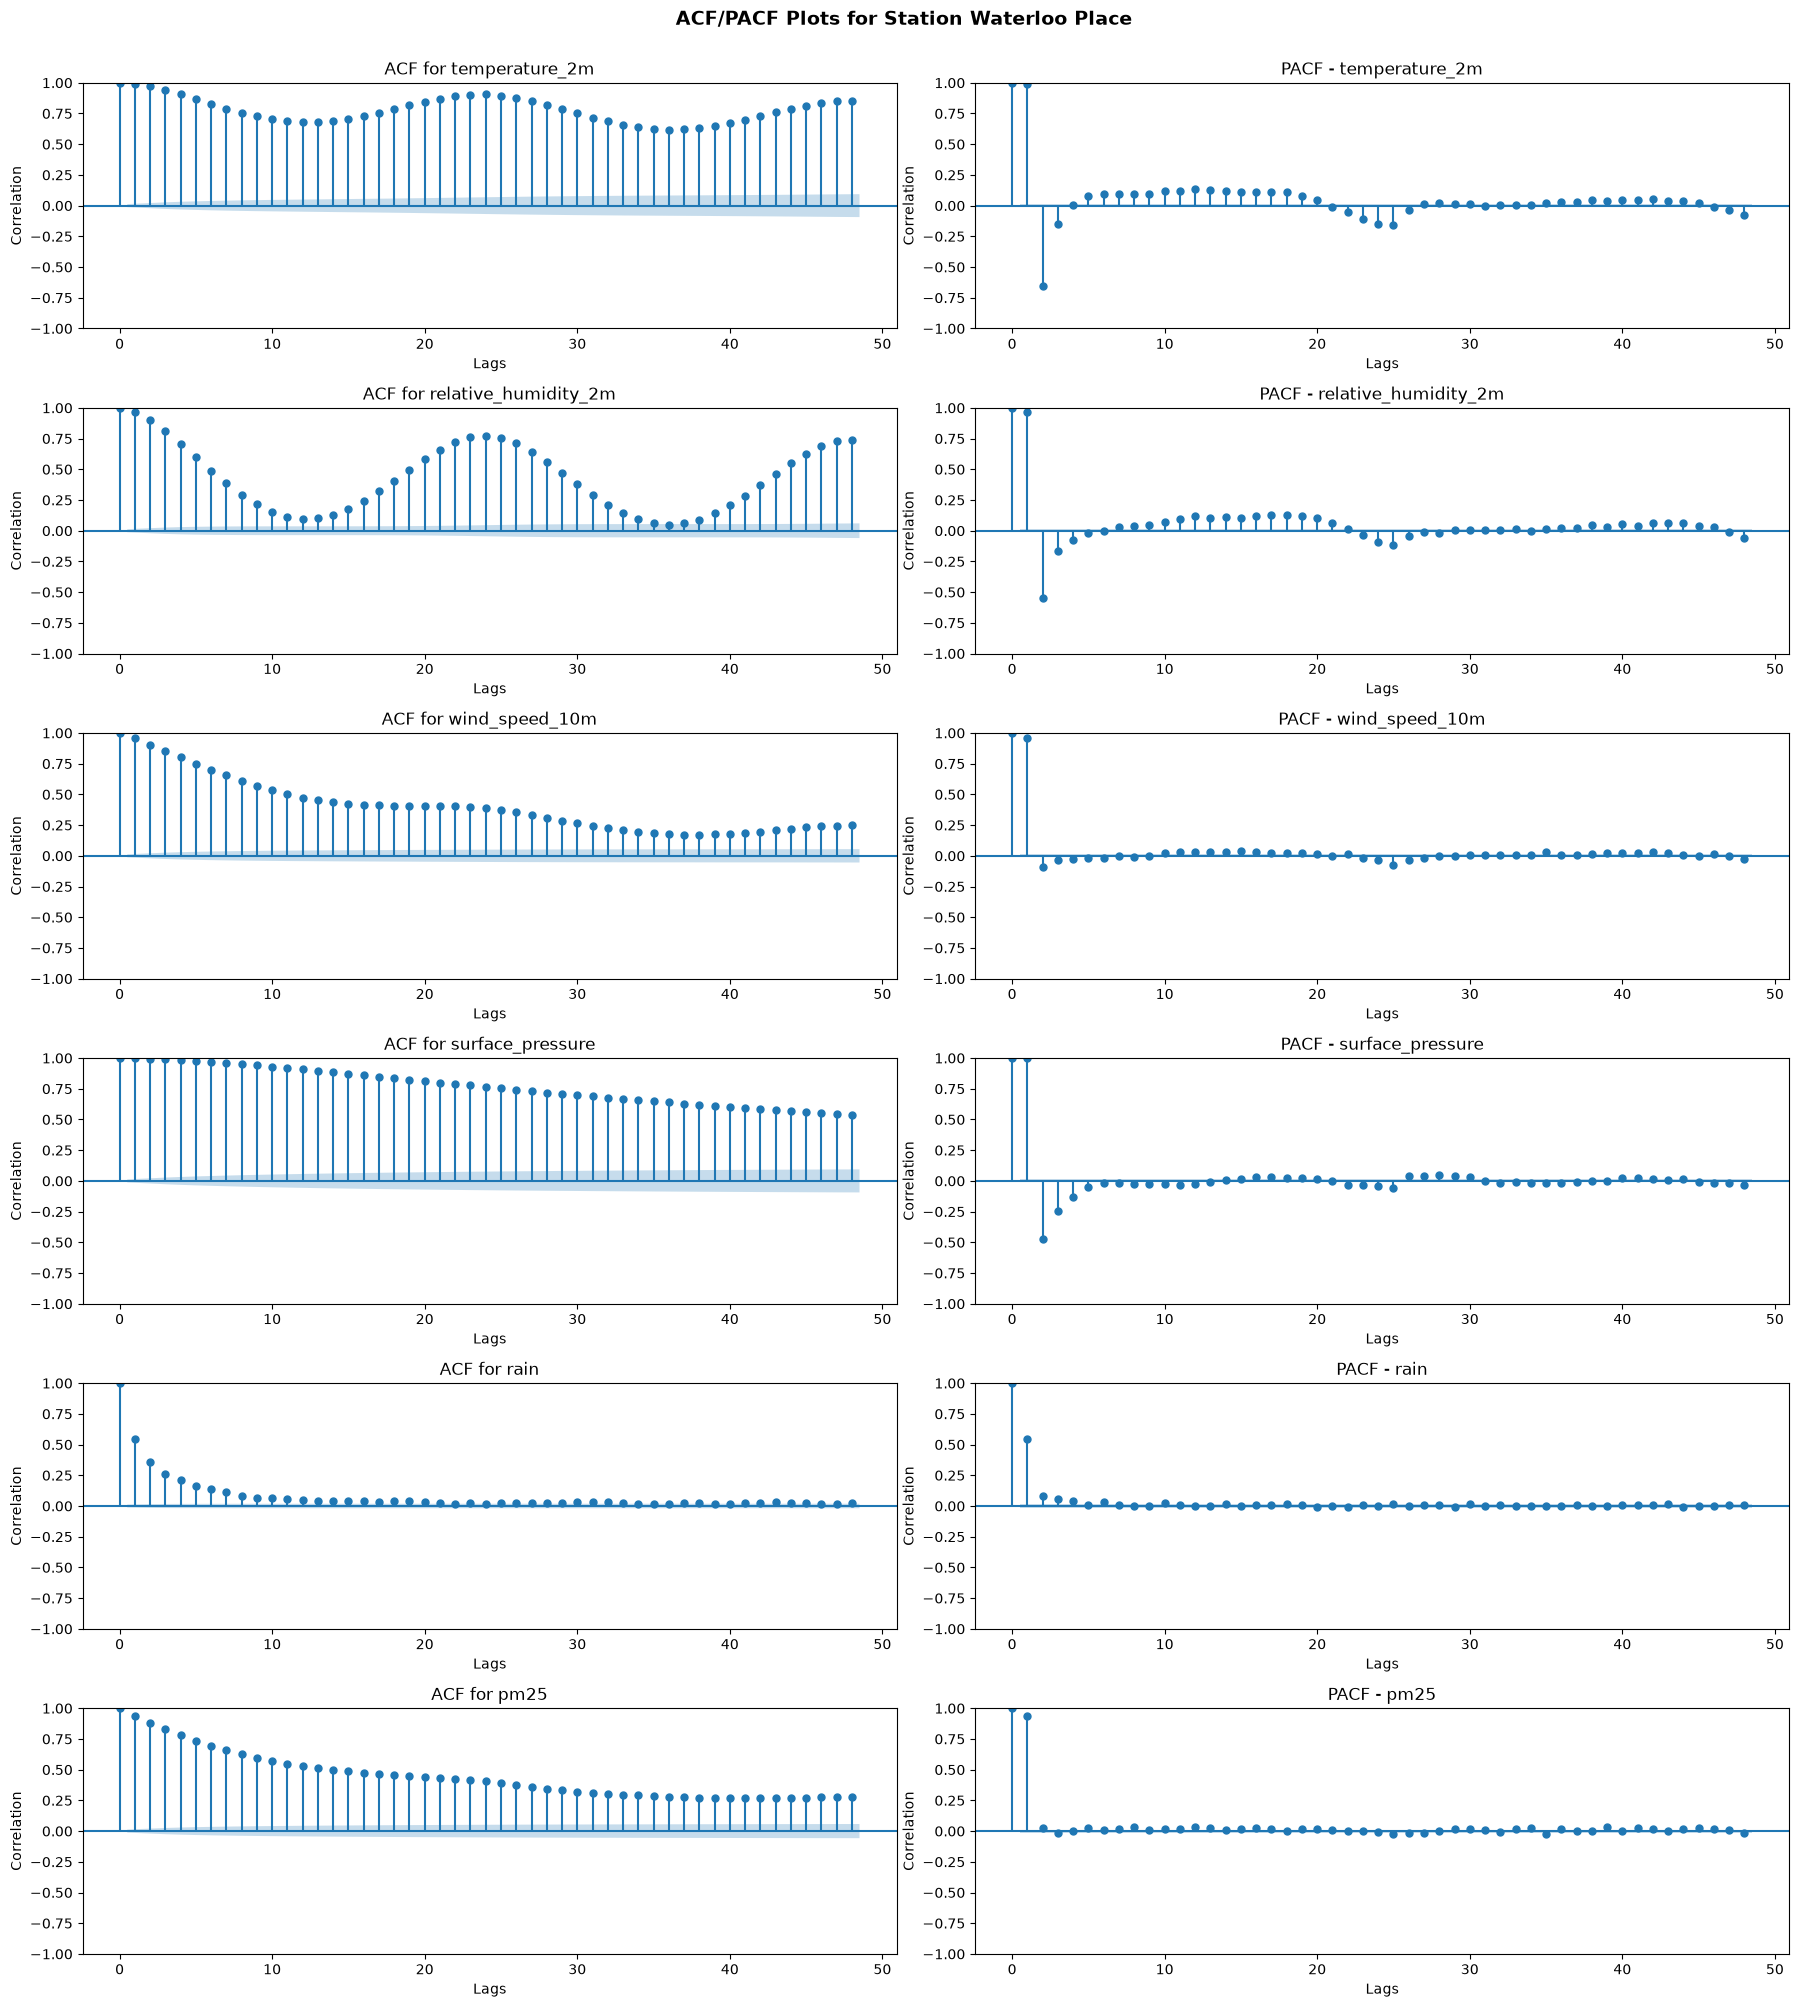

In [25]:
for station in df_prepped['station_name'].unique():
    current = df_prepped[df_prepped['station_name']==station]

    fig, ax = plt.subplots(nrows=6, ncols=2, figsize=(18, 20))
    ax = ax.flatten()
    i = 0

    for col in current.select_dtypes(include='number').columns:
        if col in ['longitude', 'latitude', 'station_id', 'sensor_id']:
            continue

        plot_acf(current[col], ax=ax[i], lags=48, title=f'ACF for {col}')
        ax[i].set_xlabel('Lags')
        ax[i].set_ylabel('Correlation')
        i+=1
        plot_pacf(current[col], lags=48, ax=ax[i], title=f'PACF - {col}')
        ax[i].set_xlabel('Lags')
        ax[i].set_ylabel('Correlation')
        i+=1

    plt.suptitle(f'ACF/PACF Plots for Station {station}', fontsize=14, fontweight='bold', y=1.001)
    plt.tight_layout()
    plt.show()
    plt.close(fig)
print(' ')

### 4.3. Creating Lagged & Rolling Average Features
---

In [26]:
np.sin((2*np.pi*24)/24)

np.float64(-2.4492935982947064e-16)

In [27]:
lags_and_movingavg = {
    'temperature_2m': {
        'lags': [1, 2],
        'rolling_avg': [11, 24]
    },
    'relative_humidity_2m': {
        'lags': [1, 2],
        'rolling_avg': [9, 24]
    },
    'wind_speed_10m': {
        'lags': [1],
        'rolling_avg': [24]
    },
    'surface_pressure': {
        'lags': [1, 2],
        'rolling_avg': [24]
    },
    'rain': {
        'lags': [1],
        'rolling_avg': [5]
    },
    'pm25': {
        'lags': [1],
        'rolling_avg': [24]
    }
}

df_prepped_lagged = df_prepped.copy()
list_df = []

for station in df_prepped_lagged['station_name'].unique():
    current = df_prepped[df_prepped['station_name']==station]

    for col in lags_and_movingavg:
        lags = lags_and_movingavg[col]['lags']
        rolling_avg = lags_and_movingavg[col]['rolling_avg']

        for lag in lags:
            current[f'{col}_lag{lag}'] = current[col].shift(lag)
        for deg in rolling_avg:
            current[f'{col}_rolling{deg}'] = current[col].rolling(deg).mean()

    current['hour_sin'] = np.sin((2*np.pi*current['time_reading'].dt.hour)/24)
    current['hour_cos'] = np.cos((2*np.pi*current['time_reading'].dt.hour)/24)
    current.dropna(inplace=True)
    list_df.append(current)

df_prepped_lagged = pd.concat(list_df, ignore_index=True)
df_prepped_lstm = df_prepped_lagged[[col for col in df_prepped_lagged.columns if 'lag' not in col]]
df_prepped_lstm

,weather_id,sensor_id,station_id,station_name,time_reading,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,rain,...,temperature_2m_rolling11,temperature_2m_rolling24,relative_humidity_2m_rolling9,relative_humidity_2m_rolling24,wind_speed_10m_rolling24,surface_pressure_rolling24,rain_rolling5,pm25_rolling24,hour_sin,hour_cos
0,W235_2023010123,235.0,1,Camden Kerbside,2023-01-01 23:00:00,8.6,94.0,6.6,1001.0,0.7,...,9.972727,10.250000,89.333333,83.666667,22.054167,1000.216667,0.54,8.291667,-0.258819,9.659258e-01
1,W235_2023010200,235.0,1,Camden Kerbside,2023-01-02 00:00:00,8.4,95.0,7.4,1001.1,0.4,...,9.709091,10.104167,90.666667,83.833333,20.945833,1000.462500,0.48,8.333333,0.000000,1.000000e+00
2,W235_2023010201,235.0,1,Camden Kerbside,2023-01-02 01:00:00,7.7,92.0,6.4,1001.5,0.1,...,9.372727,9.970833,91.444444,83.833333,20.404167,1000.716667,0.36,8.375000,0.258819,9.659258e-01
3,W235_2023010202,235.0,1,Camden Kerbside,2023-01-02 02:00:00,7.3,93.0,8.4,1001.7,0.0,...,9.045455,9.791667,92.222222,84.041667,19.533333,1000.954167,0.30,8.416667,0.500000,8.660254e-01
4,W235_2023010203,235.0,1,Camden Kerbside,2023-01-02 03:00:00,6.6,94.0,10.5,1002.3,0.0,...,8.690909,9.612500,92.888889,84.541667,18.641667,1001.179167,0.24,8.458333,0.707107,7.071068e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127749,W1561901_2026072617,1561901.0,4,Waterloo Place,2026-07-26 17:00:00,25.1,37.0,17.4,1002.7,0.0,...,23.209091,22.187500,48.888889,57.666667,15.520833,1001.783333,0.00,4.954167,-0.965926,-2.588190e-01
127750,W1561901_2026072618,1561901.0,4,Waterloo Place,2026-07-26 18:00:00,24.7,37.0,21.2,1003.3,0.0,...,23.727273,22.045833,44.444444,57.791667,15.600000,1001.833333,0.00,4.720833,-1.000000,-1.836970e-16
127751,W1561901_2026072619,1561901.0,4,Waterloo Place,2026-07-26 19:00:00,23.3,41.0,18.0,1004.2,0.0,...,24.072727,21.937500,41.666667,57.750000,15.620833,1001.904167,0.00,4.541667,-0.965926,2.588190e-01
127752,W1561901_2026072620,1561901.0,4,Waterloo Place,2026-07-26 20:00:00,22.5,43.0,17.7,1004.8,0.0,...,24.245455,21.841667,40.777778,57.708333,15.754167,1002.000000,0.00,4.395833,-0.866025,5.000000e-01


## **5. Data Splitting**
---

### 5.1. For LSTM
---

In [28]:
def get_train_val_test_slice(df_input, station):
    df_temp = df_input[df_input['station_name'] == station].copy()
    time_dt = list(df_temp['time_reading'].unique())
    train_temp = int(len(time_dt)*0.7) # 70% of data goes to train
    val_temp = int(len(time_dt)*0.1) # 10% of data goes to validation, the last 20% goes to test

    train_dt = time_dt[:train_temp]
    val_dt = time_dt[train_temp:(train_temp+val_temp)]
    test_dt = time_dt[(train_temp+val_temp):]

    print(f'Station {station}:\nTrain: {(len(train_dt))}, Val: {len(val_dt)}, Test: {len(test_dt)}')

    train = df_temp.loc[df_temp['time_reading'].isin(train_dt)]
    val = df_temp.loc[df_temp['time_reading'].isin(val_dt)]
    test = df_temp.loc[df_temp['time_reading'].isin(test_dt)]
    return train, val, test

In [29]:
forbid = ['weather_id', 'sensor_id', 'longitude', 'latitude']
#df_prepped = df_prepped[[col for col in df_prepped.columns if col not in forbid]]
df_prepped_lagged_lstm = df_prepped_lstm[[col for col in df_prepped_lstm.columns if col not in forbid]]

In [30]:
stations = df_prepped_lagged_lstm['station_name'].unique() # df_prepped
list_train = []
list_val = []
list_test = []
for station in stations:
    train, val, test = get_train_val_test_slice(df_prepped_lagged_lstm, station) # df_prepped
    train=train.drop(columns=['time_reading', 'station_name'])
    val=val.drop(columns=['time_reading', 'station_name'])
    test=test.drop(columns=['time_reading', 'station_name'])

    list_train.append(train)
    list_val.append(val)
    list_test.append(test)

train_lstm = pd.concat(list_train, axis=0, ignore_index=True)
val_lstm = pd.concat(list_val, axis=0, ignore_index=True)
test_lstm = pd.concat(list_test, axis=0, ignore_index=True)

Station Camden Kerbside:
Train: 15992, Val: 2284, Test: 4571
Station Brent:
Train: 17113, Val: 2444, Test: 4891
Station Greenwich:
Train: 17637, Val: 2519, Test: 5041
Station London Honor Oak Park:
Train: 20663, Val: 2951, Test: 5905
Station Waterloo Place:
Train: 18020, Val: 2574, Test: 5149


In [31]:
x_cols_cat = ['station_id']
x_cols_num = [col for col in train.columns if col not in x_cols_cat]
y_col = ['pm25']
print(f'Independent variables: {x_cols_num} + {x_cols_cat}\nTarget variable: {y_col}')

Independent variables: ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'surface_pressure', 'rain', 'pm25', 'temperature_2m_rolling11', 'temperature_2m_rolling24', 'relative_humidity_2m_rolling9', 'relative_humidity_2m_rolling24', 'wind_speed_10m_rolling24', 'surface_pressure_rolling24', 'rain_rolling5', 'pm25_rolling24', 'hour_sin', 'hour_cos'] + ['station_id']
Target variable: ['pm25']


### 5.2. For TFT
---

In [32]:
stations = df_prepped_lagged['station_name'].unique() # df_prepped
list_train = []
list_val = []
list_test = []
for station in stations:
    train_, val_, test_ = get_train_val_test_slice(df_prepped_lagged, station) 
    for data in [train_, val_, test_]:
        data['time_idx'] = np.tile(np.arange(len(data)), 1)

    train_=train_.drop(columns=['time_reading', 'station_name', 'longitude', 'latitude', 'weather_id', 'sensor_id'])
    val_=val_.drop(columns=['time_reading', 'station_name', 'longitude', 'latitude', 'weather_id', 'sensor_id'])
    test_=test_.drop(columns=['time_reading', 'station_name', 'longitude', 'latitude', 'weather_id', 'sensor_id'])

    list_train.append(train_)
    list_val.append(val_)
    list_test.append(test_)

train_tft = pd.concat(list_train, axis=0, ignore_index=True)
cols = [col for col in train_tft.columns if col != 'time_idx']
train_tft = train_tft[['time_idx'] + cols].copy()

val_tft = pd.concat(list_val, axis=0, ignore_index=True)[['time_idx'] + cols].copy()
val_tft = val_tft[['time_idx'] + cols].copy()

test_tft = pd.concat(list_test, axis=0, ignore_index=True)[['time_idx'] + cols].copy()
test_tft = test_tft[['time_idx'] + cols].copy()

Station Camden Kerbside:
Train: 15992, Val: 2284, Test: 4571
Station Brent:
Train: 17113, Val: 2444, Test: 4891
Station Greenwich:
Train: 17637, Val: 2519, Test: 5041
Station London Honor Oak Park:
Train: 20663, Val: 2951, Test: 5905
Station Waterloo Place:
Train: 18020, Val: 2574, Test: 5149


## **6. Data Scaling**
---

In [33]:
def fit_scalers(data_input):
    scalers_dict = {}
    forbid = ['station_id', 'hour_sin', 'hour_cos']
    cols = [col for col in data_input.select_dtypes(include='number').columns if col not in forbid]

    for station in data_input['station_id'].unique():
        scalers_dict[int(station)] = {}
        data_temp = data_input[data_input['station_id']==station]
        #display(data_temp)
        for col in cols:
            scaler = MinMaxScaler(feature_range=(0, 1))
            scaler.fit(data_temp[col].values.reshape(-1, 1))
            scalers_dict[station][col] = scaler
    
    return scalers_dict, cols

def scale_dataframe(data_input, scalers, cols):
    data_input = data_input.copy()
    results = []

    for station in data_input['station_id'].unique():
        data_temp = data_input[data_input['station_id']==station]
        for col in cols:
            scaler = scalers[station][col]
            data_temp[col] = scaler.transform(data_temp[col].values.reshape(-1, 1))
        results.append(data_temp)

    df_result = pd.concat(results, axis=0, ignore_index=True)
    return df_result

In [34]:
scalers_dict, cols_scaled = fit_scalers(df_prepped_lagged_lstm) # df_prepped

train_scaled_lstm = scale_dataframe(train_lstm, scalers_dict, cols_scaled)
val_scaled_lstm = scale_dataframe(val_lstm, scalers_dict, cols_scaled)
test_scaled_lstm = scale_dataframe(test_lstm, scalers_dict, cols_scaled)

In [35]:
functions_path = os.path.join(os.getcwd(), os.path.abspath('functions/scalers_v4'))
if not os.path.exists(functions_path):
    os.makedirs(functions_path)

for station, scalers in scalers_dict.items():
    path_station = os.path.join(functions_path, str(station))
    if not os.path.exists(path_station):
        os.makedirs(path_station)
    
    for col, scaler in scalers.items():
        joblib.dump(scaler, os.path.join(path_station, f'{col}_scaler.joblib'))

In [36]:
len(train_scaled_lstm)

89425

# **Modelling**
---
---

## **1. LSTM Baseline**
---

### 1.1. Function Definition
---

In [109]:
# Class for Generating Window Sizes
class time_series_dataset(Dataset):
    def __init__(self, df_input, cols_ind_num: list, cols_ind_cat: list, cols_target: list, window_size: int=10, horizon_size: int=6):
        self.window_size = window_size # setting window size, which is x rows used to predict an nth PM 2.5 readings
        self.predictor_num=cols_ind_num # the numerical, scaled time-series input
        self.predictor_cat=cols_ind_cat # the categorical encoded feature
        self.target=cols_target # target feature
        self.horizon_size = horizon_size # horizon size

        self.groups = []
        # This loop loops through all station id and horizon combinations, getting the dataframe for each combination and placing it 
        # into the self.groups list to ensure that each batch's windows only consists of one station id
        for _, temp in df_input.groupby(by=['station_id'], sort=False):
            group = temp.reset_index(drop=True)
            if len(group)>=(window_size+horizon_size): # takes into account the horizon size
                self.groups.append(group)

        self.idx_map = []
        # This loop creates an index map, where each item contains a dataframe (each having unique combination of station id and horizon)
        # and in every loop iteration, it creates a tuple consisting of the dataframe's index inside the self.groups list and the index
        # for each record of the dataframe
        for i, item in enumerate(self.groups):
            n_valid = len(item)-window_size-horizon_size+1
            for local_idx in range(n_valid): # loops through every valid index of the dataframe
                self.idx_map.append((i, local_idx))
    
    def __len__(self):
        return len(self.idx_map)

    def __getitem__(self, idx: int):
        id_group, id_df = self.idx_map[idx]
        curr_df = self.groups[id_group]

        # This function extracts the n-th and the next 10 rows of the dataframe as well as the next record after said 10
        # rows (as the target). This is done for every batch (which is set in the proceeding cell, explained further below)
        predictors_num = curr_df[self.predictor_num][id_df:id_df + self.window_size].values.reshape(-1, len(self.predictor_num)).copy()
        predictors_cat = curr_df[self.predictor_cat][id_df:id_df + self.window_size].values.reshape(-1, len(self.predictor_cat)).copy()
        target = curr_df[self.target][id_df + self.window_size:id_df + self.window_size + self.horizon_size].values.reshape(-1, 1).copy()

        return {
            'numerical_inputs': torch.FloatTensor(predictors_num), # numerical inputs converted to torch tensor (essentially numpy ndarray but for deep learning)
            'categorical_inputs': torch.tensor(predictors_cat, dtype=torch.int64), # categorical, encoded inputs
            'target': torch.FloatTensor(target) # target feature
        }

# function for Streaming Inputs Into the Model
def generator_inputs_target(df_input, cols_ind_num: list, cols_ind_cat: list, cols_target: list , shuffle:bool=True, window_size: int=10, batch_size: int=32, horizon_size: int=6):
    # The seed_worker function below is used to set a seed for each worker involved in shuffling and streaming the data
    def seed_worker(worker_id):
        worker_seed = torch.initial_seed() % 2**batch_size
        np.random.seed(worker_seed)
        random.seed(worker_seed)

    g_func = torch.Generator() # sets the seed for the torch library's data processing
    g_func.manual_seed(SEED)

    data = time_series_dataset(df_input, cols_ind_num, cols_ind_cat, cols_target, window_size=window_size, horizon_size=horizon_size) # creates the dataframe object
    loader = DataLoader(            # The dataloader here does the shuffling and batching for the time series dataset. If batch is set to 32,
        data,                       # and when the window is set to say 10, each batch will have 32 sets of arrays (each array has 10 records)
        batch_size=batch_size,      # which is fed into the deep learning model to train said model to learn the patterns of those ten steps
        shuffle=shuffle,            # make prediction on the target
        pin_memory=False,
        #num_workers=6,
        worker_init_fn=seed_worker, # utilizing the worker function to set the seed
        drop_last=True, # drops the last batch, since it likely does not have the same size
        generator=g_func # utilizing the generator function to set the seed
    )

    for input_ in loader:
        # This loop streams the outputs from dataloader, extracting the categorical and numerical features, as well as the target feature, and 
        # would stream each batch (when created) into the deep learning model later (in a format compatible with tensorflow which is as numpy
        # multi-dimension array)
        features = {
            'numerical_inputs': input_['numerical_inputs'].detach().numpy(), 
            'categorical_inputs': input_['categorical_inputs'].detach().numpy()
        }
        target = input_['target'].detach().numpy()#.squeeze(axis=0)
        yield features, target

### 1.2. Input/Output Set Up
---

In [110]:
window_size = 20 # lower windows seem to do worse
batch_size = 128
horizon=6

# horizon=6

output_signature = (
    {
        'numerical_inputs': tf.TensorSpec(shape=(batch_size, window_size, len(x_cols_num)), dtype=tf.float32),
        'categorical_inputs': tf.TensorSpec(shape=(batch_size, window_size, len(x_cols_cat)), dtype=tf.int32)
    },
    tf.TensorSpec(shape=(batch_size, horizon, 1), dtype=tf.float32)
)

train_stream = tf.data.Dataset.from_generator(
    generator=lambda: generator_inputs_target(train_scaled_lstm, cols_ind_num=x_cols_num, cols_ind_cat=x_cols_cat, cols_target=y_col, window_size=window_size, batch_size=batch_size),
    output_signature=output_signature
)

val_stream = tf.data.Dataset.from_generator(
    generator=lambda: generator_inputs_target(val_scaled_lstm, shuffle=False, cols_ind_num=x_cols_num, cols_ind_cat=x_cols_cat, cols_target=y_col, window_size=window_size, batch_size=batch_size),
    output_signature=output_signature
)

test_stream = tf.data.Dataset.from_generator(
    generator=lambda: generator_inputs_target(test_scaled_lstm, shuffle=False, cols_ind_num=x_cols_num, cols_ind_cat=x_cols_cat, cols_target=y_col, window_size=window_size, batch_size=batch_size),
    output_signature=output_signature
)

train_dataset = train_stream.repeat().prefetch(buffer_size=tf.data.AUTOTUNE)
val_dataset = val_stream.prefetch(buffer_size=tf.data.AUTOTUNE)
test_dataset = test_stream.prefetch(buffer_size=tf.data.AUTOTUNE)

### 1.3. Model Architecture and Training
---

In [111]:
models_dir = os.path.join(os.getcwd(), 'models/models_lstm_laggedfeatures_v3')
if not os.path.exists(models_dir):
    os.makedirs(models_dir)

best_checkpoint_path = os.path.join(models_dir, 'lstm_best.keras')
path_logs_training = os.path.join(models_dir, 'training_logs_lstm.csv')
path_per_epoch_log = os.path.join(models_dir, 'model_backup')
if not os.path.exists(path_per_epoch_log):
    os.makedirs(path_per_epoch_log)

# Checkpoint Callbacks
csv_logging = tf.keras.callbacks.CSVLogger(
    filename=path_logs_training, append=True
)
per_epoch_log = tf.keras.callbacks.BackupAndRestore(
    backup_dir=path_per_epoch_log, save_freq='epoch', delete_checkpoint=True
)
best_cp_log = tf.keras.callbacks.ModelCheckpoint(
    filepath=best_checkpoint_path, monitor='val_loss', verbose=1, save_best_only=True, save_weights_only=False, save_freq='epoch'
)

# Training Callbacks
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8, verbose=1, min_delta=1e-4, restore_best_weights=True
) # try to increase to 10 for sgd
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', patience=4, verbose=1, min_lr=1e-6, min_delta=1e-4, factor=0.4
)# switch to 4

In [112]:
# Numerical input layer
num_input = tf.keras.Input(shape=(window_size, len(x_cols_num)), name='numerical_inputs')

# Categorical input layer 
cat_input = tf.keras.Input(shape=(window_size, len(x_cols_cat)), name='categorical_inputs')

# Station id layer
station_scalar = tf.keras.layers.Lambda(lambda x: x[:, 0, 0])(cat_input)
station_layer = tf.keras.layers.Flatten()(tf.keras.layers.Embedding(input_dim=6, output_dim=4)(station_scalar)) 
# note: only use reshape to flatten the array of values and preserve sequential pattern (Flatten is used when preserving such patterns is not needed)

# Numerical layer
layer_model = tf.keras.layers.Conv1D(filters=64, kernel_size=3, padding='same', activation='swish', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(num_input) # used to capture pattern from sequential data
layer_model = tf.keras.layers.LSTM(128, dropout=0.3, recurrent_dropout=0.2, return_sequences=True)(layer_model)
layer_model = tf.keras.layers.MultiHeadAttention(num_heads=2, key_dim=32)(layer_model, layer_model)
dense_att = tf.keras.layers.Dense(32, activation='swish', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(layer_model)
dense_att = tf.keras.layers.Dense(128)(dense_att)
layer_model = tf.keras.layers.Add()([layer_model, dense_att])
layer_model = tf.keras.layers.LayerNormalization()(layer_model) # normalizes values returned by the Dense layer
layer_model = tf.keras.layers.GlobalMaxPooling1D()(layer_model)

# Output layers
combined_output = tf.keras.layers.Concatenate(axis=-1)([layer_model, station_layer])
layer_out = tf.keras.layers.Dense(32, activation='swish')(combined_output)
layer_out = tf.keras.layers.Dropout(0.3)(layer_out)
model_out = tf.keras.layers.Dense(6)(layer_out)

model = tf.keras.models.Model(inputs=[num_input, cat_input], outputs=model_out)

lr = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=0.001, first_decay_steps=16732, t_mul=2.0, m_mul=0.9, alpha=1e-6
)
model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-3), loss='mae', metrics=[tf.keras.metrics.RootMeanSquaredError(), tf.keras.metrics.MeanSquaredError()]) # compiling & setting model metrics

In [115]:
def get_steps_compute(data_obj, batch_size):
    return len(data_obj) // batch_size

train_obj = time_series_dataset(train_scaled_lstm, x_cols_num, x_cols_cat, y_col, window_size)
val_obj = time_series_dataset(val_scaled_lstm, x_cols_num, x_cols_cat, y_col, window_size)
test_obj = time_series_dataset(test_scaled_lstm, x_cols_num, x_cols_cat, y_col, window_size)

steps_train = get_steps_compute(train_obj, batch_size)
steps_val = get_steps_compute(val_obj, batch_size)
steps_test = get_steps_compute(test_obj, batch_size)
print(f'Length of train steps: {steps_train}\nLength of validation steps: {steps_val}\nLength of test steps: {steps_test}')

Length of train steps: 697
Length of validation steps: 98
Length of test steps: 198


In [116]:
fit = model.fit(
    train_dataset,
    validation_data=val_dataset,
    steps_per_epoch=steps_train,
    validation_steps=steps_val,
    epochs=60,
    callbacks=[csv_logging, per_epoch_log, best_cp_log, early_stop],#, reduce_lr],
    verbose=1,
)

Epoch 1/60


c:\Users\user\works\DE_studies\pm25_forecast\ne_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


697/697 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - loss: 0.0633 - mean_squared_error: 0.0098 - root_mean_squared_error: 0.0989
Epoch 1: val_loss improved from None to 0.03700, saving model to c:\Users\user\works\DE_studies\pm25_forecast\models/models_lstm_laggedfeatures_v3\lstm_best.keras

Epoch 1: finished saving model to c:\Users\user\works\DE_studies\pm25_forecast\models/models_lstm_laggedfeatures_v3\lstm_best.keras
697/697 ━━━━━━━━━━━━━━━━━━━━ 191s 267ms/step - loss: 0.0633 - mean_squared_error: 0.0098 - root_mean_squared_error: 0.0989 - val_loss: 0.0370 - val_mean_squared_error: 0.0019 - val_root_mean_squared_error: 0.0440
Epoch 2/60
697/697 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - loss: 0.0392 - mean_squared_error: 0.0027 - root_mean_squared_error: 0.0523
Epoch 2: val_loss improved from 0.03700 to 0.02659, saving model to c:\Users\user\works\DE_studies\pm25_forecast\models/models_lstm_laggedfeatures_v3\lstm_best.keras

Epoch 2: finished saving model to c:\Users\user\works\DE_studies\pm25_f

### 1.4. Evaluation
---

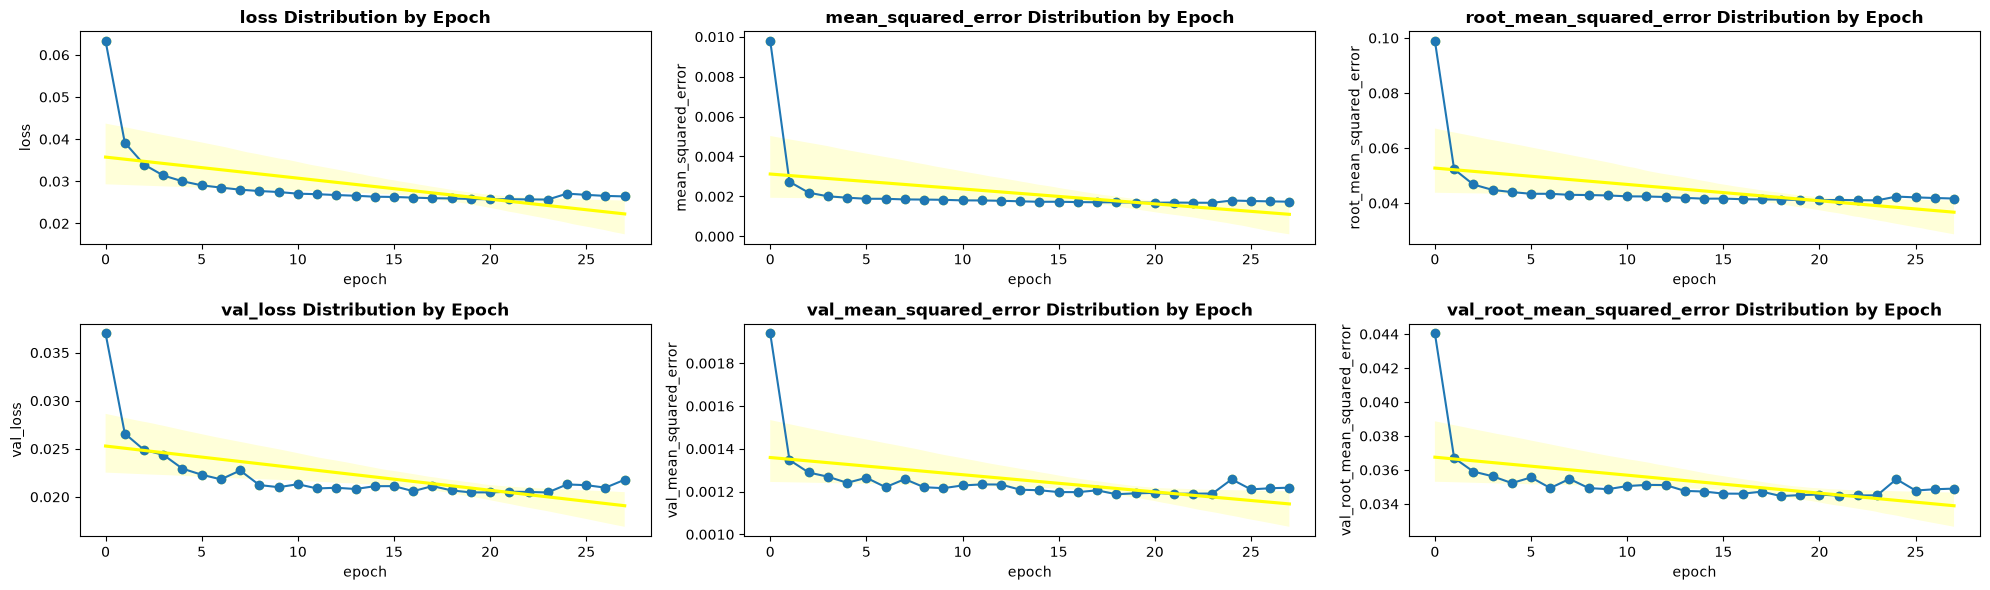

In [117]:
logs = pd.read_csv(path_logs_training)

plt.figure(figsize=(20, 6))
for i, col in enumerate([c for c in logs.columns if c!='epoch']):
    plt.subplot(2, 3, i+1)
    plt.plot(logs['epoch'], logs[col], marker='o')
    sns.regplot(x=logs['epoch'], y=logs[col], color='yellow', order=1)
    plt.title(f'{col} Distribution by Epoch', fontsize=12, fontweight='bold')
    if len(logs)<=20:
        plt.xticks(list(logs['epoch'].values))
plt.tight_layout()
plt.show()

In [108]:
'''# Learning Rate
plt.figure(figsize=(10, 4))
plt.plot(logs['epoch'], fit.history['learning_rate'], marker='o')
plt.title('Learning Rate', fontsize=12, fontweight='bold')
plt.show()'''

"# Learning Rate\nplt.figure(figsize=(10, 4))\nplt.plot(logs['epoch'], fit.history['learning_rate'], marker='o')\nplt.title('Learning Rate', fontsize=12, fontweight='bold')\nplt.show()"

In [119]:
path = os.path.abspath('./models/models_lstm_laggedfeatures_v3/lstm_best.keras')
model_n = tf.keras.models.load_model(path, safe_mode=False)

In [120]:
list_targets = []
list_preds = []

horizon_res = {}
for i in range(6):
    horizon_res[i+1] = {
        'list_targets': [],
        'list_preds': []
    }

for feature, target in test_dataset:
    target_n = target.numpy()
    cat = feature['categorical_inputs'].numpy()

    pred = model.predict(feature)
    actuals = [val.flatten() for val in target_n]

    for batch in range(len(cat)):
            list_cat = []
            for i in range(len(cat[batch])):
                if list_cat is None or int(cat[batch][i][0]) not in list_cat:
                    list_cat.append(int(cat[batch][i][0]))
            
            #print(f'Batch {batch} - categories: {set(list_cat_h)}')
    
            if len(list_cat)==1:
                scaler = scalers_dict[list_cat[0]]['pm25']
            else:
                print('There is more than 1 station, skipping...\n')
                continue

    for pred, actual in zip(pred, actuals):
        pred = scaler.inverse_transform(pred.reshape(-1, 1)).flatten()
        actual = scaler.inverse_transform(actual.reshape(-1, 1)).flatten()
        for i in range(len(pred)):
             horizon_res[i+1]['list_preds'].append(pred[i])
             horizon_res[i+1]['list_targets'].append(actual[i])
             list_preds.append(pred[i])
             list_targets.append(actual[i])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━

In [121]:
for h in horizon_res.keys():
    target_f = horizon_res[h]['list_targets']
    pred = horizon_res[h]['list_preds']

    print(f'Results at horizon {h}:')
    smape = SymmetricMeanAbsolutePercentageError()
    smape = smape(torch.tensor(target_f), torch.tensor(pred))
    rmse = root_mean_squared_error(target_f, pred)
    mae = mean_absolute_error(target_f, pred)
    mse = mean_squared_error(target_f, pred)
    print(f'RMSE: {rmse}\nMAE: {mae}\nMSE: {mse}\nsMAPE: {smape}\n')

rmse = root_mean_squared_error(list_targets, list_preds)
mae = mean_absolute_error(list_targets, list_preds)
mse = mean_squared_error(list_targets, list_preds)
smape = SymmetricMeanAbsolutePercentageError()
smape = smape(torch.tensor(list_targets), torch.tensor(list_preds))
print(f'Genral results:\nRMSE: {rmse}\nMAE: {mae}\nMSE: {mse}\nsMAPE: {smape}')

Results at horizon 1:
RMSE: 2.594395156357069
MAE: 1.6143511826543506
MSE: 6.730886227329021
sMAPE: 0.20889520645141602

Results at horizon 2:
RMSE: 3.1161006182213864
MAE: 1.9993437891337589
MSE: 9.710083062879706
sMAPE: 0.25103649497032166

Results at horizon 3:
RMSE: 3.534572761929278
MAE: 2.2821553961722962
MSE: 12.493204609372365
sMAPE: 0.2787558138370514

Results at horizon 4:
RMSE: 3.8914185387170144
MAE: 2.5178118431913776
MSE: 15.143138243470462
sMAPE: 0.30130434036254883

Results at horizon 5:
RMSE: 4.18527262976792
MAE: 2.7151201414015946
MSE: 17.516506985484483
sMAPE: 0.3207628130912781

Results at horizon 6:
RMSE: 4.429826901419808
MAE: 2.8690567012356443
MSE: 19.62336637654262
sMAPE: 0.3352760672569275

Genral results:
RMSE: 3.679157183945771
MAE: 2.332973175631504
MSE: 13.536197584179776
sMAPE: 0.2826717793941498


In [122]:
test_results = model_n.evaluate(test_dataset, steps=steps_test)
#print(f"Test result: {test_results}")
#res_target = scalers_dict.inverse_transform(np.array([test_results]).reshape(-1, 1))

res_dict = {
    'mae': float(test_results[0]),
    'mse': float(test_results[1]),
    'rmse': float(test_results[2])
}
res_dict

198/198 ━━━━━━━━━━━━━━━━━━━━ 45s 223ms/step - loss: 0.0258 - mean_squared_error: 0.0016 - root_mean_squared_error: 0.0395


{'mae': 0.02582644857466221,
 'mse': 0.039537567645311356,
 'rmse': 0.001563219353556633}

## **2. TFT (Temporal Fusion Transformer)**
---

### 2.1. Setting Up Inputs
---

In [38]:
window_size = 20 
batch_size = 128
horizon=6
numeric_cols = [col for col in train_tft.columns if col not in ['time_idx', 'station_id', 'pm25', 'hour_sin', 'hour_cos']]

train_tft_torch = TimeSeriesDataSet(
    data=train_tft,
    time_idx='time_idx',
    target='pm25',
    group_ids=['station_id'],

    # Setting lookbacks
    max_encoder_length=window_size,
    min_encoder_length=window_size,

    # Setting horizon
    max_prediction_length=horizon,
    min_prediction_length=horizon,

    # Selecting features
    time_varying_known_reals=['time_idx', 'hour_sin', 'hour_cos'],
    time_varying_unknown_reals=numeric_cols,
    
    # Scaling
    target_normalizer=GroupNormalizer(groups=['station_id'], transformation='log1p'), # selected due to existence of low values
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

path_save_dataset = os.path.join(os.getcwd(), 'functions/dataset_tft')
if not os.path.exists(path_save_dataset):
    os.makedirs(path_save_dataset)
torch.save(train_tft_torch.get_parameters(), os.path.join(path_save_dataset, 'dataset_params.pt'))

val_tft_torch = TimeSeriesDataSet.from_dataset(train_tft_torch, data=val_tft, stop_randomization=True, predict=False)
test_tft_torch = TimeSeriesDataSet.from_dataset(train_tft_torch, data=test_tft, stop_randomization=True, predict=False)

In [39]:
train_loader = train_tft_torch.to_dataloader(train=True, batch_size=batch_size)
test_loader = test_tft_torch.to_dataloader(train=False, batch_size=batch_size)
val_loader = val_tft_torch.to_dataloader(train=False, batch_size=batch_size)

steps_train = len(train_loader)
steps_test = len(test_loader)
steps_val = len(val_loader)

### 2.2. Modelling - Callbacks Setup
---

In [40]:
model_path = os.path.join(os.getcwd(), 'models/models_tft_v5')
if not os.path.exists(model_path):
    os.makedirs(model_path)

# Checkpoints
checkpoint_best = ModelCheckpoint(
    dirpath=model_path,
    filename='tft_best',
    monitor='val_loss',
    mode='min',
    save_top_k=1,
    save_weights_only=False
)
checkpoint = ModelCheckpoint(
    dirpath=model_path,
    filename='tft_per_epoch',
    save_last=True,
    save_top_k=1,
    save_weights_only=False
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss', patience=8, verbose=True, mode='min'
)

# Logger
logger = CSVLogger(
    model_path, name='log_tft'
)

### 2.3. Modelling - Architecture Setup & Fitting
---

In [41]:
epoch=60

tft = TemporalFusionTransformer.from_dataset(
    train_tft_torch,
    hidden_size=16,
    lstm_layers=2,
    attention_head_size=2,

    learning_rate=0.0001,
    dropout=0.3,

    output_size=1,

    loss=SMAPE(),
    logging_metrics=torch.nn.ModuleList([MAE(), RMSE()]),
    reduce_on_plateau_patience=4,
    reduce_on_plateau_min_lr=1e-6, 

    optimizer='adamw',
    optimizer_params={
        'eps': 1e-8,
    },
    weight_decay=1e-3
)

trainer = lt.Trainer(
    max_epochs=epoch,
    accelerator='cpu',
    logger=logger,
    callbacks=[checkpoint, checkpoint_best, early_stop],
    log_every_n_steps=steps_train
)

c:\Users\user\works\DE_studies\pm25_forecast\ne_env\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\user\works\DE_studies\pm25_forecast\ne_env\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [42]:
trainer.fit(
    tft, train_dataloaders=train_loader, val_dataloaders=val_loader
)

c:\Users\user\works\DE_studies\pm25_forecast\ne_env\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\user\works\DE_studies\pm25_forecast\models\models_tft_v5 exists and is not empty.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ SMAPE                           │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    464 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  1.7 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 18.6 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  2.4 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  4.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  4.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    808 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     17 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 40.9 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 40.9 K                                                                                               
Total estimated model params size (MB): 0.164                                                                      
Modules in train mode: 646                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

c:\Users\user\works\DE_studies\pm25_forecast\ne_env\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

...

Metric val_loss improved by 0.001 >= min_delta = 0.0. New best score: 0.294


Metric val_loss improved by 0.000 >= min_delta = 0.0. New best score: 0.294


Metric val_loss improved by 0.000 >= min_delta = 0.0. New best score: 0.294


Metric val_loss improved by 0.000 >= min_delta = 0.0. New best score: 0.294


Monitored metric val_loss did not improve in the last 8 records. Best score: 0.294. Signaling Trainer to stop.


### 2.4. Evaluation
---

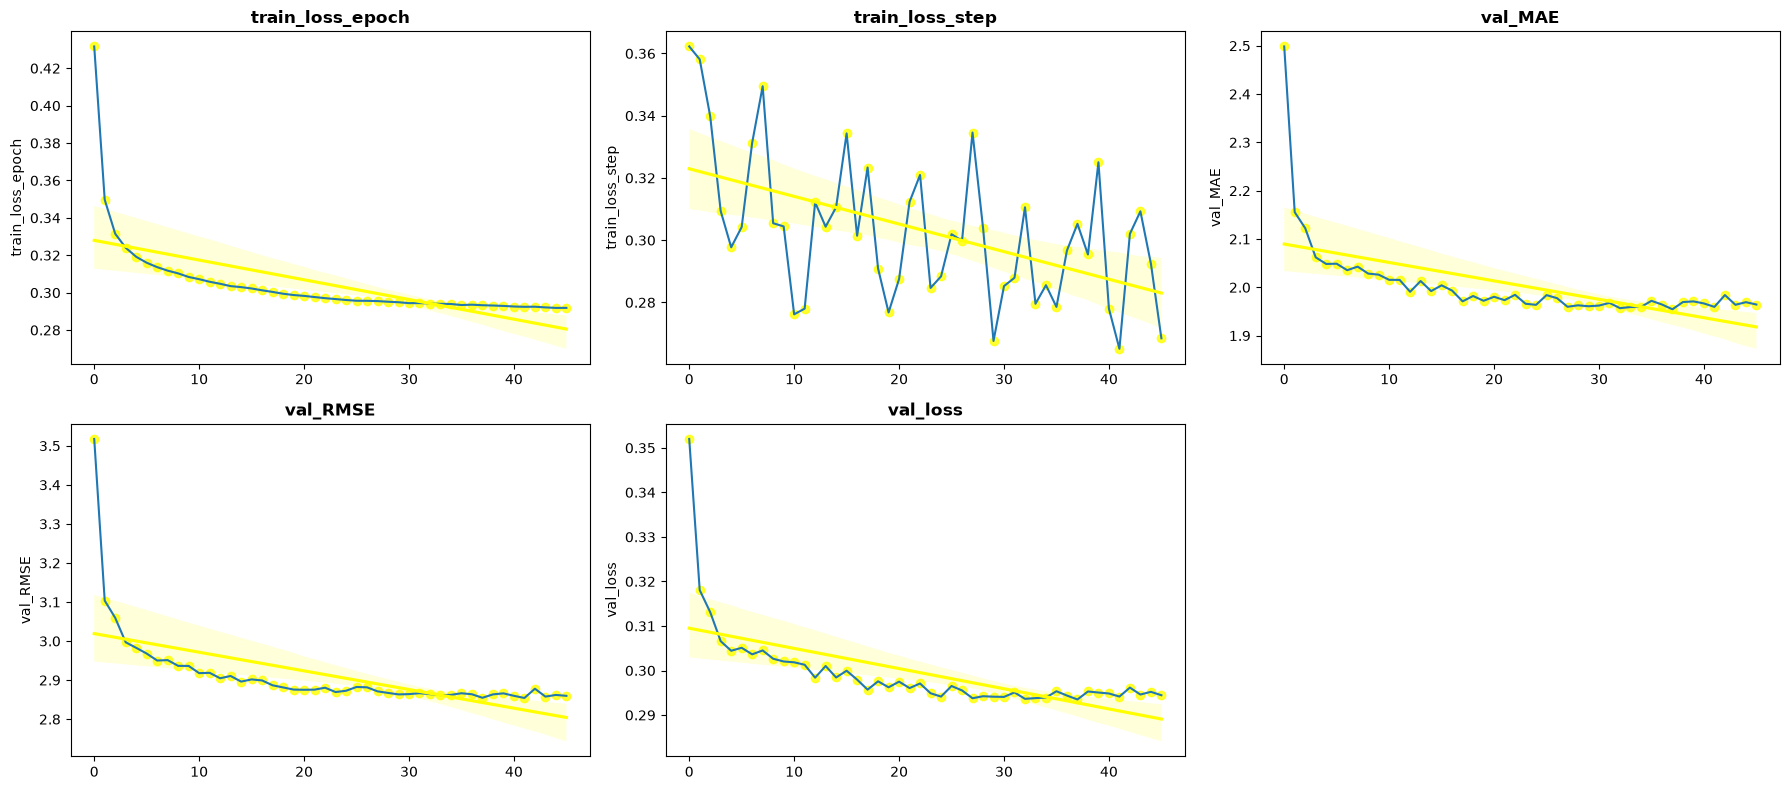

In [43]:
path_metrics_per_epoch = os.path.abspath('./models/models_tft_v5/log_tft/version_0/metrics.csv')
metrics = pd.read_csv(path_metrics_per_epoch)
metrics = metrics.groupby('epoch').ffill().bfill()
metrics.drop_duplicates(inplace=True)
metrics = metrics.reset_index(drop=True)

plt.figure(figsize=(18, 8))
for i, col in enumerate(metrics.columns[1:]):
    plt.subplot(2, 3, i+1)
    sns.lineplot(x=metrics.index, y=metrics[col], markers='o')
    sns.regplot(x=metrics.index, y=metrics[col], color='yellow')
    plt.title(f'{col}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [44]:
if os.path.exists(checkpoint_best.best_model_path):
    path_best_model = checkpoint_best.best_model_path
else:
    path_best_model = os.path.join(model_path, 'tft_best.ckpt')

best_model_tft = TemporalFusionTransformer.load_from_checkpoint(path_best_model)
best_model_tft.eval()
result = best_model_tft.predict(test_loader, return_y=True, return_x=True, trainer_kwargs={"logger": False})

c:\Users\user\works\DE_studies\pm25_forecast\ne_env\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\user\works\DE_studies\pm25_forecast\ne_env\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/p

In [45]:
res = result.output.numpy()
actual = result.y[0].numpy()
horizon_results = {}
horizon_evals = {}

for i in range(horizon):
    horizon_results[i+1] = {
        'predicted': [],
        'actual': [],
    }

    horizon_evals[i+1] = {
        'MAE': None,
        'RMSE': None,
        'sMAPE (%)': None,
        'n_samples': None
    }

for pred, act in zip(res, actual):
    for j in range(len(pred)):
        horizon_results[j+1]['predicted'].append(pred[j])
        horizon_results[j+1]['actual'].append(act[j])

for z in range(0, horizon):
    current_h = horizon_evals[z+1]
    current_result = horizon_results[z+1]
    current_h['MAE'] = MAE()(torch.tensor(current_result['predicted']).reshape(-1, 1), torch.tensor(current_result['actual']).reshape(-1, 1)).item()
    current_h['RMSE'] = RMSE()(torch.tensor(current_result['predicted']).reshape(-1, 1), torch.tensor(current_result['actual']).reshape(-1, 1)).item()
    current_h['sMAPE (%)'] = SMAPE()(torch.tensor(current_result['predicted']).reshape(-1, 1), torch.tensor(current_result['actual']).reshape(-1, 1)).item()*100
    current_h['n_samples'] = len(current_result['actual'])

eval_per_horizon = pd.DataFrame(horizon_evals).T.reset_index()
eval_per_horizon.rename(columns={
    'index': 'horizon'
}, inplace=True)

eval_per_horizon

,horizon,MAE,RMSE,sMAPE (%),n_samples
0,1,2.081881,3.256385,24.874440,25432.0
1,2,2.321651,3.612881,27.352101,25432.0
2,3,2.522598,3.912771,29.371977,25432.0
3,4,2.690668,4.166884,31.057665,25432.0
4,5,2.829353,4.391068,32.410932,25432.0
5,6,2.955452,4.604649,33.614892,25432.0


In [46]:
mae = MAE()(result.output, result.y).item()
rmse = RMSE()(result.output, result.y).item()
smape = SMAPE()(result.output, result.y).item()

print(f"Test MAE:   {mae:.4f}")
print(f"Test RMSE:  {rmse:.4f}")
print(f"Test SMAPE: {smape*100:.4f}%")

Test MAE:   2.5669
Test RMSE:  4.0169
Test SMAPE: 29.7803%
